# Backtest — Reversión a la media sobre futuros de Bitcoin del CME (IBKR)

**Hipótesis:** si a intradía las rupturas del canal Donchian fallan de forma sistemática, el lado
opuesto de esa operación tiene retorno esperado positivo. Este notebook es la copia del de ruptura
(`Turtle_IBKR_CME_Bitcoin.ipynb`) con el lado de la señal invertido en el motor; el resto del
código —descarga por cadena de vencimientos, RTH, MAE/MFE, sesgos, Monte Carlo— es el mismo.

**Tesis a contrastar:** el fade canónico de la banda de 20 barras con parámetros FIJOS. No es una
optimización fuera de muestra: el walk-forward de §7 se corre como diagnóstico del sistema fijo,
no como el sistema que se propone operar.

**Origen de la hipótesis** (medido; ver `journals/graveyard.md`):

- **E-ratio = 0.83–0.90 < 1** — tras entrar en la ruptura el precio recorre de media más en contra
  que a favor. Afecta al timing de la entrada, no a la colocación del stop.
- **El 27% de las rupturas confirma** — el resto no cierra fuera del canal en la barra siguiente.
- **El Turtle pierde en las cuatro configuraciones** a 30 min una vez corregidos dos sesgos de
  ejecución (el hueco de entrada y el mismo hueco en los adds).

---

## Reglas

| | |
|---|---|
| **Señal** | Ruptura del canal Donchian de 20 barras en la barra `t` |
| **Confirmación** | La barra `t+1` cierra de vuelta DENTRO del canal (la ruptura falla) |
| **Entrada** | Al OPEN de la barra `t+2`, en dirección contraria a la ruptura |
| **Stop** | 1N ⇒ **R = 1N** |
| **Sizing** | Por R: `Unit_Qty = RISK × Equity / (STOP_N × N × mult)` |
| **Take profit** | Punto medio del canal, congelado en la entrada |
| **Vertical** | 10 barras (5 h) |
| **Adds** | Cada ½N a favor, hasta cruzar el medio; máx. 4 unidades |
| **Lados** | Simétrico, con métricas reportadas por lado |

**Objetivo en el medio del canal y no en la banda opuesta.** El canal mide ≈10 N de ancho, así que
la banda contraria está a casi 10 N y se toca el 0.9–1.4% de las veces dentro de la barrera
vertical. El medio, a ~4.9 N, se toca el 7–10%. La salida dominante sigue siendo el vencimiento
de la barrera vertical.

**Por qué se exige que la ruptura falle.** Entrar al open de `t+1` sin condición sobre el cierre
opera también contra rupturas que se extienden: la posición salta al stop, la barra siguiente
vuelve a romper el canal y el stop se paga en cadena. Exigir que `t+1` cierre de vuelta dentro del
canal reduce los trades de 467 a 272 y los stops de 329 a 165, y **duplica la esperanza por trade,
de +0.186 R a +0.375 R**. Medido en §6 y estable en las ocho ventanas del barrido de §8.

**Stop en 1N y sizing por R.** El barrido de §8.5 y `journals/graveyard.md` §7 miden que ensanchar
el stop a 2N lleva la esperanza por trade de +0.186 R a −0.056 R: sube el win rate del 28% al
42% pero el ganador medio cae de 5.13 R a 2.13 R. El sizing por R mantiene el riesgo por unidad en el 1% del
equity sea cual sea el ancho del stop, lo que permite comparar configuraciones con distinto stop
en la misma escala de riesgo.

---

## Condiciones declaradas antes de correr el backtest

La reversión medida sobre retornos brutos es débil y asimétrica: `P(el fade gana)` está entre el
51% y el 56% según el horizonte, pero la media del fade corto es negativa (−0.16 N a 10 barras)
mientras la del largo es positiva (+0.12 N). Con ~1.3 años de un solo subyacente en tendencia
alcista, esa asimetría no es separable de la deriva del bitcoin en el periodo.

El sistema se opera simétrico. La asimetría se reporta en §6 bis y no se usa para elegir un lado.

En el notebook de ruptura, un Sharpe de 3.5 resultó ser íntegramente hueco de entrada. Los
diagnósticos de ejecutabilidad de §6 y de sesgos de §8 se leen antes que cualquier métrica.


## 1. Setup y configuración

In [1]:
# pip install ib_async pandas numpy matplotlib scipy
import json, math, os, sys, time, warnings, itertools, inspect
from datetime import datetime, timezone, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 50)

plt.rcParams.update({
    "figure.figsize": (14, 6), "axes.grid": True, "grid.alpha": 0.25,
    "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
})

# Raíz del repo: se sube hasta encontrar pyproject.toml, así el notebook funciona
# tanto si el kernel arranca en notebooks/ como en la raíz.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))          # para `from qsCrypto...` sin instalar el paquete
CACHE = ROOT / "data_cache" / "ibkr"; CACHE.mkdir(parents=True, exist_ok=True)
OUT = ROOT / "output"; OUT.mkdir(exist_ok=True)

# Únicos módulos del proyecto que se usan (no se añade ninguno):
from qsCrypto.ibkr import config
from qsCrypto.ibkr.contracts import front_month
# Definición autoritativa de MAE/MFE, compartida con el notebook de Parte A y
# con Position. Que el backtest y el bot en vivo midan la excursión con el mismo
# código es lo que hace comparable el test de réplica de §12.
from qsCrypto.portfolio.mae import (
    Excursion, excursions_from_ohlc, mae_star, win_prob_curve, edge_ratio,
    resolvability, flat_bar_mask,
)

print(f"ROOT   : {ROOT}")
print(f"CACHE  : {CACHE}")
print(f"IBKR   : {config.IB_HOST}:{config.IB_PORT} clientId={config.IB_CLIENT_ID} "
      f"account={config.IB_ACCOUNT} mktDataType={config.IB_MARKET_DATA_TYPE}")
print("Setup OK")

ROOT   : /Users/diegoochoa/Projects/Intraday_MR_BTC
CACHE  : /Users/diegoochoa/Projects/Intraday_MR_BTC/data_cache/ibkr
IBKR   : 127.0.0.1:7496 clientId=17 account=DU496961 mktDataType=3
Setup OK


### 1.1 Parámetros Inverse Turtle

Los canónicos del skill `/turtlerisk`, con una diferencia crítica frente al notebook
diversificado: **aquí se cuentan en BARRAS, no en días**. `ATR_PERIOD = 20` es la EMA-20 del
True Range de la granularidad elegida — 20 segundos, 20 minutos o 20 días. Es la misma fórmula;
lo que cambia es qué llama "N" el sistema.

In [2]:
# ─────────── PARÁMETROS CANÓNICOS TURTLE (skill /turtlerisk) — EN BARRAS ───────────
ATR_PERIOD     = 20       # N = EMA-20 del True Range (en barras de BAR_SIZE)
RISK_PER_UNIT  = 0.01     # 1% del equity por unidad
MAX_UNITS      = 4        # máx. unidades por mercado
STOP_N         = 1        # R = 1N. Stop duro: domina a la calibración por MAE
                          # en esperanza, Sharpe y CAGR (ver journals/graveyard.md §7).
ADD_N          = 0.5      # añadir unidad cada ½N
MAX_DIR_UNITS  = 12       # máx. unidades por dirección
MAX_CORR_UNITS = 6        # máx. unidades por grupo correlacionado
MAX_GROSS_LEV  = 4.0      # tope de nocional bruto / equity

# Sistema 1 (corto) / Sistema 2 (largo) — canales Donchian, en BARRAS
SYS1 = {"entry": 20, "exit": 10}
SYS2 = {"entry": 55, "exit": 20}

# Sistema de la TESIS: fade canonico de la banda de 20 barras, parametros FIJOS.
# El walk-forward de §7 es un diagnostico de su estabilidad, no un sistema alternativo:
# el checklist de §10 juzga este sistema, no la curva optimizada.
SYS_MAIN = SYS1
SYS_ALT  = SYS2

# ─────────── TRIPLE BARRERA REVERSIVA (§5) ───────────
# Misma geometría que el notebook de ruptura, con tres diferencias:
#   - el lado de la señal se INVIERTE (fade),
#   - el stop se queda en 1N (ensancharlo a 2N, que es lo que pedía la
#     calibración de MAE, reduce la esperanza a la mitad: graveyard.md §7),
#   - el objetivo deja de ser un múltiplo de N y pasa a ser el MEDIO del canal.
SIGNAL_MODE    = "fade"        # "fade" invierte la ruptura; "breakout" la sigue
ENTRY_TIMING   = "next_open"   # entrada al OPEN de la barra siguiente, sin confirmar
TP_MODE        = "mid_channel" # Modo take profit: "mid_channel" o "n_multiple"
SIZE_ON        = "r"           # riesgo constante por unidad (ver abajo)
ADD_UNTIL_MID  = True          # dejar de cargar al cruzar el medio del canal
USE_DONCHIAN_EXIT = False      # el canal de salida lo sustituye el objetivo
TIE_BREAK      = "pessimistic" # stop y objetivo en la misma barra: gana el adverso
ALLOW_SHORT    = True          # operar los dos lados
USE_DD_RULE    = True          # reducir nocional tras drawdown
# Confirmación de ruptura FALLIDA. La barra siguiente a la ruptura tiene que
# cerrar de vuelta DENTRO del canal (por debajo de la banda superior en una
# ruptura alcista, por encima de la inferior en una bajista). Sin esta condición
# se entra también contra rupturas que siguen extendiéndose: la posición salta al
# stop, la barra siguiente vuelve a romper y el stop se paga en cadena.
# La primera unidad se llena al OPEN de la barra SIGUIENTE a la de confirmación.
REQUIRE_CONFIRMATION = True
CONFIRM_MODE   = "inside"      # "inside" (la ruptura falla) | "beyond" (se confirma)
TAKE_N         = 5.0           # solo se usa si TP_MODE = "n_multiple"
MAX_HOLD_BARS  = 10            # barrera vertical: 10 barras de 30 min = 5 h
EMBARGO_BARS   = MAX_HOLD_BARS # el horizonte de la etiqueta fija el embargo (§7)

CALIB_STOP_N   = 3.0           # stop de la población de calibración (§8.5)

# Umbral de cierre temprano por MAE, declarado antes de mirar nada fuera de
# muestra. Viene de la calibración del notebook de ruptura: con stop 2N,
# MAE* = 1.38 N = 0.69 R. Aquí R = 2N, así que 1.38 N cae DENTRO del stop.
MAE_STOP_N_FIJO = 3.0

# ─────────── CAPITAL ───────────
# El nocional por contrato de BRR (5 BTC) exige capital de seis cifras; §3 hace
# la comprobación de viabilidad contrato a contrato antes de simular nada.
EQUITY_0 = 100_000

# ─────────── SIZING: por R, no por N ───────────
# Mover el stop sin tocar el sizing multiplicaría el riesgo. Con la fórmula
# canónica Unit_Qty = 1%·E/N, una unidad detenida en 2N pierde el 2%, y con la
# escalera de ½N el riesgo agregado a plena carga llega a 5N = 5% del equity
# (fills en 0, ½N, 1N, 1½N con el stop común en −½N: 0.5+1.0+1.5+2.0 = 5.0 N).
# Dimensionando por R = STOP_N·N vuelve a ser 1% por unidad y 2.5% a plena carga,
# y deja el Sharpe en la MISMA escala de riesgo que el notebook de ruptura, que es
# lo que permite comparar los dos.

print(f"  Señal : {SIGNAL_MODE}  |  entrada: {ENTRY_TIMING}  |  TP: {TP_MODE}"
      + (f" (+{TAKE_N:.1f}N)" if TP_MODE == "n_multiple" else " (medio del canal)"))
print(f"  R = {STOP_N:.0f}N  |  sizing por '{SIZE_ON}'  |  vertical {MAX_HOLD_BARS} barras")
print(f"  Riesgo por unidad detenida: {RISK_PER_UNIT:.0%} del equity"
      f"  (a plena carga {RISK_PER_UNIT*2.5:.1%})")

  Señal : fade  |  entrada: next_open  |  TP: mid_channel (medio del canal)
  R = 1N  |  sizing por 'r'  |  vertical 10 barras
  Riesgo por unidad detenida: 1% del equity  (a plena carga 2.5%)


### 1.2 Granularidad — el único parámetro que hay que tocar

`BAR_SIZE` acepta cualquier `barSizeSetting` de IB entre `"1 secs"` y `"1 day"`. De él salen,
sin tocar nada más:

- el **troceado** de las peticiones a `reqHistoricalData` (IB limita la duración por petición
  según el tamaño de barra, y rechaza la petición entera si te pasas),
- la **profundidad** disponible (IB no sirve barras `< 30 secs` más allá de ~6 meses),
- el **factor de anualización** de las métricas — que **no** se asume, se mide sobre el índice
  real de los datos (§3): el CME cierra 1h al día y el fin de semana, así que "barras por año"
  no es `segundos_por_año / segundos_por_barra`,
- las ventanas del walk-forward (§7), expresadas en barras.

**Coherencia horizonte/granularidad:** un canal de 55 barras de 1 segundo cubre menos de un
minuto, y a esa escala el coste por round-trip (1 tick de slippage + comisión) domina la señal.
La celda reporta la duración de la ventana del canal más largo.

In [3]:
# ─────────── GRANULARIDAD ───────────
# 30 min es una elección MEDIDA, no de gusto. Manda la identidad
#     nocional/equity = RISK_PER_UNIT × precio / N
# que no depende del capital: con 1% y BTC≈95.000 hace falta N ≥ 237 puntos para
# caber en MAX_GROSS_LEV=4. Medido sobre el front month de MBT con RTH:
#
#     TF        N (pts)  rango/N  coste/R  nocional/eq
#     1 min        28.8    2.15N      78%       27.7x   inviable
#     5 min        91      1.27N      25%        8.8x   inviable
#     15 min      247      0.50N       9%        3.2x   al límite
#     30 min      424      0.48N       5%        1.9x   ELEGIDA
#     1 hour      684      0.34N       3%        1.2x
#
# A 1 min el coste de ida y vuelta se come el 78% de la R, y eso NO se arregla
# con el tamaño (coste y riesgo por contrato escalan igual): solo subiendo N.
# Y contraintuitivo pero medido: afinar la barra EMPEORA la resolución
# intrabarra (2.15N de rango a 1 min frente a 0.48N a 30 min), porque el TR de
# 1 min lo domina el ruido de tick.
BAR_SIZE     = "30 mins"   # "1 secs".."1 day" — ver IB_BAR_SECONDS
# Profundidad pedida deliberadamente por encima de lo que IB sirve para MBT/BRR a
# 30 min: el límite efectivo lo pone la disponibilidad de contratos en la cadena,
# no este parámetro. §3 imprime la ventana realmente obtenida.
LOOKBACK_DAYS = 365 * 4
# Ancla final del backtest. Todas las peticiones a IB y el recorte posterior de la
# serie terminan aquí, de modo que la muestra no cambia según el día en que se
# ejecute el notebook.
END_DATETIME  = "2026-08-30 00:00:00"
# RTH=True es lo que arregla las velas planas del feed demo: medido sobre MBT a
# 1 min, las velas sin rango ni volumen caen del 33% al 0.8% (BRR: 36.5% → 6.6%).
# Una vela plana tiene excursión CERO, así que dejarlas dentro sesga la MAE a la
# baja y hace que cualquier stop parezca más seguro de lo que es.
USE_RTH       = True
WHAT_TO_SHOW  = "TRADES"   # "TRADES" | "MIDPOINT" — MIDPOINT si no hay permisos de trades

# Solape de horario líquido entre los dos contratos: MBT cierra a las 16:00 CT y
# BRR a las 15:15. Recortar ambos a la ventana común deja las dos series con el
# MISMO índice; sin eso, los 45 min en que solo cotiza MBT producen el serrucho
# de mark-to-market que ya conocemos de calendarios heterogéneos.
RTH_OVERLAP = ("13:30", "20:15")   # 08:30–15:15 CT expresado en UTC

# barSizeSetting válidos de IB -> segundos. Es la tabla de la API, no una elección nuestra.
IB_BAR_SECONDS = {
    "1 secs": 1, "5 secs": 5, "10 secs": 10, "15 secs": 15, "30 secs": 30,
    "1 min": 60, "2 mins": 120, "3 mins": 180, "5 mins": 300, "10 mins": 600,
    "15 mins": 900, "20 mins": 1200, "30 mins": 1800,
    "1 hour": 3600, "2 hours": 7200, "3 hours": 10800, "4 hours": 14400,
    "8 hours": 28800, "1 day": 86400,
}
assert BAR_SIZE in IB_BAR_SECONDS, f"BAR_SIZE inválido. Opciones: {list(IB_BAR_SECONDS)}"
END_TS = pd.Timestamp(END_DATETIME) if END_DATETIME else None
BAR_SECONDS = IB_BAR_SECONDS[BAR_SIZE]

def ib_chunk(bar_seconds):
    """(durationStr, segundos) máximos por petición para ese tamaño de barra.

    Los topes son de IB y son duros: una petición que los excede se rechaza entera,
    no se trunca. Van deliberadamente por debajo del límite documentado para dejar
    margen — IB también corta por número de barras devueltas. Es la razón por la que
    §3 pagina sobre contratos reales en vez de pedir la serie entera de una vez.
    """
    for lim, dur, secs in [
        (1,     "1800 S", 1800),      (5,     "3600 S", 3600),
        (30,    "14400 S", 14400),    (60,    "1 D", 86400),
        (300,   "1 W", 7*86400),      (1800,  "1 M", 30*86400),
        (3600,  "2 M", 60*86400),     (86400, "1 Y", 365*86400),
    ]:
        if bar_seconds <= lim:
            return dur, secs
    return "1 Y", 365*86400

def ib_max_history_days(bar_seconds):
    """Hasta dónde atrás sirve IB ese tamaño de barra. None = histórico completo."""
    return 183 if bar_seconds < 30 else None   # sub-30s: ~6 meses

CHUNK_STR, CHUNK_SECONDS = ib_chunk(BAR_SECONDS)
MAX_HIST_DAYS = ib_max_history_days(BAR_SECONDS)
EFFECTIVE_LOOKBACK = min(LOOKBACK_DAYS, MAX_HIST_DAYS or LOOKBACK_DAYS)

print(f"  BAR_SIZE            : {BAR_SIZE}  ({BAR_SECONDS}s por barra)")
print(f"  Petición máx. a IB  : {CHUNK_STR}")
print(f"  Lookback pedido     : {LOOKBACK_DAYS} d")
print(f"  Lookback efectivo   : {EFFECTIVE_LOOKBACK} d"
      + (f"   ⚠ IB no sirve {BAR_SIZE} más allá de ~{MAX_HIST_DAYS} d" if MAX_HIST_DAYS else ""))
print(f"  Peticiones estimadas: ~{math.ceil(EFFECTIVE_LOOKBACK*86400/CHUNK_SECONDS)} por símbolo")

# --- coherencia horizonte / granularidad ---
span_entry_s = SYS_MAIN["entry"] * BAR_SECONDS
print(f"\n  Canal de la tesis ({SYS_MAIN['entry']}b) cubre {span_entry_s/3600:,.2f} h de mercado")
print(f"  Barrera vertical ({MAX_HOLD_BARS}b) cubre {MAX_HOLD_BARS*BAR_SECONDS/3600:,.2f} h")
print(f"  Triple barrera: −{STOP_N:.0f}N / +{TAKE_N:.0f}N / {MAX_HOLD_BARS}b"
      f"  →  pt_sl = ({TAKE_N:.0f}, {STOP_N:.0f}) en notación AFML")
if span_entry_s < 86400:
    print("  El canal de entrada cubre menos de un día de mercado: horizonte corto,")
    print("  no seguimiento de tendencia clásico. Coherente con la tesis reversiva.")
else:
    print("  El canal cubre más de un día de mercado: horizonte de tendencia.")

  BAR_SIZE            : 30 mins  (1800s por barra)
  Petición máx. a IB  : 1 M
  Lookback pedido     : 1460 d
  Lookback efectivo   : 1460 d
  Peticiones estimadas: ~49 por símbolo

  Canal de la tesis (20b) cubre 10.00 h de mercado
  Barrera vertical (10b) cubre 5.00 h
  Triple barrera: −1N / +5N / 10b  →  pt_sl = (5, 1) en notación AFML
  El canal de entrada cubre menos de un día de mercado: horizonte corto,
  no seguimiento de tendencia clásico. Coherente con la tesis reversiva.


### 1.3 Costes — un futuro listado no se cobra en puntos básicos

Ésta es la diferencia de modelado más importante frente al notebook de perpetuos:

| | Perpetuo cripto | Futuro CME |
|---|---|---|
| Comisión | % del nocional | **USD fijos por contrato** |
| Slippage | bps sobre el precio | **ticks** (`minTick` del contrato) |
| Funding | sí, 3×/día | **no existe** — el carry va en el precio forward |

Cobrar funding a un futuro añade un coste que escala con el nocional mientras el sizing Turtle
escala con el riesgo: en instrumentos de N/precio bajo drena la cuenta hasta números negativos.
Aquí `FUNDING = 0`.

Las comisiones por defecto son el orden de magnitud de IBKR (comisión + tasas de bolsa y
clearing, por lado). Sustitúyelas por las del estado de cuenta real: a granularidad fina la comisión es el término
dominante del P&L.

In [4]:
# Comisión USD por contrato y POR LADO (IBKR + exchange + clearing, aprox.)
# y slippage en TICKS. Ajusta a tu estructura real de comisiones.
COSTS = {
    "MBT": {"comm": 0.62, "slip_ticks": 1.0},
    "BRR": {"comm": 2.75, "slip_ticks": 1.0},
}
FUNDING = 0.0    # los futuros NO pagan funding. No lo cambies.

# A granularidad fina el slippage se paga más veces: el aviso es cuantitativo.
print(f"  Coste round-trip por contrato (con 1 tick de slippage):")
for s, c in COSTS.items():
    print(f"    {s}: 2×{c['comm']:.2f} comisión + 2×{c['slip_ticks']:.0f} tick de slippage")
print("\n  El valor en USD del tick sale de `detail.minTick × multiplier` (§2), no se hardcodea.")

  Coste round-trip por contrato (con 1 tick de slippage):
    MBT: 2×0.62 comisión + 2×1 tick de slippage
    BRR: 2×2.75 comisión + 2×1 tick de slippage

  El valor en USD del tick sale de `detail.minTick × multiplier` (§2), no se hardcodea.


## 2. Universo — MBT / BRR y resolución de contrato

Dos contratos sobre **el mismo subyacente** (el CME CF Bitcoin Reference Rate):

| Símbolo | Contrato | Tamaño | Nocional con BTC a 100k |
|---|---|---|---|
| `MBT` | Micro Bitcoin Futures | 0.1 BTC | ~10.000 USD |
| `BRR` | Bitcoin Futures | 5 BTC | ~500.000 USD |

Están en el **mismo grupo de correlación** (`crypto`), así que el límite de 6 unidades por
grupo del skill los trata como lo que son: una sola apuesta. Operar los dos a la vez no
aporta diversificación; cambia la granularidad del sizing.

`multiplier` y `minTick` **no se hardcodean**: salen de `reqContractDetails` a través de
`front_month()`, el módulo que ya existe en el repo. Si TWS no está levantado hay un
diccionario de respaldo, marcado como tal en la tabla.

In [5]:
SYMBOLS = ["MBT"]          # ["MBT"], ["BRR"] o ["MBT", "BRR"]

UNIVERSE = {
    "MBT": {"desc": "Micro Bitcoin Futures (0.1 BTC)", "exchange": "CME", "currency": "USD"},
    "BRR": {"desc": "Bitcoin Futures (5 BTC)",         "exchange": "CME", "currency": "USD"},
}
CORRELATION_GROUPS = {"crypto": {"MBT", "BRR"}}
SYM2GROUP = {s: g for g, ms in CORRELATION_GROUPS.items() for s in ms}

# Respaldo si no hay TWS: especificaciones publicadas del CME. Se usan SOLO si
# reqContractDetails falla, y la tabla de §2 lo marca con `fuente = fallback`.
SPECS_FALLBACK = {
    "MBT": {"multiplier": 0.1, "minTick": 5.0},
    "BRR": {"multiplier": 5.0, "minTick": 5.0},
}

assert all(s in UNIVERSE for s in SYMBOLS), f"SYMBOLS fuera de UNIVERSE: {SYMBOLS}"
assert all(s in SYM2GROUP for s in UNIVERSE)
print(f"{len(SYMBOLS)} símbolo(s) seleccionado(s): {SYMBOLS}")
print(f"⚠️  Ambos comparten subyacente y grupo de correlación → n_eff ≈ 1 (se mide en §8)")

1 símbolo(s) seleccionado(s): ['MBT']
⚠️  Ambos comparten subyacente y grupo de correlación → n_eff ≈ 1 (se mide en §8)


In [6]:
from ib_async import IB, ContFuture, Future, util

# ── OBLIGATORIO EN JUPYTER ────────────────────────────────────────────────
# ib_async es asíncrono por dentro y `ib.connect()` arranca su propio bucle de
# eventos. El kernel de Jupyter YA tiene uno corriendo, así que la llamada muere
# con `RuntimeError: This event loop is already running` — y como `ib_connect()`
# degrada a caché en vez de lanzar, el síntoma aparece cinco celdas más abajo
# como "0 barras", que parece un problema de permisos de datos y no lo es.
#
# `util.startLoop()` (nest_asyncio) permite anidar el bucle y lo arregla. Fuera
# de Jupyter no hace falta y no se llama: en script se usa `util.patchAsyncio()`,
# como hace `qsCrypto/ibkr/check_connection.py`.
def _in_jupyter():
    try:
        return get_ipython().__class__.__name__ == "ZMQInteractiveShell"
    except NameError:
        return False

if _in_jupyter():
    util.startLoop()
    print("  Bucle de eventos parcheado para Jupyter (util.startLoop)")

# TWS reporta los fallos de datos por el canal de errores, NO como excepción:
# `reqHistoricalData` devuelve una lista VACÍA y el motivo real (sin permisos,
# endDateTime mal formado, pacing violation) solo aparece aquí. Sin recogerlos,
# "0 barras" es indistinguible de "el contrato no cotizaba".
IB_ERRORS = []
IB_TIME_OFFSET = pd.Timedelta(0)   # reloj de TWS − reloj local, medido UNA vez

def _on_ib_error(reqId, code, msg, contract):
    # 2104/2106/2158 son avisos de "granja de datos conectada", no errores.
    if code not in (2104, 2106, 2158, 2119):
        IB_ERRORS.append((reqId, code, msg))

def ib_connect(readonly=True, timeout=10):
    """Conecta a TWS/Gateway con los parámetros de `qsCrypto.ibkr.config`.

    Devuelve None en vez de lanzar si no hay sesión: el notebook debe poder
    reejecutarse sobre la caché de §3 sin TWS delante.
    """
    ib = IB()
    try:
        ib.connect(config.IB_HOST, config.IB_PORT, clientId=config.IB_CLIENT_ID,
                   timeout=timeout, readonly=readonly)
    except Exception as e:
        print(f"  ✗ SIN SESIÓN IBKR ({type(e).__name__}: {e})")
        if "event loop is already running" in str(e):
            print("     Causa: el bucle de eventos del kernel no está parcheado.")
            print("     Arreglo: ejecuta `util.startLoop()` (arriba en esta misma celda)")
            print("     ANTES de conectar, o reinicia el kernel y corre las celdas en orden.")
        elif "connection refused" in str(e).lower() or isinstance(e, (ConnectionError, OSError)):
            print(f"     Causa: nadie escucha en {config.IB_HOST}:{config.IB_PORT}.")
            print("     Arreglo: levanta TWS/Gateway y habilita la API "
                  "(Configuración → API → Enable ActiveX and Socket Clients).")
        elif "timeout" in str(e).lower():
            print(f"     Causa: TWS no respondió, o clientId={config.IB_CLIENT_ID} ya está en uso.")
            print("     Arreglo: cambia IB_CLIENT_ID en .env, o acepta el diálogo de "
                  "conexión entrante en TWS.")
        print("  → §3 usará exclusivamente la caché local si existe; si no la hay, corta ahí.")
        return None
    global IB_TIME_OFFSET
    ib.errorEvent += _on_ib_error
    ib.reqMarketDataType(config.IB_MARKET_DATA_TYPE)
    # El reloj de TWS manda: pedir histórico con un endDateTime que para el
    # servidor está en el futuro devuelve vacío sin decir por qué.
    #
    # Se consulta UNA SOLA VEZ y se guarda el desfase. `reqCurrentTime()` se
    # cuelga —o tumba el socket— si se le llama repetidamente en la misma
    # sesión, así que a partir de aquí la hora se deriva con `ib_now()` en vez
    # de volver a preguntar.
    srv = pd.Timestamp(ib.reqCurrentTime())
    IB_TIME_OFFSET = srv - pd.Timestamp.now(tz="UTC")
    print(f"  IBKR conectado — serverVersion {ib.client.serverVersion()}, "
          f"cuentas {ib.managedAccounts()}")
    print(f"  Hora servidor IB: {srv:%Y-%m-%d %H:%M:%S %Z}  |  "
          f"desfase con el reloj local: {IB_TIME_OFFSET.total_seconds():+.1f}s")
    if abs(IB_TIME_OFFSET) > pd.Timedelta(days=1):
        print(f"  ⚠ Desfase de {abs(IB_TIME_OFFSET).days} días entre IB y la máquina. "
              f"§3 usa el de IB.")
    return ib


def ib_now():
    """'Ahora' según el reloj de TWS, sin volver a llamar a `reqCurrentTime()`."""
    return (pd.Timestamp.now(tz="UTC") + IB_TIME_OFFSET).tz_localize(None)

IBS = ib_connect()

  Bucle de eventos parcheado para Jupyter (util.startLoop)
  IBKR conectado — serverVersion 178, cuentas ['DF496956', 'DU496957', 'DU496958', 'DU496959', 'DU496960', 'DU496961']
  Hora servidor IB: 2026-09-08 16:28:31 UTC  |  desfase con el reloj local: -1.1s


In [7]:
def resolve_specs(ib, symbol):
    """multiplier / minTick / front-month del símbolo, vía `front_month()` del repo.

    Se pide el contrato REAL (no la serie continua) porque `ContFuture` no siempre
    trae multiplicador ni tick poblados, y son los dos números de los que dependen
    el sizing (§5) y el coste (§1.3).
    """
    if ib is None:
        fb = SPECS_FALLBACK[symbol]
        return {**fb, "localSymbol": None, "expiry": None, "conId": None, "fuente": "fallback"}
    try:
        contract, detail, expiry = front_month(
            ib, symbol, UNIVERSE[symbol]["exchange"], UNIVERSE[symbol]["currency"])
        mult = float(contract.multiplier) if contract.multiplier else SPECS_FALLBACK[symbol]["multiplier"]
        return {"multiplier": mult, "minTick": float(detail.minTick),
                "localSymbol": contract.localSymbol, "expiry": expiry,
                "conId": contract.conId, "fuente": "IB"}
    except Exception as e:
        print(f"  {symbol}: reqContractDetails falló ({e}); se usa fallback")
        fb = SPECS_FALLBACK[symbol]
        return {**fb, "localSymbol": None, "expiry": None, "conId": None, "fuente": "fallback"}

SPECS = {s: resolve_specs(IBS, s) for s in SYMBOLS}

spec_rows = []
for s, sp in SPECS.items():
    tick_usd = sp["minTick"] * sp["multiplier"]
    spec_rows.append({
        "symbol": s, "desc": UNIVERSE[s]["desc"], "multiplier": sp["multiplier"],
        "minTick": sp["minTick"], "valor_tick_USD": tick_usd,
        "comision_lado_USD": COSTS[s]["comm"],
        "slippage_USD_lado": COSTS[s]["slip_ticks"] * tick_usd,
        "front_month": sp["localSymbol"], "expiry": sp["expiry"], "fuente": sp["fuente"],
    })
SPECS_DF = pd.DataFrame(spec_rows)
display(SPECS_DF)
if (SPECS_DF.fuente == "fallback").any():
    print("⚠️  Especificaciones de respaldo en uso (sin TWS). Verifícalas antes de operar.")

,symbol,desc,multiplier,minTick,valor_tick_USD,comision_lado_USD,slippage_USD_lado,front_month,expiry,fuente
0,MBT,Micro Bitcoin Futures (0.1 BTC),0.1,5.0,0.5,0.62,0.5,MBTU6,2026-09-25,IB


## 3. Descarga de datos — dos fuentes:

IB impone dos restricciones que condicionan todo el diseño de esta sección:

1. **`ContFuture` no admite `endDateTime`.** Pedirlo devuelve el error **10339**
   (*"Setting end date/time for continuous future security type is not allowed"*) y TWS
   **cierra la conexión**. La serie continua solo se puede pedir "hasta ahora", en **una única
   petición**: no hay paginación posible, y la profundidad es la que IB quiera dar.
2. **Los contratos reales sí admiten `endDateTime`**, así que sobre ellos sí se puede paginar
   hacia atrás encadenando peticiones.

Por lo tanto: con `BAR_SIZE = "1 secs"` la petición única de
`ContFuture` devuelve **30 minutos de datos** (el tope por petición para barras de 1 segundo) y
ahí se acaba. La serie continua **no sirve** para granularidad fina.

Por eso `DATA_SOURCE = "chain"` es el valor por defecto: se enumeran los vencimientos con
`includeExpired=True`, se pagina cada uno hacia atrás, y se cosen tomando de cada contrato solo
las barras del periodo en que **fue el front month**. Requiere más peticiones, y es la única fuente que funciona a cualquier granularidad. Deja además
las fechas de roll explícitas, que es lo que §8 usa para medir el sesgo de empalme.

La serie se cose sin ajustar: en cada roll hay un salto de precio que ninguna posición realizó.
No se corrige; se mide en §8.

In [9]:
DATA_SOURCE = "chain"   # "chain" (recomendado) | "cont"
ROLL_DAYS   = 2         # se rueda al siguiente vencimiento N días antes de expirar.
                        # Mismo criterio que `front_month(min_days=2)` del repo, para que
                        # el backtest y la resolución de contrato en vivo coincidan.

def _cache_path(symbol, bar_size, kind):
    slug = bar_size.replace(" ", "")
    d = CACHE / slug; d.mkdir(parents=True, exist_ok=True)
    return d / f"{symbol}_{kind}.csv"


def _bars_to_df(bars):
    """BarDataList -> DataFrame OHLCV con índice UTC tz-naive y columnas en minúscula."""
    if not bars:
        return pd.DataFrame()
    df = util.df(bars)
    if df is None or not len(df):
        return pd.DataFrame()
    df = df.rename(columns={"date": "time"})
    idx = pd.to_datetime(df["time"], utc=True, errors="coerce").dt.tz_localize(None)
    df = df.assign(time=idx).dropna(subset=["time"]).set_index("time").sort_index()
    keep = [c for c in ("open", "high", "low", "close", "volume") if c in df.columns]
    return df[keep].astype(float)


def _fmt_end(ts):
    """endDateTime en el formato que TWS 10.x acepta sin ambigüedad de zona.

    Un `datetime` naive se rechaza (error 10314) y la llamada devuelve [] en
    silencio; el string UTC explícito no depende de la zona de la máquina.
    """
    return pd.Timestamp(ts).strftime("%Y%m%d-%H:%M:%S")

Data fetcher para las velas/barras de los contratos, las cadenas enteras (curva)
o para la serie continua de IBKR.

In [10]:
def fetch_contract_bars(ib, contract, bar_size, start_ts, end_ts,
                        max_requests=200, pacing=0.6, timeout=25, verbose=False):
    """Histórico de UN contrato real, paginando hacia atrás desde `end_ts`.

    Solo para `Future` con vencimiento concreto: `ContFuture` rechaza
    `endDateTime` (error 10339) y además tumba la conexión. Pendiente error handler para 
    este caso 
    """
    chunk_str, chunk_secs = ib_chunk(IB_BAR_SECONDS[bar_size])
    frames, cursor, n_req = [], pd.Timestamp(end_ts), 0

    while cursor > pd.Timestamp(start_ts) and n_req < max_requests:
        n_err0 = len(IB_ERRORS)
        try:
            bars = ib.reqHistoricalData(
                contract, endDateTime=_fmt_end(cursor), durationStr=chunk_str,
                barSizeSetting=bar_size, whatToShow=WHAT_TO_SHOW,
                useRTH=USE_RTH, formatDate=2, timeout=timeout)
        except Exception as e:
            if verbose: print(f"      petición {n_req+1} falló ({e})")
            break
        n_req += 1
        chunk = _bars_to_df(bars)
        if not len(chunk):
            if verbose:
                nuevos = IB_ERRORS[n_err0:]
                if nuevos: print(f"      vacío en {cursor:%Y-%m-%d}: "
                                 + "; ".join(f"[{c}] {m}" for _, c, m in nuevos))
            break
        frames.append(chunk)
        nueva = chunk.index[0]
        # Sin este guard, un chunk que empieza donde empezó el anterior deja el
        # bucle girando hasta max_requests sin añadir una sola barra nueva.
        if nueva >= cursor:
            break
        cursor = nueva
        ib.sleep(pacing)

    if not frames:
        return pd.DataFrame(), n_req
    df = (pd.concat(frames).sort_index()
            .loc[lambda d: ~d.index.duplicated(keep="last")])
    return df, n_req


def fetch_chain(ib, symbol, bar_size, lookback_days, verbose=True):
    """Serie continua cosida a partir de los vencimientos REALES.

    De cada contrato se toman solo las barras del periodo en que fue el front
    month —desde el roll del anterior hasta el suyo propio— así que no hay
    solapamiento y el empalme ocurre exactamente en `ROLL_DAYS` antes de cada
    vencimiento. Devuelve (df, tabla_de_rolls).
    """
    det = ib.reqContractDetails(Future(symbol=symbol, exchange=UNIVERSE[symbol]["exchange"],
                                       currency=UNIVERSE[symbol]["currency"],
                                       includeExpired=True))
    if not det:
        return pd.DataFrame(), pd.DataFrame()

    chain = sorted(
        ((pd.Timestamp(d.contract.lastTradeDateOrContractMonth[:8]), d.contract) for d in det),
        key=lambda t: t[0])
    # El ancla final es END_TS si está declarada: sin esto la muestra se alarga sola
    # cada vez que se re-ejecuta el notebook y deja de ser comparable con la anterior.
    now = min(ib_now(), END_TS) if END_TS is not None else ib_now()
    horizon = now - pd.Timedelta(days=lookback_days)

    piezas, rolls, prev_roll, total_req = [], [], None, 0
    for expiry, c in chain:
        roll = expiry - pd.Timedelta(days=ROLL_DAYS)
        ini = prev_roll if prev_roll is not None else roll - pd.Timedelta(days=400)
        fin = min(roll, now)
        prev_roll = roll
        if fin <= horizon or ini >= fin:      # tramo fuera de la ventana pedida
            continue
        ini = max(ini, horizon)
        if verbose:
            print(f"    {c.localSymbol:<10} pidiendo {ini:%Y-%m-%d} → {fin:%Y-%m-%d} ...",
                  end="", flush=True)
        t0 = time.time()
        df, n_req = fetch_contract_bars(ib, c, bar_size, ini, fin)
        total_req += n_req
        tramo = (df.loc[(df.index >= ini) & (df.index <= fin)] if len(df) else df)
        if not len(tramo):
            # IB no guarda histórico de todos los contratos expirados: los muy
            # antiguos o poco líquidos no responden. Se salta y se sigue cosiendo.
            if verbose:
                print(f" sin datos ({n_req} pet., {time.time()-t0:.0f}s)")
            continue
        if verbose:
            print(f" {len(tramo):>6} barras ({n_req} pet., {time.time()-t0:.0f}s)")
        piezas.append(tramo)
        rolls.append({"contrato": c.localSymbol, "expiry": expiry.date(),
                      "roll": roll.date(), "desde": tramo.index[0], "hasta": tramo.index[-1],
                      "barras": len(tramo), "ultimo_close": float(tramo["close"].iloc[-1])})
    if not piezas:
        return pd.DataFrame(), pd.DataFrame()
    df = (pd.concat(piezas).sort_index()
            .loc[lambda d: ~d.index.duplicated(keep="last")])
    if verbose:
        print(f"    → {len(piezas)} contratos cosidos, {total_req} peticiones en total")
    return df, pd.DataFrame(rolls)


def fetch_cont(ib, symbol, bar_size, verbose=True):
    """Serie continua de IB — UNA petición, sin `endDateTime`.

    `ContFuture` + `endDateTime` = error 10339 y desconexión, así que aquí no hay
    paginación posible: la profundidad es la que IB decida servir. Con barras
    sub-minuto eso son minutos de datos, no años.
    """
    cf = ContFuture(symbol=symbol, exchange=UNIVERSE[symbol]["exchange"],
                    currency=UNIVERSE[symbol]["currency"])
    try:
        cf = ib.qualifyContracts(cf)[0]
    except Exception as e:
        return pd.DataFrame(), f"qualifyContracts falló: {e}"
    dur, _ = ib_chunk(IB_BAR_SECONDS[bar_size])
    if IB_BAR_SECONDS[bar_size] >= 3600:
        dur = "10 Y"          # IB recorta solo a lo que tenga; pedir de más no penaliza
    bars = ib.reqHistoricalData(cf, endDateTime="", durationStr=dur,
                                barSizeSetting=bar_size, whatToShow=WHAT_TO_SHOW,
                                useRTH=USE_RTH, formatDate=2, timeout=60)
    return _bars_to_df(bars), f"CONTFUT 1 petición ({dur})"


def fetch_bars(ib, symbol, bar_size=None, lookback_days=None, source=None, use_cache=True):
    """Dispatcher con caché. Devuelve (df, tabla_rolls, nota)."""
    bar_size = bar_size or BAR_SIZE
    lookback_days = lookback_days or EFFECTIVE_LOOKBACK
    source = source or DATA_SOURCE
    path, rpath = _cache_path(symbol, bar_size, source), _cache_path(symbol, bar_size, f"{source}_rolls")

    if use_cache and path.exists():
        df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
        rolls = (pd.read_csv(rpath, parse_dates=["desde", "hasta"])
                 if rpath.exists() else pd.DataFrame())
        if len(df):
            return df, rolls, f"caché ({path.name})"

    if ib is None:
        return pd.DataFrame(), pd.DataFrame(), "sin sesión IBKR y sin caché"

    if source == "chain":
        df, rolls = fetch_chain(ib, symbol, bar_size, lookback_days)
        nota = f"cadena de vencimientos ({len(rolls)} contratos)"
    else:
        df, nota = fetch_cont(ib, symbol, bar_size)
        rolls = pd.DataFrame()

    if not len(df):
        return df, rolls, nota
    df = df.dropna(subset=["open", "high", "low", "close"])
    df = df[(df[["open", "high", "low", "close"]] > 0).all(axis=1)]
    df.to_csv(path)
    if len(rolls):
        rolls.to_csv(rpath, index=False)
    return df, rolls, f"{nota} → {path.name}"

In [11]:
def trim_to_overlap(df, window=None):
    """Recorta al horario líquido común a MBT y BRR.

    IB ya filtra por RTH, pero el RTH de cada contrato es distinto (MBT hasta
    las 16:00 CT, BRR hasta las 15:15). Sin este recorte los 45 min en que solo
    cotiza MBT quedan como barras donde una pata del libro se marca a mercado y
    la otra no: un serrucho en la curva de equity que no es del mercado.
    """
    window = window or RTH_OVERLAP
    if not window:
        return df
    return df.between_time(window[0], window[1], inclusive="left")


RAW, ROLLS, ERR = {}, {}, {}
_min_bars = max(ATR_PERIOD + max(SYS_MAIN["entry"], SYS_ALT["entry"]) + 10, 120)

for s in SYMBOLS:
    print(f"  {s} ({DATA_SOURCE}):")
    df, rolls, nota = fetch_bars(IBS, s)
    if END_TS is not None and len(df):
        df = df.loc[:END_TS]
        if len(rolls):
            rolls = rolls[rolls["desde"] <= END_TS].copy()
            rolls["hasta"] = rolls["hasta"].clip(upper=END_TS)
    n_raw = len(df)
    if n_raw:
        df = trim_to_overlap(df)
    if len(df) >= _min_bars:
        RAW[s], ROLLS[s] = df, rolls
        flat_pct = flat_bar_mask(df).mean()
        print(f"  {s:<5} {len(df):>7,} barras  "
              f"{df.index[0]:%Y-%m-%d %H:%M} → {df.index[-1]:%Y-%m-%d %H:%M}  [{nota}]  ✓")
        print(f"        recorte al solape {RTH_OVERLAP[0]}–{RTH_OVERLAP[1]} UTC: "
              f"{n_raw:,} → {len(df):,} barras | velas planas {flat_pct:.1%}")
        if flat_pct > 0.05:
            print(f"        ⚠ {flat_pct:.1%} de velas sin rango ni volumen. Con RTH lo "
                  f"esperado es ~1%; por encima, la MAE queda infravalorada.")
    else:
        ERR[s] = f"{len(df)} barras (< {_min_bars} necesarias) — {nota}"
        print(f"  {s:<5} descartado — {ERR[s]}")

# Índice común: los dos contratos son el MISMO subyacente y el motor los marca a
# mercado en las mismas barras. Alinearlos aquí evita tener que hacerlo en cada
# sitio que recorre `RAW`.
# Serie por símbolo ANTES de intersecar calendarios. El §8 la necesita para medir
# cuánto cambia el resultado el propio recorte al índice común.
RAW_SOLO = {s: d.copy() for s, d in RAW.items()}

if len(RAW) > 1:
    common = None
    for d in RAW.values():
        common = d.index if common is None else common.intersection(d.index)
    RAW = {s: d.loc[common] for s, d in RAW.items()}
    print(f"\n  Índice común a {len(RAW)} contratos: {len(common):,} barras")

if not RAW:
    print("\n  Diagnóstico — últimos errores de TWS:")
    for r, c, m in IB_ERRORS[-8:]:
        print(f"    reqId {r} [{c}] {m}")
assert RAW, ("Ningún símbolo con datos. Levanta TWS/Gateway (revisa IB_PORT en .env), "
             "comprueba los permisos de datos de futuros CME, o ejecuta antes con "
             "conexión para poblar la caché.")

  MBT (chain):
  MBT     4,284 barras  2025-04-25 15:00 → 2026-08-28 20:00  [caché (MBT_chain.csv)]  ✓
        recorte al solape 13:30–20:15 UTC: 4,773 → 4,284 barras | velas planas 8.5%
        ⚠ 8.5% de velas sin rango ni volumen. Con RTH lo esperado es ~1%; por encima, la MAE queda infravalorada.


In [13]:
# Factor de anualización MEDIDO, no asumido. El CME cierra 1h al día y el fin de
# semana: `segundos_por_año / BAR_SECONDS` sobreestima las barras reales entre un
# 30% y un 40% y, como Sharpe = CAGR/vol y vol escala con √barras, infla el Sharpe
# ~1.2x. Se mide sobre el propio índice.
_ref = RAW[SYMBOLS[0]] if SYMBOLS[0] in RAW else next(iter(RAW.values()))
_span_days = max((_ref.index[-1] - _ref.index[0]).total_seconds() / 86400, 1e-9)
BARS_PER_YEAR = len(_ref) / _span_days * 365.25
BARS_PER_DAY  = len(_ref) / _span_days
_teorico = 365.25 * 86400 / BAR_SECONDS

print(f"  Muestra              : {_span_days:,.1f} días de calendario, {len(_ref):,} barras")
print(f"  Barras/día (medido)  : {BARS_PER_DAY:,.2f}")
print(f"  Barras/año (medido)  : {BARS_PER_YEAR:,.0f}")
print(f"  Barras/año (teórico) : {_teorico:,.0f}  → el teórico sobreestima "
      f"{_teorico/BARS_PER_YEAR:.2f}x")
print(f"  Años de muestra      : {_span_days/365.25:.2f}")
if _span_days / 365.25 < 2:
    print("  ⚠️  Menos de 2 años de muestra.")
    print(f"      La ventana está limitada por la disponibilidad de contratos en IB para")
    print(f"      MBT/BRR a {BAR_SIZE}, no por LOOKBACK_DAYS ({LOOKBACK_DAYS} d pedidos).")
    print("      §10 lo penaliza en el checklist.")

INV = pd.DataFrame([
    {"symbol": s, "inicio": d.index[0], "fin": d.index[-1], "barras": len(d),
     "años": round((d.index[-1]-d.index[0]).total_seconds()/86400/365.25, 2),
     "contratos": len(ROLLS.get(s, [])),
     "precio_ini": d["close"].iloc[0], "precio_fin": d["close"].iloc[-1]}
    for s, d in RAW.items()])
display(INV)

for s, r in ROLLS.items():
    if len(r):
        print(f"\n  Contratos cosidos en {s}:")
        display(r)

  Muestra              : 490.2 días de calendario, 4,284 barras
  Barras/día (medido)  : 8.74
  Barras/año (medido)  : 3,192
  Barras/año (teórico) : 17,532  → el teórico sobreestima 5.49x
  Años de muestra      : 1.34
  ⚠️  Menos de 2 años de muestra.
      La ventana está limitada por la disponibilidad de contratos en IB para
      MBT/BRR a 30 mins, no por LOOKBACK_DAYS (1460 d pedidos).
      §10 lo penaliza en el checklist.


,symbol,inicio,fin,barras,años,contratos,precio_ini,precio_fin
0,MBT,2025-04-25 15:00:00,2026-08-28 20:00:00,4284,1.34,13,99000.0,77790.0



  Contratos cosidos en MBT:


,contrato,expiry,roll,desde,hasta,barras,ultimo_close
0,MBTU5,2025-09-26,2025-09-24,2025-04-25 15:00:00,2025-09-23 20:30:00,1262,112050.0
1,MBTV5,2025-10-31,2025-10-29,2025-09-24 13:30:00,2025-10-28 20:30:00,375,112915.0
2,MBTX5,2025-11-28,2025-11-26,2025-10-29 13:30:00,2025-11-25 21:30:00,300,87030.0
3,MBTZ5,2025-12-26,2025-12-24,2025-11-26 14:30:00,2025-12-23 21:30:00,277,87655.0
4,MBTF6,2026-01-30,2026-01-28,2025-12-24 14:30:00,2026-01-27 21:30:00,339,89100.0
5,MBTG6,2026-02-27,2026-02-25,2026-01-28 14:30:00,2026-02-24 21:30:00,285,64105.0
6,MBTH6,2026-03-27,2026-03-25,2026-02-25 14:30:00,2026-03-24 20:30:00,300,70115.0
7,MBTJ6,2026-04-24,2026-04-22,2026-03-25 13:30:00,2026-04-21 20:30:00,285,75735.0
8,MBTK6,2026-05-29,2026-05-27,2026-04-22 13:30:00,2026-05-26 20:30:00,360,75960.0
9,MBTM6,2026-06-26,2026-06-24,2026-05-27 13:30:00,2026-06-23 20:30:00,285,62385.0


In [14]:
# Viabilidad: ¿se puede operar UN contrato con este capital?
# El sizing Turtle es continuo pero un futuro se compra entero. Si un solo
# contrato ya excede el tope de apalancamiento, el sistema no entra 
# y la curva de equity sale plana.
print("="*74); print("  VIABILIDAD DE CAPITAL"); print("="*74)
for s, d in RAW.items():
    px = float(d["close"].iloc[-1]); mult = SPECS[s]["multiplier"]
    notional = px * mult
    print(f"\n  {s}: precio {px:,.0f} × {mult} = {notional:,.0f} USD de nocional por contrato")
    print(f"     Nocional máx. permitido ({MAX_GROSS_LEV}x sobre {EQUITY_0:,}): "
          f"{MAX_GROSS_LEV*EQUITY_0:,.0f} USD → {int(MAX_GROSS_LEV*EQUITY_0//notional)} contratos")
    if notional > MAX_GROSS_LEV * EQUITY_0:
        print(f"     ✗ NI UN CONTRATO cabe. Sube EQUITY_0 (mínimo ≈ "
              f"{notional/MAX_GROSS_LEV:,.0f}) o cambia a MBT.")
    else:
        n_riesgo = RISK_PER_UNIT * EQUITY_0
        print(f"     Riesgo por unidad ({RISK_PER_UNIT:.0%} de equity): {n_riesgo:,.0f} USD "
              f"→ hace falta N ≤ {n_riesgo/mult:,.0f} para que floor(qty) ≥ 1")

  VIABILIDAD DE CAPITAL

  MBT: precio 77,790 × 0.1 = 7,779 USD de nocional por contrato
     Nocional máx. permitido (4.0x sobre 100,000): 400,000 USD → 51 contratos
     Riesgo por unidad (1% de equity): 1,000 USD → hace falta N ≤ 10,000 para que floor(qty) ≥ 1


## 4. Indicadores — N y canales Donchian

`N` es la EMA-`ATR_PERIOD` del True Range con la fórmula exacta del documento original:
`N = (19 × PDN + TR) / 20`, sembrada con la SMA de los primeros 20 TR. Idéntica al notebook
diversificado: lo único que cambia es que la "barra" ya no es necesariamente un día.

**Todos los canales llevan `.shift(1)`.** El canal que se evalúa en la barra `t` se construyó
con datos hasta el cierre de `t-1`. Sin esto el backtest usa el máximo de la propia barra en la
que opera.

Un detalle propio de los futuros: `N` está en **puntos de precio**, y el riesgo en USD es
`N × multiplier`. Con MBT (0.1) un N de 2.000 USD/BTC son 200 USD de riesgo por contrato; con
BRR (5.0) son 10.000. Es el mismo N y son dos posiciones completamente distintas.

In [15]:
def compute_n(df, period=ATR_PERIOD):
    """N = EMA-{period} del True Range (fórmula Turtle exacta), en puntos de precio."""
    h, l, c = df["high"].values, df["low"].values, df["close"].values
    pdc = np.roll(c, 1); pdc[0] = c[0]
    tr = np.maximum(h - l, np.maximum(np.abs(h - pdc), np.abs(pdc - l)))
    n = np.full(len(tr), np.nan)
    if len(tr) < period:
        return n
    n[period - 1] = tr[:period].mean()                         # semilla SMA
    for i in range(period, len(tr)):
        n[i] = ((period - 1) * n[i - 1] + tr[i]) / period       # update EMA
    return n


def prepare(df, entry_bars, exit_bars):
    """Añade N, canales Donchian y calidad de barra. shift(1) ⇒ sin look-ahead."""
    d = df.copy()
    d["n"] = compute_n(d)
    d["ent_hi"]  = d["high"].rolling(entry_bars).max().shift(1)
    d["ent_lo"]  = d["low"].rolling(entry_bars).min().shift(1)
    d["exit_hi"] = d["high"].rolling(exit_bars).max().shift(1)
    d["exit_lo"] = d["low"].rolling(exit_bars).min().shift(1)

    # Medio y anchura del canal. El medio es el objetivo del sistema reversivo;
    # la anchura decide si ese objetivo es alcanzable dentro de la barrera
    # vertical. Ambos heredan el shift(1) de ent_hi/ent_lo: sin look-ahead.
    d["mid"]     = (d["ent_hi"] + d["ent_lo"]) / 2.0
    d["width_n"] = (d["ent_hi"] - d["ent_lo"]) / d["n"]

    # Calidad de barra: una vela sin rango ni volumen no puede tocar ninguna
    # barrera horizontal, y su excursión es cero por construcción.
    d["flat"] = flat_bar_mask(d)

    # Resolución intrabarra: rango típico de vela medido en N. Si el umbral de
    # MAE cae por debajo de esto, el toque no es distinguible DENTRO de la vela
    # y el backtest estaría inventando un orden de eventos que no observó.
    # shift(1) también aquí: es una magnitud de decisión como cualquier otra.
    _rng = (d["high"] - d["low"]).where(~d["flat"])
    d["rng_med"] = _rng.rolling(ATR_PERIOD, min_periods=5).median().shift(1)
    d["rng_n"]   = d["rng_med"] / d["n"]

    return d.dropna(subset=["n", "ent_hi", "ent_lo", "exit_hi", "exit_lo"])


# Identidad de sizing del skill, adaptada al futuro: qty × N × multiplier = 1% × equity
for n_pts, mult in [(2000, 0.1), (2000, 5.0), (35, 0.1)]:
    qty = (RISK_PER_UNIT * EQUITY_0) / (n_pts * mult)
    assert abs(qty * n_pts * mult - EQUITY_0 * RISK_PER_UNIT) < 1e-6
print("✓ Identidad verificada: Qty × N × multiplier = 1% × equity")

# Anti-look-ahead
_s = next(iter(RAW))
_t = prepare(RAW[_s], 20, 10)
_manual = RAW[_s]["high"].rolling(20).max().shift(1).reindex(_t.index)
assert np.allclose(_t["ent_hi"], _manual, equal_nan=True)
print("✓ Canales verificados: shift(1) aplicado, sin look-ahead")

✓ Identidad verificada: Qty × N × multiplier = 1% × equity
✓ Canales verificados: shift(1) aplicado, sin look-ahead


## 5. Motor de backtest

Mismas reglas del skill que el notebook diversificado, con cuatro adaptaciones obligadas por
operar un futuro listado en vez de un perpetuo:

1. **Contratos enteros.** `qty = floor(risk × equity / (N × multiplier))`. Si sale 0, la señal
   existe pero no se puede ejecutar; el motor la cuenta en `REJECTS` en lugar de asumir una
   fracción de contrato.
2. **Slippage en ticks.** El fill se desplaza `slip_ticks × minTick` en contra, y se redondea a
   `minTick`: no existen precios entre ticks.
3. **Comisión por contrato**, cobrada en entrada, en cada add y en la salida.
4. **Sin funding.** `FUNDING = 0`; el término sigue en la firma para poder cuantificar en §8 el
   efecto de activarlo.

Se mantiene el resto: adds cada ½N con todos los stops recolocados al nuevo fill, salida por canal
contrario de la posición completa, límites 4/mercado – 6/grupo – 12/dirección, regla de drawdown
(−10% de equity ⇒ −20% de nocional) y tope de apalancamiento bruto.

**Orden de prelación intrabarra:** si en la misma barra se tocan stop y canal de salida, se asume
que se ejecutó el stop. Sin datos por debajo de la granularidad elegida no se sabe qué ocurrió
primero, y ésta es la suposición desfavorable al sistema. Su peso crece con el tamaño de barra:
es mayor con `1 day` que con `1 min`.

**Aritmética del riesgo de la escalera.** Con adds cada ½N y stop común a `m`·N del fill más
reciente, el riesgo de `k` unidades cargadas es `k·m − k(k−1)/4` en N·q, o `k − k(k−1)/(4m)` en
unidades de R con sizing por R. Con `m = 1`: 1.0, 1.5, 1.5 y 1.0 R para 1, 2, 3 y 4 unidades —
no monótono, porque las primeras unidades ya se han valorizado cuando el stop común sube. Ver
`journals/graveyard.md` §7 para el contraste contra el blotter.


In [16]:
def new_position(side, qty, fill, n_entry, stop, t, r_pts=None, rng_n0=np.nan):
    """Posición como dict — el motor no define clases (ver cabecera del notebook).

    'units' es la lista de fills [(contratos, precio)]; el resto se deriva con
    `pos_qty` / `pos_cost` / `pos_nu` para no duplicar estado que pueda desincronizarse.

    `entry0` y `r_pts` se congelan en la entrada: los adds mueven el ancla del
    stop, pero la excursión de un trade se mide contra donde ese trade empezó.
    Sin congelarlos, una pirámide reescribiría hacia atrás una MAE ya observada.
    `exc` es el acumulador de qsCrypto.portfolio.mae, la definición autoritativa.
    """
    r_pts = n_entry * STOP_N if r_pts is None else r_pts
    return {"side": side, "units": [(qty, fill)], "stop": stop,
            "last_fill": fill, "n_entry": n_entry, "opened": t,
            "entry0": fill, "r_pts": r_pts, "qty0": qty, "rng_n0": rng_n0,
            "exc": Excursion(side=side, anchor0=fill, n0=n_entry, r0=r_pts)}

def pos_qty(p):  return sum(u[0] for u in p["units"])          # contratos
def pos_cost(p): return sum(u[0]*u[1] for u in p["units"])     # Σ contratos×precio (puntos)
def pos_nu(p):   return len(p["units"])                        # unidades Turtle


def adjusted_notional(start_eq, cur_eq):
    """Regla Turtle: cada −10% de equity ⇒ nocional −20%."""
    notional, dd = start_eq, start_eq - cur_eq
    while dd >= notional * 0.10 and notional > start_eq * 0.05:
        dd -= notional * 0.10
        notional *= 0.80
    return notional


def round_tick(px, tick):
    """Los precios existen solo en múltiplos de minTick."""
    return round(px / tick) * tick if tick else px

In [17]:
def run_turtle(data, entry_bars, exit_bars, stop_n=STOP_N, risk=RISK_PER_UNIT,
               equity0=EQUITY_0, max_units=MAX_UNITS, allow_short=ALLOW_SHORT,
               use_dd_rule=USE_DD_RULE, costs=None, specs=None, funding=FUNDING,
               max_gross_lev=MAX_GROSS_LEV, start=None, end=None,
               open_book=None, rejects=None,
               # ─────────── triple barrera reversiva (§5) ───────────
               # NINGÚN defecto de abajo es un literal: todos leen la celda de
               # parámetros. Aun así, un defecto se evalúa al DEFINIR la función,
               # así que tocar un parámetro obliga a re-ejecutar esta celda. Para
               # que la corrida no dependa de ese orden, TODAS las llamadas del
               # cuaderno pasan `**cfg(...)` (§6), que reconstruye la
               # configuración en el momento de llamar. `assert_wiring()`
               # comprueba que las dos vías coinciden.
               mae_stop_n=None,          # barrera inferior en N. None ⇒ stop_n
               take_n=TAKE_N,            # solo si tp_mode="n_multiple"
               max_hold_bars=MAX_HOLD_BARS,   # barrera vertical, en BARRAS
               use_donchian_exit=USE_DONCHIAN_EXIT,  # la sustituye el objetivo en el medio
               tie_break=TIE_BREAK,      # "pessimistic" | "optimistic"
               require_confirmation=REQUIRE_CONFIRMATION,  # exigir barra de confirmación
               confirm_mode=CONFIRM_MODE, # "inside" (la ruptura falla) | "beyond" (se confirma)
               signal_mode=SIGNAL_MODE,  # "fade" (invertir) | "breakout" (seguir)
               entry_timing=ENTRY_TIMING, # "next_open" | "same_bar"
               tp_mode=TP_MODE,          # "mid_channel" | "n_multiple"
               add_until_mid=ADD_UNTIL_MID,  # dejar de cargar al cruzar el medio
               size_on=SIZE_ON,          # "r" (riesgo constante) | "n" (canónico)
               sizing_equity="mark",     # "mark" (legado) | "fixed" (calibración)
               diag=None):
    """Backtest Turtle sobre futuros del CME. Devuelve (equity_curve, trades).

    `data`   : {símbolo: df con columnas de `prepare()`}
    `costs`  : {símbolo: {"comm": USD/contrato/lado, "slip_ticks": ticks}}
    `specs`  : {símbolo: {"multiplier": ..., "minTick": ...}}
    `rejects`: dict opcional; si se pasa, se rellena con el recuento de señales
               NO ejecutadas por motivo. Sin esto no hay forma de distinguir "el
               sistema no dio señales" de "el sistema no pudo operarlas" — y con
               contratos enteros el segundo caso es la norma, no la excepción.
    `open_book`: dict opcional con el libro vivo en la última barra simulada
               (posiciones, último cierre y cash), que no aparece ni en la curva
               ni en `trades` porque `trades` solo contiene operaciones cerradas.
    """
    costs = costs or COSTS
    specs = specs or SPECS
    data = {s: (d.loc[start:end] if (start is not None or end is not None) else d)
            for s, d in data.items()}
    data = {s: d for s, d in data.items() if len(d) > 5}
    if not data:
        return pd.Series(dtype=float), pd.DataFrame()

    rej = {"sin_N": 0, "qty_cero": 0, "apalancamiento": 0,
           "limite_direccion": 0, "limite_grupo": 0, "ejecutadas": 0, "adds_qty_cero": 0,
           "pendientes": 0, "sin_confirmar": 0}
    dg = {"barras_ambiguas": 0}
    sn = stop_n if mae_stop_n is None else mae_stop_n   # barrera inferior efectiva

    bars = sorted(set().union(*[set(d.index) for d in data.values()]))
    equity, pos, curve, trades = float(equity0), {}, [], []
    pending = {}      # rupturas a la espera de la barra de confirmación
    last_close = {}

    def _mark():
        """(nocional bruto, equity marcado a mercado) ahora mismo, en USD."""
        g = sum(pos_qty(p) * last_close[s] * specs[s]["multiplier"] for s, p in pos.items())
        e = equity + sum(p["side"] * (last_close[s]*pos_qty(p) - pos_cost(p))
                         * specs[s]["multiplier"] for s, p in pos.items())
        return g, e

    def _unit_qty(n_entry, mult):
        """Contratos por unidad.

        size_on="n" : Unit_Qty = risk·eq / (N·mult) — Turtle canónico. Con un stop
                      de k·N, una unidad detenida pierde k × risk del equity, así
                      que ensanchar el stop multiplica el riesgo por trade sin
                      avisar. Con la escalera de ½N y stop 2N son 5N = 5% a plena
                      carga.
        size_on="r" : Unit_Qty = risk·eq / (R·mult), con R = stop_n·N. El riesgo
                      por unidad detenida es `risk` sea cual sea el ancho del stop,
                      que es lo que permite comparar Sharpe entre sistemas con
                      stops distintos.
        """
        denom = (stop_n * n_entry) if size_on == "r" else n_entry
        return math.floor((risk * eq_size) / (max(denom, 1e-12) * mult))

    def _fits_leverage(add_notional):
        """¿Cabe una unidad más sin pasar el tope de nocional bruto / equity?

        El sizing Turtle fija el RIESGO (1%·equity/N), no el nocional: cuanto menor
        es N/precio, más nocional compra ese 1%. A granularidad fina N cae mucho más
        rápido que el precio, así que sin este tope una barra de 1 minuto pide
        cientos de contratos de BRR sobre una cuenta de seis cifras.
        """
        if max_gross_lev is None:
            return True
        g, e = _mark()
        if e <= 0:
            return False
        return g + add_notional <= max_gross_lev * e

    for t in bars:
        for s, d in data.items():
            if t in d.index:
                last_close[s] = d.at[t, "close"]

        # ---- 0) funding — cero en futuros; el bloque queda para poder medirlo en §8 ----
        if pos and funding:
            equity -= funding * sum(pos_qty(p) * last_close[s] * specs[s]["multiplier"]
                                    for s, p in pos.items())

        # nocional ajustado por drawdown (marca previa a las salidas de esta barra)
        upnl0 = sum(p["side"] * (last_close[s]*pos_qty(p) - pos_cost(p)) * specs[s]["multiplier"]
                    for s, p in pos.items())
        if sizing_equity == "fixed":
            # La corrida de observación (sin stop) degrada la curva por construcción;
            # dejar que el tamaño reaccione a eso lo llevaría al suelo del 5% y la
            # muestra de calibración se reduciría sin quedar registrado.
            eq_size = equity0
        else:
            eq_size = (adjusted_notional(equity0, equity + upnl0) if use_dd_rule
                       else equity + upnl0)
        eq_size = max(eq_size, equity0 * 0.05)

        # ---- 1) salidas: TRIPLE BARRERA (−mae_stop_n·N / +take_n·N / max_hold_bars) ----
        # Prelación intrabarra, deliberadamente PESIMISTA (pitfalls.md:71):
        #   0. hueco de apertura   → el nivel ya está superado al abrir, sin ambigüedad
        #   1. stop y objetivo en la MISMA barra → gana el adverso; la barra se
        #      marca AMBIGUA y se cuenta, porque su P&L es un artefacto de esta regla
        #   2. stop  3. objetivo  4. canal Donchian  5. vencimiento (al cierre)
        for s in list(pos):
            if t not in data[s].index:
                continue
            r, p = data[s].loc[t], pos[s]
            sd = p["side"]
            mult, tick = specs[s]["multiplier"], specs[s]["minTick"]
            slip = costs[s]["slip_ticks"] * tick
            flat = bool(r.get("flat", False))
            exc = p["exc"]

            # (a) la excursión se actualiza SIEMPRE, antes de decidir nada
            exc.update_bar(r["high"], r["low"], flat=flat)

            # (b) barreras en precio. El stop sigue al ancla viva (regla Turtle de
            #     subir stops en cada add); el objetivo queda anclado en la entrada,
            #     porque un objetivo es del trade y no del último add.
            stop_px, take_px = exc.barrier_prices(sn, take_n)
            if tp_mode == "mid_channel":
                # El objetivo es el punto medio del canal CONGELADO en la entrada.
                # Si flotara con el canal se movería bajo los pies del trade: el
                # nivel al que se apunta cambiaría cada barra y el "objetivo"
                # dejaría de ser una barrera para ser una persecución.
                take_px = p.get("mid_px")
            p["stop"] = stop_px
            expired = (max_hold_bars is not None and exc.bars >= max_hold_bars)

            # (c) toques. Una vela PLANA no tiene rango observable: no puede tocar
            #     nada horizontal, solo dejar correr el reloj de la vertical.
            if flat:
                hit_stop = hit_take = hit_don = False
            elif sd > 0:
                hit_stop = r["low"]  <= stop_px
                hit_take = take_px is not None and r["high"] >= take_px
                hit_don  = use_donchian_exit and r["low"] <= r["exit_lo"]
            else:
                hit_stop = r["high"] >= stop_px
                hit_take = take_px is not None and r["low"]  <= take_px
                hit_don  = use_donchian_exit and r["high"] >= r["exit_hi"]

            # (d) huecos: si ABRE pasado el nivel, ese nivel no se negocia
            gap_stop = np.isfinite(stop_px) and (
                (r["open"] <= stop_px) if sd > 0 else (r["open"] >= stop_px))
            gap_take = take_px is not None and (
                (r["open"] >= take_px) if sd > 0 else (r["open"] <= take_px))

            xp = why = None
            if gap_stop:
                xp, why = r["open"], "gap_stop"
            elif gap_take:
                xp, why = r["open"], "gap_target"
            elif hit_stop and hit_take:
                exc.amb_bars += 1
                dg["barras_ambiguas"] += 1
                xp, why = ((take_px, "target_tie") if tie_break == "optimistic"
                           else (stop_px, "stop_tie"))
            elif hit_stop:
                xp, why = stop_px, "stop"
            elif hit_take:
                xp, why = take_px, "target"
            elif hit_don:
                xp, why = (min(r["exit_lo"], r["open"]) if sd > 0
                           else max(r["exit_hi"], r["open"])), "donchian"
            elif expired:
                xp, why = r["close"], "vertical"
            if xp is None:
                continue

            qty = pos_qty(p)
            xp = round_tick(xp - sd*slip, tick)                  # slippage en contra
            gross = sd * (xp*qty - pos_cost(p)) * mult
            fees_out = costs[s]["comm"] * qty                    # la de entrada ya se pagó
            equity += gross - fees_out
            trades.append({
                "symbol": s, "side": sd, "opened": p["opened"], "closed": t,
                "units": pos_nu(p), "contracts": qty, "entry_px": pos_cost(p)/qty,
                "exit_px": xp, "pnl": gross - fees_out, "ret_pct": (gross-fees_out)/equity0*100,
                "bars": int(data[s].index.get_indexer([t])[0]
                            - data[s].index.get_indexer([p["opened"]])[0]),
                "horas": (t - p["opened"]).total_seconds()/3600,
                # ─────── excursión y trazabilidad de la barrera ───────
                "exit_reason": why,
                "mae_price": exc.mae_px, "mfe_price": exc.mfe_px,
                "mae_n": exc.mae_n, "mfe_n": exc.mfe_n,
                "mae_r": exc.mae_r, "mfe_r": exc.mfe_r,
                "bars_to_mae": exc.bars_to_mae, "bars_to_mfe": exc.bars_to_mfe,
                "e_ratio": exc.e_ratio,
                "entry0": p["entry0"], "n_entry": p["n_entry"], "r_pts": p["r_pts"],
                "stop_n_used": sn,
                "risk_pct0": p["r_pts"]*p["qty0"]*mult/equity0,
                "flat_frac": exc.flat_frac, "amb_bars": exc.amb_bars,
                "entry_mode": p.get("entry_mode", "ruptura"),
                "signal_mode": p.get("signal_mode", "breakout"),
                "mid_px": p.get("mid_px"),
                "lado": "CORTO" if sd < 0 else "LARGO",
                "gapped_in": p.get("gapped_in", False),
                "slip_in_n": p.get("slip_in_n", 0.0),
                "bar_range_n": p["rng_n0"],
                "resolvable": bool(np.isfinite(p["rng_n0"]) and sn >= p["rng_n0"]),
            })
            del pos[s]

        # ---- 2) adds a ½N (recolocan TODOS los stops al nuevo fill) ----
        for s, p in pos.items():
            if t not in data[s].index or pos_nu(p) >= max_units:
                continue
            r = data[s].loc[t]
            if bool(r.get("flat", False)):    # sin rango observable no hay disparo real
                continue
            # Se carga mientras el precio avanza A FAVOR, y se deja de cargar al
            # cruzar el medio del canal: a partir de ahí la posición ya está
            # completa y lo que queda es dejarla llegar al objetivo.
            if add_until_mid and p.get("mid_px") is not None:
                reached = ((r["low"] <= p["mid_px"]) if p["side"] < 0
                           else (r["high"] >= p["mid_px"]))
                if reached:
                    continue
            mult, tick = specs[s]["multiplier"], specs[s]["minTick"]
            trig = p["last_fill"] + p["side"]*ADD_N*p["n_entry"]
            hit = (r["high"] >= trig) if p["side"] > 0 else (r["low"] <= trig)
            if not hit:
                continue
            # Mismo hueco que en las entradas: si la barra abre ya pasado el
            # disparador del add, se llena en la apertura. Con cuatro unidades
            # por trade este sesgo se paga cuatro veces.
            add_ref = (max(trig, r["open"]) if p["side"] > 0
                       else min(trig, r["open"]))
            fill = round_tick(add_ref + p["side"]*costs[s]["slip_ticks"]*tick, tick)
            qty = _unit_qty(p["n_entry"], mult)
            if qty < 1:
                rej["adds_qty_cero"] += 1
                continue
            if not _fits_leverage(qty*fill*mult):
                continue
            p["units"].append((qty, fill))
            p["last_fill"] = fill
            p["exc"].reanchor(fill)          # sube el stop; NO toca la excursión medida
            p["stop"] = fill - p["side"]*sn*p["n_entry"]
            equity -= costs[s]["comm"] * qty

        # ---- 3) entradas con límites de portafolio ----
        u_long  = sum(pos_nu(p) for p in pos.values() if p["side"] > 0)
        u_short = sum(pos_nu(p) for p in pos.values() if p["side"] < 0)
        g_units = {}
        for s, p in pos.items():
            g = SYM2GROUP.get(s, "otro")
            g_units[(g, p["side"])] = g_units.get((g, p["side"]), 0) + pos_nu(p)

        for s in data:
            if s in pos or t not in data[s].index:
                pending.pop(s, None)      # ya hay posición: la señal caduca
                continue
            r = data[s].loc[t]
            mult, tick = specs[s]["multiplier"], specs[s]["minTick"]

            # ── (a) resolver una ruptura pendiente de la barra anterior ──────
            # Dos modos de espera, y no son lo mismo:
            #   require_confirmation : la barra siguiente tiene que CERRAR fuera
            #                          del canal, y se entra a ese cierre.
            #   entry_timing="next_open": no hay condición; se entra al OPEN de la
            #                          barra siguiente pase lo que pase.
            # El segundo es el que usa el sistema reversivo: esperar a un cierre
            # confirmado sería esperar justo a que la ruptura NO falle, que es lo
            # contrario de lo que se quiere operar aquí.
            side = 0
            pend = pending.get(s)
            if pend is not None and pend["bar"] != t:
                etapa = pend.get("etapa", "confirmar")

                if etapa == "abrir":
                    # Segunda etapa de confirm_mode="inside": la ruptura ya falló en
                    # la barra anterior y aquí se ejecuta, al OPEN de esta barra.
                    pending.pop(s, None)
                    brk = pend["side"]
                    side = -brk if signal_mode == "fade" else brk
                    n_use, trig = pend["n"], pend["level"]
                    entry_ref = r["open"]
                    mid_use = pend.get("mid", np.nan)

                else:
                    pending.pop(s, None)
                    ok = True
                    if require_confirmation:
                        if confirm_mode == "inside":
                            # La ruptura FALLA: la barra siguiente cierra de vuelta
                            # DENTRO del canal. Es la condición que hace fadeable el
                            # movimiento; sin ella se entra contra rupturas que siguen
                            # extendiéndose y el stop se paga una y otra vez.
                            ok = ((r["close"] < pend["level"]) if pend["side"] > 0
                                  else (r["close"] > pend["level"]))
                        else:
                            # La ruptura SE CONFIRMA: cierra fuera del canal.
                            ok = ((r["close"] > pend["level"]) if pend["side"] > 0
                                  else (r["close"] < pend["level"]))
                        if bool(r.get("flat", False)):
                            ok = False      # un cierre plano no confirma nada
                    if not ok:
                        rej["sin_confirmar"] += 1
                    elif require_confirmation and confirm_mode == "inside":
                        # Confirmada la ruptura fallida: se ejecuta al OPEN de la
                        # barra SIGUIENTE, no a este cierre. Nada se abre todavía.
                        pending[s] = {**pend, "bar": t, "etapa": "abrir"}
                        rej["pendientes"] += 1
                        continue
                    else:
                        brk = pend["side"]
                        # AQUÍ se invierte el lado: la ruptura sigue siendo la señal,
                        # pero el sistema reversivo la opera al revés.
                        side = -brk if signal_mode == "fade" else brk
                        n_use = pend["n"]
                        trig = pend["level"]
                        entry_ref = (r["open"] if (entry_timing == "next_open"
                                                   and not require_confirmation)
                                     else r["close"])
                        mid_use = pend.get("mid", np.nan)

            # ── (b) detectar una ruptura nueva en esta barra ─────────────────
            if side == 0:
                if not np.isfinite(r["n"]) or r["n"] <= 0:
                    rej["sin_N"] += 1
                    continue
                brk = 1 if r["high"] > r["ent_hi"] else (
                     -1 if (allow_short and r["low"] < r["ent_lo"]) else 0)
                if brk == 0:
                    continue
                if require_confirmation or entry_timing == "next_open":
                    # se anota y se espera: nada se ejecuta en la barra de ruptura
                    pending[s] = {"bar": t, "side": brk, "n": float(r["n"]),
                                  "level": float(r["ent_hi"] if brk > 0 else r["ent_lo"]),
                                  "mid": float(r.get("mid", np.nan)),
                                  "etapa": "confirmar"}
                    rej["pendientes"] += 1
                    continue
                # entrada inmediata al nivel, con hueco si lo hay
                side = -brk if signal_mode == "fade" else brk
                n_use = float(r["n"])
                trig = r["ent_hi"] if brk > 0 else r["ent_lo"]
                entry_ref = (max(trig, r["open"]) if brk > 0 else min(trig, r["open"]))
                mid_use = float(r.get("mid", np.nan))

            # ── (c) límites de portafolio ───────────────────────────────────
            if side > 0 and u_long >= MAX_DIR_UNITS:
                rej["limite_direccion"] += 1; continue
            if side < 0 and u_short >= MAX_DIR_UNITS:
                rej["limite_direccion"] += 1; continue
            g = SYM2GROUP.get(s, "otro")
            if g_units.get((g, side), 0) >= MAX_CORR_UNITS:
                rej["limite_grupo"] += 1; continue

            # Entrar al OPEN de una barra, o a su cierre, no tiene hueco posible:
            # es un precio que existió. Solo la entrada inmediata al NIVEL del
            # canal puede quedar del lado equivocado de un hueco.
            gapped_in = (not require_confirmation
                         and entry_timing == "same_bar" and entry_ref != trig)
            fill = round_tick(entry_ref + side*costs[s]["slip_ticks"]*tick, tick)
            qty = _unit_qty(n_use, mult)
            if qty < 1:
                rej["qty_cero"] += 1; continue          # señal real, NO ejecutable
            if not _fits_leverage(qty*fill*mult):
                rej["apalancamiento"] += 1; continue

            pos[s] = new_position(side, qty, fill, n_use,
                                  fill - side*sn*n_use, t,
                                  r_pts=stop_n*n_use,           # 1R congelada
                                  rng_n0=float(r.get("rng_n", np.nan)))
            pos[s]["gapped_in"] = gapped_in
            pos[s]["slip_in_n"] = abs(entry_ref - trig) / n_use if n_use else np.nan
            pos[s]["entry_mode"] = (f"confirm_{confirm_mode}" if require_confirmation
                                    else ("next_open" if entry_timing == "next_open"
                                          else "ruptura"))
            pos[s]["signal_mode"] = signal_mode
            pos[s]["mid_px"] = (float(mid_use) if (tp_mode == "mid_channel"
                                                   and np.isfinite(mid_use)) else None)
            equity -= costs[s]["comm"] * qty
            rej["ejecutadas"] += 1
            g_units[(g, side)] = g_units.get((g, side), 0) + 1
            if side > 0: u_long += 1
            else:        u_short += 1

        # ---- 4) mark-to-market para la curva ----
        upnl = sum(p["side"] * (last_close[s]*pos_qty(p) - pos_cost(p)) * specs[s]["multiplier"]
                   for s, p in pos.items())
        curve.append((t, equity + upnl))

    if open_book is not None:
        open_book.clear()
        open_book.update({"asof": bars[-1] if bars else None, "positions": dict(pos),
                          "last_close": dict(last_close), "cash": equity})
    if rejects is not None:
        rejects.clear(); rejects.update(rej)
    if diag is not None:
        diag.clear(); diag.update(dg)

    ec = pd.Series(dict(curve)).sort_index()
    return ec, pd.DataFrame(trades)

print("✓ Motor cargado")

✓ Motor cargado


In [18]:
def metrics(ec, trades=None, freq=None):
    """Métricas de performance. `freq` = barras por año (medido en §3, no asumido)."""
    freq = freq or BARS_PER_YEAR
    if len(ec) < 2:
        return {}
    r = ec.pct_change().dropna()
    yrs = (ec.index[-1] - ec.index[0]).total_seconds() / 86400 / 365.25
    tot = ec.iloc[-1]/ec.iloc[0] - 1
    cagr = (ec.iloc[-1]/ec.iloc[0])**(1/yrs) - 1 if yrs > 0 and ec.iloc[-1] > 0 else 0
    vol = r.std()*np.sqrt(freq)
    dn  = r[r < 0].std()*np.sqrt(freq)
    dd  = ec/ec.cummax() - 1
    m = {"Retorno total": tot, "CAGR": cagr, "Volatilidad": vol,
         "Sharpe": cagr/vol if vol > 0 else 0,
         "Sortino": cagr/dn if dn > 0 else 0,
         "Max DD": dd.min(),
         "Calmar": cagr/abs(dd.min()) if dd.min() < 0 else 0,
         "Barras en DD>20%": int((dd < -0.20).sum()),
         "Años": yrs}
    if trades is not None and len(trades):
        w, l = trades[trades.pnl > 0], trades[trades.pnl <= 0]
        m |= {"Trades": len(trades), "Win rate": len(w)/len(trades),
              "Profit factor": w.pnl.sum()/abs(l.pnl.sum()) if len(l) and l.pnl.sum() else np.inf,
              "Payoff (W/L)": w.pnl.mean()/abs(l.pnl.mean()) if len(l) and len(w) else np.nan,
              "Duración media (h)": trades.horas.mean(),
              "Contratos medios": trades.contracts.mean()}
        if "exit_reason" in trades:
            # Por qué salió cada trade. Si domina una sola barrera, el sistema no
            # es una triple barrera: es esa barrera con adornos.
            vc = trades.exit_reason.value_counts()
            m |= {f"salidas: {k}": int(v) for k, v in vc.items()}
        if "resolvable" in trades:
            m |= {"Trades resolubles": float(trades.resolvable.mean())}
        if "flat_frac" in trades:
            m |= {"Velas planas medias": float(trades.flat_frac.mean())}
    return m


def show(d, title=""):
    pct = {"Retorno total", "CAGR", "Volatilidad", "Max DD", "Win rate"}
    if title:
        print(f"\n{'='*46}\n  {title}\n{'='*46}")
    for k, v in d.items():
        if isinstance(v, float):
            print(f"  {k:<22}: {v:>10.2%}" if k in pct else f"  {k:<22}: {v:>10.2f}")
        else:
            print(f"  {k:<22}: {v:>10}")

## 6. Baseline — parámetros canónicos fijos

El sistema con los canales del skill expresados en barras de la granularidad elegida, **sin
optimizar**. Ésta es la tesis que se contrasta; el walk-forward de §7 es un diagnóstico de su
estabilidad, no una propuesta alternativa.


In [19]:
DATA_S1 = {s: prepare(d, SYS_MAIN["entry"], SYS_MAIN["exit"]) for s, d in RAW.items()}
DATA_S2 = {s: prepare(d, SYS_ALT["entry"],  SYS_ALT["exit"])  for s, d in RAW.items()}

# ─────────── CABLEADO: un solo sitio donde vive la configuración ───────────
# FADE() reconstruye, EN EL MOMENTO DE LLAMAR, todos los parámetros de conducta
# del motor a partir de la celda de parámetros. Nada de lo que se opera queda
# fijado por un literal de la firma ni por el orden en que se ejecutaron las
# celdas. `cfg(**over)` es la única forma de llamar a run_turtle en el cuaderno:
# lo que no se nombra en `over` sale de la celda de parámetros, y lo que se
# nombra queda a la vista como excepción deliberada de esa celda.
def FADE():
    return dict(
        # riesgo y capital
        stop_n=STOP_N, risk=RISK_PER_UNIT, equity0=EQUITY_0, max_units=MAX_UNITS,
        max_gross_lev=MAX_GROSS_LEV, funding=FUNDING, allow_short=ALLOW_SHORT,
        use_dd_rule=USE_DD_RULE,
        # triple barrera
        take_n=TAKE_N, tp_mode=TP_MODE, max_hold_bars=MAX_HOLD_BARS,
        use_donchian_exit=USE_DONCHIAN_EXIT, tie_break=TIE_BREAK,
        # señal y entrada
        signal_mode=SIGNAL_MODE, entry_timing=ENTRY_TIMING,
        require_confirmation=REQUIRE_CONFIRMATION, confirm_mode=CONFIRM_MODE,
        # escalera y sizing
        add_until_mid=ADD_UNTIL_MID, size_on=SIZE_ON,
    )

def cfg(**over):
    """Configuración del sistema, con las excepciones explícitas de cada celda."""
    _bad = set(over) - set(inspect.signature(run_turtle).parameters)
    assert not _bad, f"parámetros inexistentes en run_turtle: {sorted(_bad)}"
    c = FADE(); c.update(over)
    return c

# La misma configuración SIGUIENDO la ruptura, para tener enfrente el sistema
# del que este cuaderno es la hipótesis contraria. Se deriva de FADE(), así que
# hereda cualquier cambio de parámetros en vez de congelar una copia.
def BREAK():
    return cfg(signal_mode="breakout", require_confirmation=False)


def assert_wiring():
    """Ninguna variable de configuración puede quedar inerte.

    Cierra tres fallos silenciosos, los tres vividos en este cuaderno:
      1. un parámetro del motor fijado con un LITERAL en la firma, que ninguna
         celda de parámetros puede mover (era el caso de tp_mode y take_n:
         TP_MODE y TAKE_N existían, se imprimían en el banner y el motor los
         ignoraba);
      2. un defecto de la firma DESINCRONIZADO de la celda de parámetros, porque
         los defectos se evalúan al definir la función y la celda del motor no se
         ha vuelto a ejecutar;
      3. un parámetro de conducta del motor sin variable de configuración que lo
         gobierne.
    """
    sig  = inspect.signature(run_turtle).parameters
    conf = FADE()
    faltan = [k for k in conf if k not in sig]
    assert not faltan, f"no son parámetros de run_turtle: {faltan}"

    desync = {k: {"firma": sig[k].default, "celda de parámetros": v}
              for k, v in conf.items()
              if sig[k].default is not inspect.Parameter.empty and sig[k].default != v}
    assert not desync, ("defectos desincronizados — re-ejecuta la celda del motor "
                        f"(§5): {desync}")

    # Lo que NO es configuración: datos, contexto de la llamada y dos sentinelas
    # (`mae_stop_n=None` ⇒ usar stop_n; `sizing_equity` es un modo de calibración).
    _no_config = {"data", "entry_bars", "exit_bars", "costs", "specs", "start", "end",
                  "open_book", "rejects", "diag", "mae_stop_n", "sizing_equity"}
    huerfanos = [k for k in sig if k not in conf and k not in _no_config]
    assert not huerfanos, f"parámetros del motor sin variable que los gobierne: {huerfanos}"
    print(f"✓ Cableado: {len(conf)} parámetros de configuración conectados al motor")

assert_wiring()

REJ_S1, REJ_S2, REJ_BRK = {}, {}, {}
ec_s1,  tr_s1  = run_turtle(DATA_S1, SYS_MAIN["entry"], SYS_MAIN["exit"], rejects=REJ_S1, **cfg())
ec_s2,  tr_s2  = run_turtle(DATA_S2, SYS_ALT["entry"],  SYS_ALT["exit"],  rejects=REJ_S2, **cfg())
ec_brk, tr_brk = run_turtle(DATA_S2, SYS_ALT["entry"],  SYS_ALT["exit"],  rejects=REJ_BRK, **BREAK())

# El sistema de la tesis es el de la banda de 20 barras.
DATA_MAIN, ec_main, tr_main, REJ_MAIN = DATA_S1, ec_s1, tr_s1, REJ_S1

show(metrics(ec_s1, tr_s1),  f"REVERSIÓN sobre canal {SYS_MAIN['entry']}b  ← sistema de la tesis")
show(metrics(ec_s2, tr_s2),  f"REVERSIÓN sobre canal {SYS_ALT['entry']}b  (contraste, canal largo)")
show(metrics(ec_brk, tr_brk), f"MISMA CONFIG, SIGUIENDO la ruptura (contraste)")

✓ Cableado: 19 parámetros de configuración conectados al motor

  REVERSIÓN sobre canal 20b  ← sistema de la tesis
  Retorno total         :     94.03%
  CAGR                  :     65.03%
  Volatilidad           :     34.89%
  Sharpe                :       1.86
  Sortino               :       1.37
  Max DD                :    -27.27%
  Calmar                :       2.39
  Barras en DD>20%      :        293
  Años                  :       1.32
  Trades                :        272
  Win rate              :     36.40%
  Profit factor         :       1.32
  Payoff (W/L)          :       2.31
  Duración media (h)    :      12.52
  Contratos medios      :      28.43
  salidas: stop         :        124
  salidas: gap_target   :         43
  salidas: target       :         42
  salidas: gap_stop     :         41
  salidas: vertical     :         22
  Trades resolubles     :       0.98
  Velas planas medias   :       0.00

  REVERSIÓN sobre canal 55b  (contraste, canal largo)
  Retorno total 

In [20]:
# ── EJECUTABILIDAD: el diagnóstico que decide si la curva significa algo ──
print("="*74); print("  SEÑALES NO EJECUTADAS — Sistema 2"); print("="*74)
tot_sig = REJ_MAIN["ejecutadas"] + REJ_MAIN["qty_cero"] + REJ_MAIN["apalancamiento"] \
          + REJ_MAIN["limite_direccion"] + REJ_MAIN["limite_grupo"]
print(f"\n  Señales de ruptura totales : {tot_sig}")
for k, lbl in [("ejecutadas",       "ejecutadas"),
               ("qty_cero",         "descartadas: floor(qty)=0 (capital insuficiente)"),
               ("apalancamiento",   "descartadas: tope de apalancamiento bruto"),
               ("limite_direccion", "descartadas: límite de unidades por dirección"),
               ("limite_grupo",     "descartadas: límite de unidades por grupo")]:
    v = REJ_MAIN[k]
    print(f"    {v:>6}  ({v/tot_sig:>6.1%})  {lbl}" if tot_sig else f"    {v:>6}  {lbl}")
print(f"\n  Adds abortados por floor(qty)=0: {REJ_MAIN['adds_qty_cero']}")

if tot_sig and REJ_MAIN["ejecutadas"]/tot_sig < 0.50:
    print(f"\n  ⚠️  Menos de la mitad de las señales fueron ejecutables. La curva describe")
    print( "      una versión mutilada del sistema, no el sistema. Sube EQUITY_0, usa MBT")
    print( "      en vez de BRR, o acepta que a este capital la estrategia no es operable.")
elif tot_sig:
    print(f"\n  ✓ {REJ_MAIN['ejecutadas']/tot_sig:.0%} de las señales fueron ejecutables.")

# ── HUECOS DE ENTRADA: por qué esta curva es mucho más baja que la ingenua ──
# Una ruptura que ABRE ya pasada el canal no se llena en el canal: se llena en la
# apertura. Modelarlo al revés regala la diferencia, y con datos RTH el hueco
# nocturno lo convierte en estructural en vez de anecdótico.
if len(tr_main):
    _g = tr_main.gapped_in.mean()
    print("\n" + "="*74); print("  HUECOS DE ENTRADA"); print("="*74)
    print(f"\n  Entradas con hueco     : {_g:.1%} de los trades")
    if _g > 0:
        _sl = tr_main.loc[tr_main.gapped_in, "slip_in_n"]
        print(f"  Deslizamiento no evitable: mediana {_sl.median():.2f} N, "
              f"media {_sl.mean():.2f} N, p90 {_sl.quantile(.9):.2f} N")
        print(f"  Como R = {STOP_N:.0f}N, eso es {_sl.median()/STOP_N:.2f} R de peor precio")
        print("  en la mediana de las entradas con hueco. Un backtest que rellene al")
        print("  nivel del canal se está regalando exactamente esa cantidad.")

  SEÑALES NO EJECUTADAS — Sistema 2

  Señales de ruptura totales : 273
       272  ( 99.6%)  ejecutadas
         0  (  0.0%)  descartadas: floor(qty)=0 (capital insuficiente)
         1  (  0.4%)  descartadas: tope de apalancamiento bruto
         0  (  0.0%)  descartadas: límite de unidades por dirección
         0  (  0.0%)  descartadas: límite de unidades por grupo

  Adds abortados por floor(qty)=0: 0

  ✓ 100% de las señales fueron ejecutables.

  HUECOS DE ENTRADA

  Entradas con hueco     : 0.0% de los trades


In [21]:
# ── Asimetría por lado ─────────────────────────────────────────────────────
# El fade de rupturas bajistas (comprar) y el de alcistas (vender) no tienen por
# qué comportarse igual, y sobre un activo que sube en el periodo es fácil
# confundir una propiedad del mercado con la deriva del subyacente. Se miden por
# separado, y se dice explícitamente que la diferencia NO se ha usado para elegir.
print("="*82); print("  ASIMETRÍA POR LADO"); print("="*82)

if not len(tr_main):
    print("  Sin trades.")
else:
    _rows = []
    for _lado in ("CORTO", "LARGO"):
        _sub = tr_main[tr_main.lado == _lado]
        if not len(_sub):
            continue
        _rows.append({
            "lado": _lado,
            "señal": "fade de ruptura alcista" if _lado == "CORTO" else "fade de ruptura bajista",
            "trades": len(_sub), "P&L": _sub.pnl.sum(),
            "win rate": (_sub.pnl > 0).mean(),
            "pnl medio (R)": (_sub.pnl / (_sub.r_pts * _sub.contracts *
                                          _sub.symbol.map(lambda s: SPECS[s]["multiplier"]))).mean(),
            "MAE_R p50": _sub.mae_r.median(), "MFE_R p50": _sub.mfe_r.median(),
            "unidades": _sub.units.mean(),
        })
    LADOS = pd.DataFrame(_rows)
    display(LADOS.style.format({"P&L": "${:,.0f}", "win rate": "{:.0%}",
                                "pnl medio (R)": "{:+.3f}", "MAE_R p50": "{:.2f}",
                                "MFE_R p50": "{:.2f}", "unidades": "{:.2f}"}))
    if len(LADOS) == 2:
        _d = LADOS.set_index("lado")["P&L"]
        print(f"\n  Diferencia entre lados: ${_d.max()-_d.min():,.0f}")
        print("  ⚠ Con ~1.3 años y un solo subyacente en tendencia alcista, una asimetría entre")
        print("    comprar caídas y vender subidas puede ser deriva del bitcoin y no una")
        print("    propiedad estable. Se reporta; NO se usa para seleccionar un lado.")

# Desglose de salidas: si domina una sola barrera, esto no es una triple barrera.
print(f"\n  Salidas del sistema principal: {tr_main.exit_reason.value_counts().to_dict()}")
_vc = tr_main.exit_reason.value_counts(normalize=True)
_tp = _vc.get("target", 0) + _vc.get("gap_target", 0)
print(f"  TP (medio del canal) {_tp:.0%} | stop {_vc.get('stop',0)+_vc.get('gap_stop',0):.0%} "
      f"| vertical {_vc.get('vertical',0):.0%}")
if _vc.get("vertical", 0) > 0.45:
    print("  ⚠ El vencimiento domina: con la vertical en "
          f"{MAX_HOLD_BARS} barras y el objetivo a ~{pd.concat([d['width_n'] for d in DATA_MAIN.values()]).median()/2:.1f}N,")
    print("    el objetivo está lejos. El sistema es en buena parte 'aguanta y sal a mercado'.")

  ASIMETRÍA POR LADO


,lado,señal,trades,P&L,win rate,pnl medio (R),MAE_R p50,MFE_R p50,unidades
0,CORTO,fade de ruptura alcista,121,"$52,953",36%,-0.008,0.81,0.91,1.74
1,LARGO,fade de ruptura bajista,151,"$45,872",37%,+0.022,0.75,0.90,1.80



  Diferencia entre lados: $7,081
  ⚠ Con ~1.3 años y un solo subyacente en tendencia alcista, una asimetría entre
    comprar caídas y vender subidas puede ser deriva del bitcoin y no una
    propiedad estable. Se reporta; NO se usa para seleccionar un lado.

  Salidas del sistema principal: {'stop': 124, 'gap_target': 43, 'target': 42, 'gap_stop': 41, 'vertical': 22}
  TP (medio del canal) 31% | stop 61% | vertical 8%


In [22]:
# Benchmark: buy & hold del propio contrato, con el mismo capital y el mismo
# multiplicador. Un B&H de "1 contrato" NO es comparable a una curva de equity con
# sizing dinámico, así que se normaliza a EQUITY_0 sobre el retorno del subyacente.
_bh_sym = SYMBOLS[0] if SYMBOLS[0] in RAW else next(iter(RAW))
_px = RAW[_bh_sym]["close"]
bh = (_px/_px.iloc[0]*EQUITY_0).rename(f"B&H {_bh_sym}")

show(metrics(bh), f"BUY & HOLD {_bh_sym} (serie continua, sin ajustar el roll)")
print(f"\n  ⚠ El B&H sobre la serie continua hereda el sesgo de roll de §8: no es")
print( "    el retorno que habría obtenido alguien comprando y renovando contratos.")


  BUY & HOLD MBT (serie continua, sin ajustar el roll)
  Retorno total         :    -21.42%
  CAGR                  :    -16.44%
  Volatilidad           :     41.54%
  Sharpe                :      -0.40
  Sortino               :      -0.47
  Max DD                :    -54.06%
  Calmar                :      -0.30
  Barras en DD>20%      :       2632
  Años                  :       1.34

  ⚠ El B&H sobre la serie continua hereda el sesgo de roll de §8: no es
    el retorno que habría obtenido alguien comprando y renovando contratos.


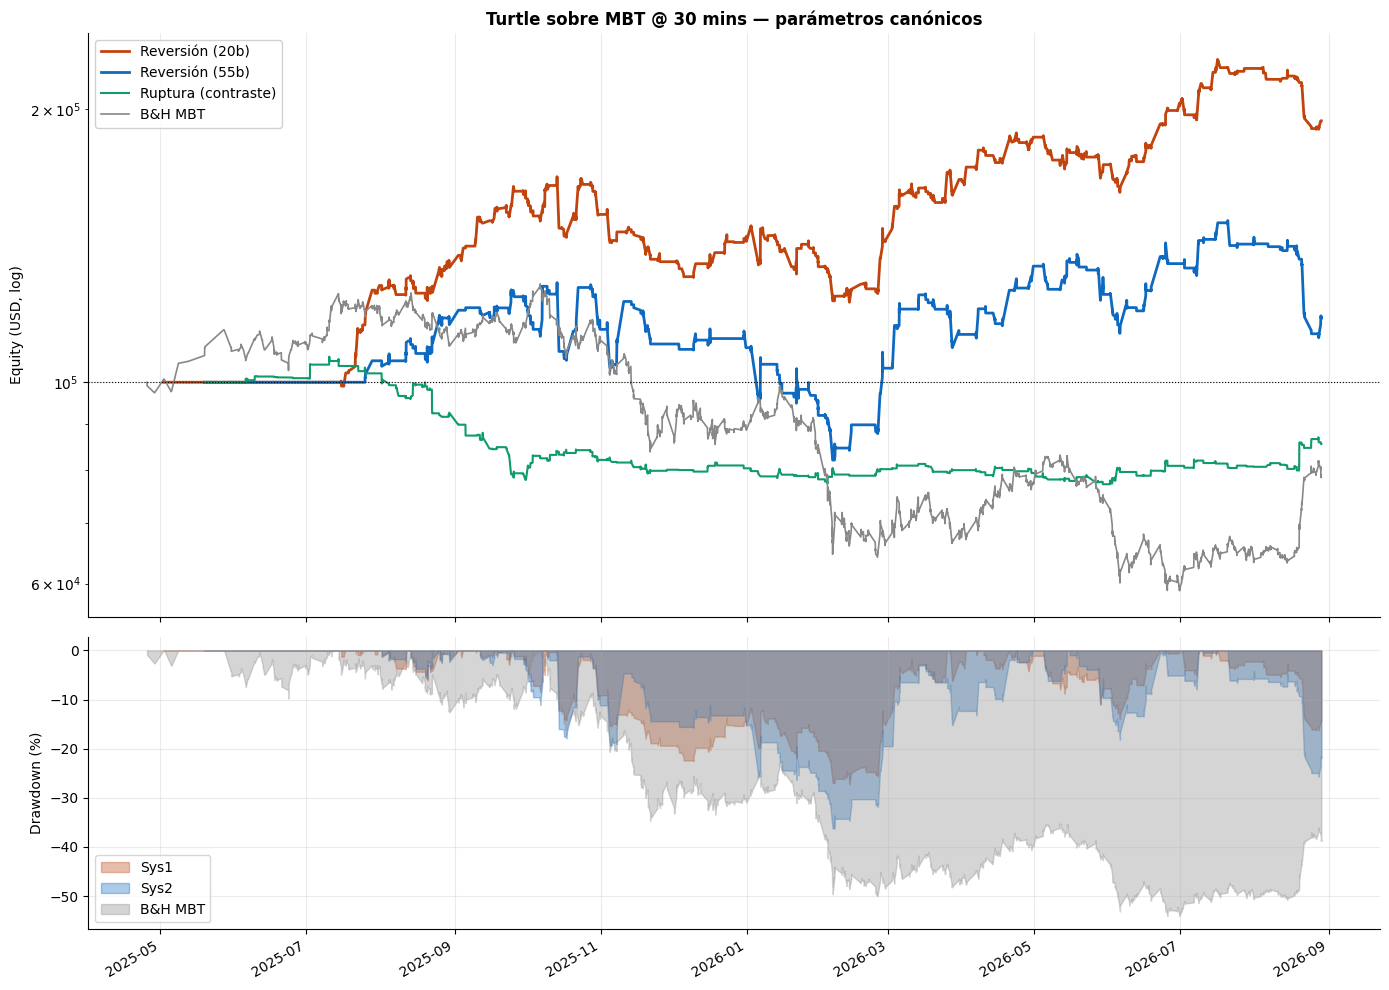

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[2, 1], sharex=True)

for ec, lab, c, lw in [
        (ec_s1,   f"Reversión ({SYS1['entry']}b)", "#c1440e", 2),
        (ec_s2,   f"Reversión ({SYS2['entry']}b)", "#0e6ac1", 2),
        (ec_brk, "Ruptura (contraste)", "#0e9c6a", 1.5),
        (bh,      f"B&H {_bh_sym}", "#888", 1.2)]:
    if len(ec):
        ax[0].plot(ec.index, ec.values, label=lab, color=c, lw=lw)

ax[0].axhline(EQUITY_0, color="k", ls=":", lw=0.8)
if min([ec.min() for ec in (ec_s1, ec_s2, ec_brk, bh) if len(ec)] or [1]) > 0:
    ax[0].set_yscale("log")
ax[0].set_ylabel("Equity (USD, log)")
ax[0].set_title(f"Turtle sobre {'/'.join(RAW)} @ {BAR_SIZE} — parámetros canónicos",
                fontweight="bold")
ax[0].legend(loc="upper left", framealpha=0.9)

for ec, lab, c in [(ec_s1, "Sys1", "#c1440e"), (ec_s2, "Sys2", "#0e6ac1"),
                   (bh, f"B&H {_bh_sym}", "#888")]:
    if len(ec):
        ax[1].fill_between(ec.index, (ec/ec.cummax()-1)*100, 0, alpha=0.35, color=c, label=lab)
ax[1].set_ylabel("Drawdown (%)"); ax[1].legend(loc="lower left")
fig.autofmt_xdate()
plt.tight_layout(); plt.show()

## 7. Walk-Forward Optimization

**Diseño:** ventanas rodantes ancladas al **índice de barras**, no al calendario. Es el cambio
necesario para que el mismo código sirva a `1 secs` y a `1 day`: "365 días" no significa nada
cuando la barra es un segundo, mientras que "un año de barras" sí — y sale de `BARS_PER_YEAR`,
medido sobre los datos reales en §3.

- **In-sample (IS):** `IS_BARS` → se optimiza la rejilla
- **Out-of-sample (OOS):** `OOS_BARS` → se aplican los parámetros ganadores, sin tocar nada
- **Paso:** `OOS_BARS` (las ventanas OOS no se solapan → track record OOS concatenable)
- **Embargo:** `EMBARGO_BARS` barras recortadas del FINAL de cada IS. Un trade abierto en las
  últimas barras del IS sigue vivo dentro del OOS, así que su desenlace pertenece al periodo con
  el que se está evaluando y el parámetro elegido ya lo ha visto. El horizonte de la etiqueta es
  `MAX_HOLD_BARS`, que fija el solape máximo y por tanto el embargo mínimo.

**Selección:** Sharpe IS penalizado por drawdown. Optimizar Sharpe sin penalizar selecciona el
parámetro más apalancado de la rejilla.

El número de folds depende de la muestra, y con un solo subyacente cada fold OOS contiene pocos
trades. Se usa como diagnóstico de estabilidad del sistema fijo. Si `n_folds` sale por debajo de
8, el t-test no tiene potencia y la celda lo reporta.

In [24]:
# Ventanas en BARRAS, derivadas de la granularidad (§3). Con muestras cortas se
# recortan proporcionalmente para no quedarse con cero folds.
_n_bars = len(next(iter(DATA_MAIN.values())))
IS_BARS  = int(min(BARS_PER_YEAR,      _n_bars * 0.40))
OOS_BARS = int(min(BARS_PER_YEAR/4,    _n_bars * 0.10))
IS_BARS, OOS_BARS = max(IS_BARS, ATR_PERIOD*4), max(OOS_BARS, ATR_PERIOD*2)

print(f"  Barras disponibles : {_n_bars:,}")
print(f"  IS  : {IS_BARS:,} barras (~{IS_BARS/BARS_PER_YEAR:.2f} años)")
print(f"  OOS : {OOS_BARS:,} barras (~{OOS_BARS/BARS_PER_YEAR*12:.1f} meses)")
print(f"  Folds estimados : {max(0, (_n_bars - IS_BARS)//OOS_BARS)}")

# Rejilla deliberadamente pequeña. Rejillas grandes sobre muestras cortas =
# overfitting garantizado (skill /backtester).
GRID = [
    {"entry": e, "exit": x, "stop_n": sn, "risk": rk}
    for e, x in [(20, 10), (55, 20), (100, 20)]
    for sn in [1.0, 2.0]
    for rk in [0.005, 0.01]
]
print(f"\n  Combinaciones: {len(GRID)}")

# Pre-computar datasets por (entry, exit). El par del sistema de la tesis siempre
# presente: es el baseline de parámetros fijos contra el que se compara cada fold.
_MAIN_PAIR = (SYS_MAIN["entry"], SYS_MAIN["exit"])
_ALT_PAIR  = (SYS_ALT["entry"],  SYS_ALT["exit"])
_pairs = sorted({(g["entry"], g["exit"]) for g in GRID} | {_MAIN_PAIR, _ALT_PAIR})
PREP = {p: {s: prepare(d, *p) for s, d in RAW.items()} for p in _pairs}
print(f"  Datasets precomputados: {len(PREP)}")

  Barras disponibles : 4,264
  IS  : 1,705 barras (~0.53 años)
  OOS : 426 barras (~1.6 meses)
  Folds estimados : 6

  Combinaciones: 12
  Datasets precomputados: 3


*MAE* is defined as a percentile of the winners' MAE distribution — a statistic of realized trade outcomes, i.e. it conditions on the label. Under checklist.md:25-26 and lopez_de_prado.md:43-66, computing it on the full sample is a full-sample normalization and the winner/loser split is itself outcome information; it must be estimated inside each training fold, with the t1 used for purging being the trade close under the fold-local threshold. Additionally, changing the stop changes t1, which changes the purge sets — so the fold construction is not fixed across candidate thresholds. Neither lopez_de_prado.md nor MAE.md addresses this circularity, and no script handles it.

In [25]:
def score_is(ec, penalty=0.5):
    """Sharpe IS penalizado por drawdown. Evita elegir el parámetro más apalancado."""
    m = metrics(ec)
    if not m or m["Volatilidad"] == 0:
        return -np.inf
    return m["Sharpe"] - penalty*abs(m["Max DD"])


def walk_forward(is_bars=None, oos_bars=None, grid=None, embargo=None, verbose=True):
    """WFO rodante por POSICIÓN de barra. Devuelve (df_folds, equity_oos_concatenada).

    `embargo` (por defecto EMBARGO_BARS) recorta el final de cada ventana IS. Sin
    ese recorte, un trade abierto en las últimas barras del IS sigue vivo dentro
    del OOS: su desenlace pertenece al periodo con el que se está evaluando, y el
    parámetro elegido lo ha visto. El horizonte de la etiqueta es MAX_HOLD_BARS,
    así que ese es el solape máximo y el embargo mínimo (§7).
    """
    is_bars, oos_bars, grid = is_bars or IS_BARS, oos_bars or OOS_BARS, grid or GRID
    embargo = EMBARGO_BARS if embargo is None else embargo
    assert is_bars > embargo + ATR_PERIOD, (
        f"IS de {is_bars} barras no soporta un embargo de {embargo}")
    # Índice maestro: unión de barras de todos los símbolos, ordenada. Con un solo
    # subyacente es el índice del símbolo; con MBT+BRR se alinean los dos calendarios.
    idx = pd.DatetimeIndex(sorted(set().union(*[set(d.index) for d in RAW.values()])))

    folds, oos_rets, i = [], [], is_bars
    while i + oos_bars <= len(idx):
        # El IS termina EMBARGO_BARS antes de que empiece el OOS.
        is_a, is_b   = idx[i-is_bars], idx[i-1-embargo]
        oos_a, oos_b = idx[i], idx[min(i+oos_bars, len(idx)-1)]

        best, best_sc = None, -np.inf
        for g in grid:
            ec, _ = run_turtle(PREP[(g["entry"], g["exit"])], g["entry"], g["exit"],
                               **cfg(stop_n=g["stop_n"], risk=g["risk"],
                                     start=is_a, end=is_b))
            sc = score_is(ec)
            if sc > best_sc:
                best_sc, best = sc, g

        ec_o, tr_o = run_turtle(PREP[(best["entry"], best["exit"])], best["entry"], best["exit"],
                                **cfg(stop_n=best["stop_n"], risk=best["risk"],
                                      start=oos_a, end=oos_b))
        ec_b, _ = run_turtle(PREP[_MAIN_PAIR], *_MAIN_PAIR, **cfg(start=oos_a, end=oos_b))

        r_oos  = ec_o.iloc[-1]/ec_o.iloc[0]-1 if len(ec_o) > 1 else 0.0
        r_base = ec_b.iloc[-1]/ec_b.iloc[0]-1 if len(ec_b) > 1 else 0.0

        folds.append({"fold": len(folds)+1, "oos_ini": oos_a, "oos_fin": oos_b,
                      **{f"p_{k}": v for k, v in best.items()},
                      "IS_score": round(best_sc, 3), "OOS_ret": r_oos,
                      "BASE_ret": r_base, "trades": len(tr_o)})
        if len(ec_o) > 1:
            oos_rets.append(ec_o.pct_change().dropna())
        if verbose:
            print(f"  Fold {len(folds):2d} | {oos_a:%Y-%m-%d %H:%M} → {oos_b:%Y-%m-%d %H:%M} | "
                  f"e{best['entry']}/x{best['exit']} sn{best['stop_n']} r{best['risk']} | "
                  f"OOS {r_oos:+7.2%} vs base {r_base:+7.2%} ({len(tr_o)} trades)")
        i += oos_bars

    df = pd.DataFrame(folds)
    eq = (EQUITY_0*(1+pd.concat(oos_rets).sort_index()).cumprod()) if oos_rets else pd.Series(dtype=float)
    return df, eq

print(f"Ejecutando walk-forward (embargo {EMBARGO_BARS} barras entre IS y OOS)...\n")
FOLDS, EC_WFO = walk_forward()

Ejecutando walk-forward (embargo 10 barras entre IS y OOS)...

  Fold  1 | 2025-11-18 18:00 → 2026-01-12 19:00 | e20/x10 sn1.0 r0.01 | OOS  +2.31% vs base  +2.31% (27 trades)
  Fold  2 | 2026-01-12 19:00 → 2026-03-04 16:00 | e20/x10 sn1.0 r0.01 | OOS  +9.96% vs base  +9.96% (33 trades)
  Fold  3 | 2026-03-04 16:00 → 2026-04-17 14:00 | e20/x10 sn1.0 r0.01 | OOS +19.08% vs base +19.08% (28 trades)
  Fold  4 | 2026-04-17 14:00 → 2026-06-01 17:00 | e20/x10 sn1.0 r0.005 | OOS  -0.68% vs base  -1.25% (32 trades)
  Fold  5 | 2026-06-01 17:00 → 2026-07-15 20:00 | e20/x10 sn1.0 r0.005 | OOS +25.25% vs base +51.55% (31 trades)
  Fold  6 | 2026-07-15 20:00 → 2026-08-27 16:00 | e20/x10 sn1.0 r0.01 | OOS -29.21% vs base -29.21% (24 trades)


In [26]:
if not len(FOLDS):
    print("Sin folds: la muestra no da para IS+OOS. Baja BAR_SIZE o sube LOOKBACK_DAYS.")
else:
    display(FOLDS.style.format({"OOS_ret": "{:+.2%}", "BASE_ret": "{:+.2%}",
                                "IS_score": "{:.3f}"})
            .background_gradient(subset=["OOS_ret"], cmap="RdYlGn", vmin=-0.3, vmax=0.3))

    wins = int((FOLDS.OOS_ret > FOLDS.BASE_ret).sum())
    print(f"\n{'='*70}")
    print(f"  WFO gana al sistema de parámetros fijos en {wins}/{len(FOLDS)} folds ({wins/len(FOLDS):.0%})")
    print(f"  Retorno OOS medio  — WFO: {FOLDS.OOS_ret.mean():+.2%} | "
          f"baseline: {FOLDS.BASE_ret.mean():+.2%}")
    print(f"  Folds OOS positivos— WFO: {(FOLDS.OOS_ret>0).mean():.0%} | "
          f"baseline: {(FOLDS.BASE_ret>0).mean():.0%}")
    print(f"  Trades OOS totales : {FOLDS.trades.sum()} "
          f"(mediana {FOLDS.trades.median():.0f} por fold)")
    print(f"{'='*70}")

    from scipy import stats
    d = FOLDS.OOS_ret - FOLDS.BASE_ret
    t, p = stats.ttest_1samp(d, 0) if len(d) > 1 else (np.nan, 1.0)
    print(f"\n  t-test (WFO − baseline): t={t:.3f}, p={p:.3f}, n={len(d)}")
    if len(d) < 8:
        print(f"  ⚠️  n={len(d)} folds: el test NO tiene potencia. No concluyas nada de p.")
    print(f"  → {'Diferencia NO significativa entre WFO y parámetros fijos.' if p > 0.05 else f'Diferencia significativa (n = {len(d)} folds).'}")

    print(f"\n  Estabilidad de parámetros elegidos:")
    for c in ["p_entry", "p_exit", "p_stop_n", "p_risk"]:
        vc = FOLDS[c].value_counts()
        print(f"    {c:<10}: {dict(vc)}  → moda {vc.iloc[0]/len(FOLDS):.0%} de los folds")

,fold,oos_ini,oos_fin,p_entry,p_exit,p_stop_n,p_risk,IS_score,OOS_ret,BASE_ret,trades
0,1,2025-11-18 18:00:00,2026-01-12 19:00:00,20,10,1.000000,0.010000,2.600,+2.31%,+2.31%,27
1,2,2026-01-12 19:00:00,2026-03-04 16:00:00,20,10,1.000000,0.010000,2.669,+9.96%,+9.96%,33
2,3,2026-03-04 16:00:00,2026-04-17 14:00:00,20,10,1.000000,0.010000,0.886,+19.08%,+19.08%,28
3,4,2026-04-17 14:00:00,2026-06-01 17:00:00,20,10,1.000000,0.005000,0.358,-0.68%,-1.25%,32
4,5,2026-06-01 17:00:00,2026-07-15 20:00:00,20,10,1.000000,0.005000,1.176,+25.25%,+51.55%,31
5,6,2026-07-15 20:00:00,2026-08-27 16:00:00,20,10,1.000000,0.010000,3.840,-29.21%,-29.21%,24



  WFO gana al sistema de parámetros fijos en 1/6 folds (17%)
  Retorno OOS medio  — WFO: +4.45% | baseline: +8.74%
  Folds OOS positivos— WFO: 67% | baseline: 67%
  Trades OOS totales : 175 (mediana 30 por fold)

  t-test (WFO − baseline): t=-0.974, p=0.375, n=6
  ⚠️  n=6 folds: el test NO tiene potencia. No concluyas nada de p.
  → Diferencia NO significativa entre WFO y parámetros fijos.

  Estabilidad de parámetros elegidos:
    p_entry   : {20: np.int64(6)}  → moda 100% de los folds
    p_exit    : {10: np.int64(6)}  → moda 100% de los folds
    p_stop_n  : {1.0: np.int64(6)}  → moda 100% de los folds
    p_risk    : {0.01: np.int64(4), 0.005: np.int64(2)}  → moda 67% de los folds


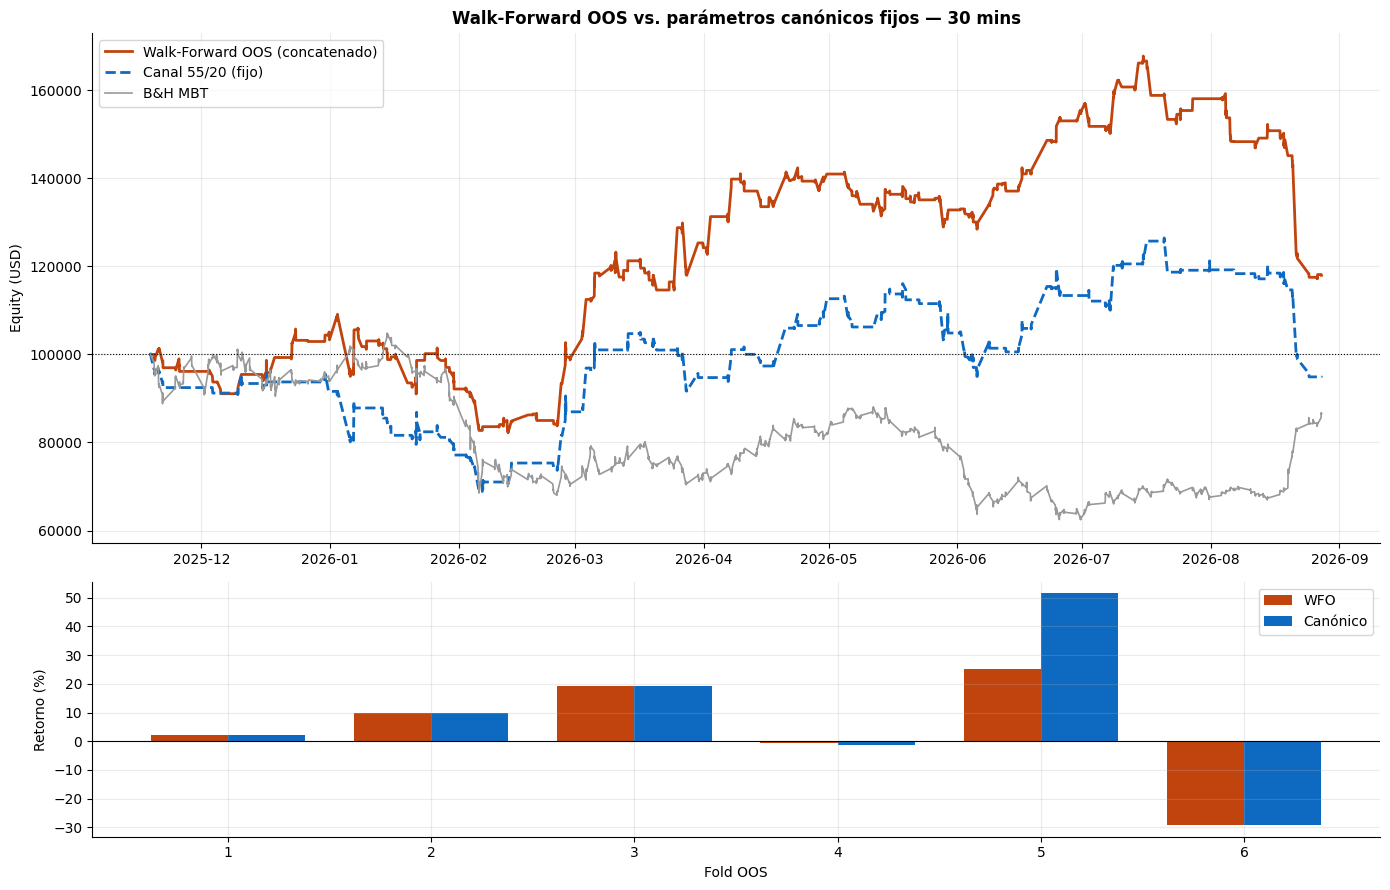


  WALK-FORWARD OUT-OF-SAMPLE
  Retorno total         :     17.97%
  CAGR                  :     23.88%
  Volatilidad           :     43.70%
  Sharpe                :       0.55
  Sortino               :       0.39
  Max DD                :    -30.13%
  Calmar                :       0.79
  Barras en DD>20%      :        218
  Años                  :       0.77


In [27]:
if len(FOLDS) and len(EC_WFO):
    fig, ax = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[2, 1])

    ax[0].plot(EC_WFO.index, EC_WFO.values, label="Walk-Forward OOS (concatenado)",
               color="#c1440e", lw=2)
    ec_b_full, _ = run_turtle(PREP[_ALT_PAIR], *_ALT_PAIR, **cfg())
    _al = ec_b_full.reindex(EC_WFO.index).ffill()
    ax[0].plot(_al.index, (_al/_al.iloc[0]*EQUITY_0).values,
               label=f"Canal {SYS_ALT['entry']}/{SYS_ALT['exit']} (fijo)", color="#0e6ac1", lw=2, ls="--")
    _bt = bh.reindex(EC_WFO.index).ffill()
    ax[0].plot(_bt.index, (_bt/_bt.iloc[0]*EQUITY_0).values,
               label=f"B&H {_bh_sym}", color="#999", lw=1.2)
    ax[0].axhline(EQUITY_0, color="k", ls=":", lw=0.8)
    ax[0].set_ylabel("Equity (USD)")
    ax[0].set_title(f"Walk-Forward OOS vs. parámetros canónicos fijos — {BAR_SIZE}",
                    fontweight="bold")
    ax[0].legend()

    w = 0.38; x = np.arange(len(FOLDS))
    ax[1].bar(x-w/2, FOLDS.OOS_ret*100, w, label="WFO", color="#c1440e")
    ax[1].bar(x+w/2, FOLDS.BASE_ret*100, w, label="Canónico", color="#0e6ac1")
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].set_xticks(x); ax[1].set_xticklabels(FOLDS.fold)
    ax[1].set_xlabel("Fold OOS"); ax[1].set_ylabel("Retorno (%)"); ax[1].legend()
    plt.tight_layout(); plt.show()

    show(metrics(EC_WFO), "WALK-FORWARD OUT-OF-SAMPLE")

## 8. Cuantificación de sesgos

El sesgo 1 sustituye al *survivorship* del notebook diversificado: con un solo subyacente que
sigue vivo no hay supervivencia que medir, pero sí un problema equivalente de construcción de la
serie — el roll.


In [28]:
# ── SESGO 1: ROLL / EMPALME DE CONTRATOS ──
# La serie se cose sin ajustar: en cada roll hay un salto de precio entre el
# contrato que se abandona y el que se toma. Ese salto entra en la curva como un
# retorno que ninguna posición realizó: es un artefacto del
# empalme. Con DATA_SOURCE="chain" las fechas de roll son conocidas (§3), así que
# se mide en el punto exacto de cada roll.
print("="*74); print("  SESGO 1 — ROLL / EMPALME DE CONTRATOS"); print("="*74)

ROLL_IMPACT = {}
for s, d in RAW.items():
    r = ROLLS.get(s, pd.DataFrame())
    ret = d["close"].pct_change(fill_method=None)

    if len(r) > 1:
        # Salto medido EN el empalme: último cierre del contrato saliente contra
        # el primer cierre del entrante.
        saltos = []
        for i in range(1, len(r)):
            t0, t1 = pd.Timestamp(r.hasta.iloc[i-1]), pd.Timestamp(r.desde.iloc[i])
            prev_px = float(r.ultimo_close.iloc[i-1])
            post = d.loc[d.index >= t1, "close"]
            if not len(post) or prev_px <= 0:
                continue
            saltos.append({"de": r.contrato.iloc[i-1], "a": r.contrato.iloc[i],
                           "fecha": t1, "close_saliente": prev_px,
                           "close_entrante": float(post.iloc[0]),
                           "salto": float(post.iloc[0])/prev_px - 1})
        sdf = pd.DataFrame(saltos)
        if len(sdf):
            anios = max(_span_days/365.25, 1e-9)
            impacto = sdf.salto.sum()
            ROLL_IMPACT[s] = impacto/anios
            print(f"\n  {s}: {len(sdf)} rolls en {anios:.2f} años")
            print(f"     Salto medio        : {sdf.salto.mean():+.3%}")
            print(f"     Salto absoluto máx.: {sdf.salto.abs().max():.3%}")
            print(f"     Suma de saltos     : {impacto:+.2%}  →  "
                  f"{impacto/anios:+.2%}/año de retorno que NO es del mercado")
            display(sdf.style.format({"salto": "{:+.3%}", "close_saliente": "{:,.2f}",
                                      "close_entrante": "{:,.2f}", "fecha": "{:%Y-%m-%d %H:%M}"})
                    .background_gradient(subset=["salto"], cmap="RdYlGn"))
            _cagr_s2 = metrics(ec_main).get("CAGR", float("nan")) if len(ec_main) else float("nan")
            print(f"     ⚠ Compáralo con el CAGR del Sistema 2 ({_cagr_s2:+.2%}): si el")
            print( "       impacto anual del roll es del mismo orden, el resultado del")
            print( "       backtest está dominado por el empalme, no por la estrategia.")
    else:
        # Sin tabla de rolls (DATA_SOURCE="cont"): IB no dice dónde empalmó, así
        # que solo queda el proxy estadístico — saltos anómalos barra a barra.
        gap = (d["open"] - d["close"].shift(1)).abs() / d["close"].shift(1)
        thr = max(gap.quantile(0.999), 0.005)
        big = gap[gap > thr].dropna()
        ROLL_IMPACT[s] = float(big.sum()) / max(_span_days/365.25, 1e-9)
        print(f"\n  {s} (fuente 'cont' — IB no expone las fechas de roll):")
        print(f"     {len(big)} saltos barra-a-barra por encima de {thr:.2%}")
        if len(big):
            print(f"     Salto medio {big.mean():.2%} | máximo {big.max():.2%} | "
                  f"suma {big.sum():.2%} ≈ {ROLL_IMPACT[s]:+.2%}/año")
        print( "     Es un PROXY, no una medida: cambia a DATA_SOURCE='chain' para")
        print( "     medir el empalme en el punto exacto.")

  SESGO 1 — ROLL / EMPALME DE CONTRATOS

  MBT: 12 rolls en 1.34 años
     Salto medio        : +1.231%
     Salto absoluto máx.: 5.031%
     Suma de saltos     : +14.77%  →  +11.01%/año de retorno que NO es del mercado


,de,a,fecha,close_saliente,close_entrante,salto
0,MBTU5,MBTV5,2025-09-24 13:30,"112,050.00","113,755.00",+1.522%
1,MBTV5,MBTX5,2025-10-29 13:30,"112,915.00","113,450.00",+0.474%
2,MBTX5,MBTZ5,2025-11-26 14:30,"87,030.00","87,180.00",+0.172%
3,MBTZ5,MBTF6,2025-12-24 14:30,"87,655.00","87,350.00",-0.348%
4,MBTF6,MBTG6,2026-01-28 14:30,"89,100.00","89,915.00",+0.915%
5,MBTG6,MBTH6,2026-02-25 14:30,"64,105.00","67,330.00",+5.031%
6,MBTH6,MBTJ6,2026-03-25 13:30,"70,115.00","71,835.00",+2.453%
7,MBTJ6,MBTK6,2026-04-22 13:30,"75,735.00","79,365.00",+4.793%
8,MBTK6,MBTM6,2026-05-27 13:30,"75,960.00","75,175.00",-1.033%
9,MBTM6,MBTN6,2026-06-24 13:30,"62,385.00","61,495.00",-1.427%


     ⚠ Compáralo con el CAGR del Sistema 2 (+65.03%): si el
       impacto anual del roll es del mismo orden, el resultado del
       backtest está dominado por el empalme, no por la estrategia.


In [29]:
# Verdad de campo: la serie que se ha backtesteado contra el contrato que se
# operaría HOY. Si divergen, el backtest opera precios que el contrato real no tuvo.
if IBS is None:
    print("  Sin sesión IBKR: no se puede contrastar contra el contrato vigente.")
else:
    for s in RAW:
        try:
            contract, detail, expiry = front_month(
                IBS, s, UNIVERSE[s]["exchange"], UNIVERSE[s]["currency"])
            dur, _ = ib_chunk(BAR_SECONDS)
            bars = IBS.reqHistoricalData(contract, endDateTime="", durationStr=dur,
                                         barSizeSetting=BAR_SIZE, whatToShow=WHAT_TO_SHOW,
                                         useRTH=USE_RTH, formatDate=2, timeout=60)
            real = _bars_to_df(bars)
            common = RAW[s].index.intersection(real.index)
            if len(common) < 10:
                print(f"  {s}: solapamiento insuficiente ({len(common)} barras)"); continue
            rel = (RAW[s].loc[common, "close"] - real.loc[common, "close"]) / real.loc[common, "close"]
            print(f"\n  {s} — serie usada vs. {contract.localSymbol} (exp. {expiry}), "
                  f"{len(common)} barras solapadas")
            print(f"     Diferencia media : {rel.mean():+.4%}")
            print(f"     Diferencia máx.  : {rel.abs().max():.4%}")
            print(f"     {'✓ La serie sigue al contrato vigente en esta ventana.' if rel.abs().max() < 0.002 else '⚠ Divergen: el backtest opera precios que el contrato real no tuvo.'}")
        except Exception as e:
            print(f"  {s}: no se pudo contrastar ({e})")


  MBT — serie usada vs. MBTU6 (exp. 2026-09-25), 210 barras solapadas
     Diferencia media : -0.3093%
     Diferencia máx.  : 0.6270%
     ⚠ Divergen: el backtest opera precios que el contrato real no tuvo.


  SESGO 2 — CONCENTRACIÓN DE P&L

  Top  1 trades =  13.5% del P&L total

  Top  3 trades =  38.7% del P&L total

  Top  5 trades =  62.3% del P&L total

  Top 10 trades = 114.5% del P&L total

  P&L total: $98,826 en 272 trades
  Sin el mejor trade: $85,501  (+85.5% sobre capital inicial)

  Mejores 5 trades:


,symbol,side,opened,closed,units,contracts,pnl,horas
0,MBT,-1,2025-10-21 17:00:00,2025-10-22 13:30:00,4,36,13324.68,20.5
1,MBT,-1,2026-01-05 19:30:00,2026-01-06 17:30:00,4,52,12603.76,22.0
2,MBT,-1,2026-07-07 16:30:00,2026-07-08 13:30:00,3,63,12277.44,21.0
3,MBT,1,2026-03-24 18:30:00,2026-03-25 13:30:00,3,54,11981.52,19.0
4,MBT,1,2026-06-18 18:00:00,2026-06-22 13:30:00,3,54,11387.52,91.5



  Peores 5 trades:


,symbol,side,opened,closed,units,contracts,pnl,horas
267,MBT,1,2026-05-27 18:30:00,2026-05-28 13:30:00,2,44,-8365.28,19.0
268,MBT,1,2025-11-03 16:30:00,2025-11-04 14:30:00,3,30,-9513.60,22.0
269,MBT,-1,2026-01-02 18:00:00,2026-01-05 14:30:00,3,42,-11282.04,68.5
270,MBT,-1,2026-08-20 18:30:00,2026-08-21 13:30:00,2,34,-15465.58,19.0
271,MBT,1,2025-10-13 15:30:00,2025-10-14 13:30:00,4,40,-16884.80,22.0


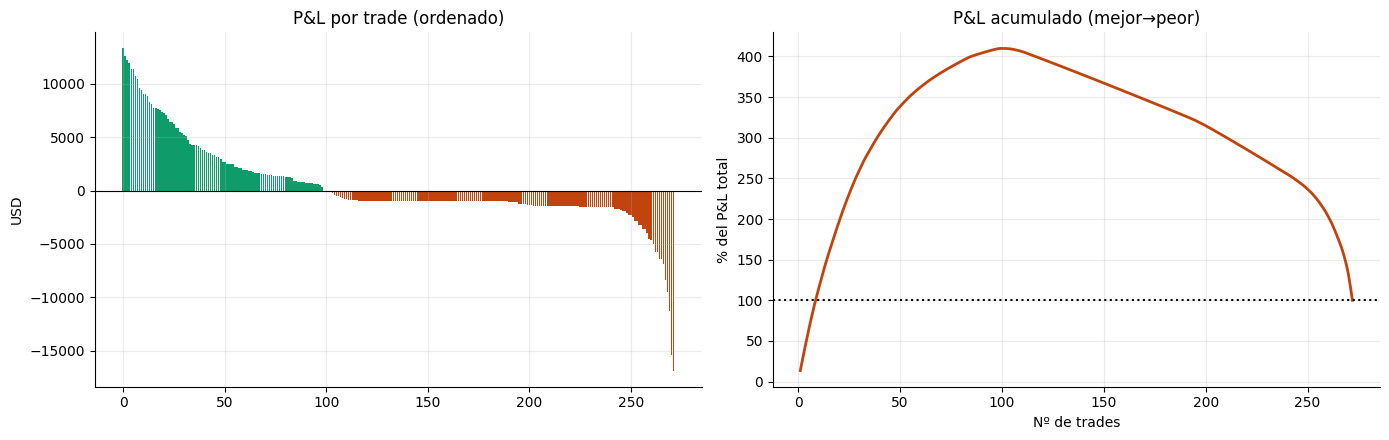

In [30]:
# ── SESGO 2: CONCENTRACIÓN DE P&L ──
# Turtle vive de pocas tendencias enormes. Si 3 trades hacen todo el resultado,
# el track record es una muestra de tamaño 3, no de tamaño N. Con UN subyacente
# esto es mucho peor que en el notebook diversificado: no hay 50 mercados donde
# repartir la suerte.
print("="*74); print("  SESGO 2 — CONCENTRACIÓN DE P&L"); print("="*74)

if not len(tr_main):
    print("\n  Sin trades cerrados: nada que concentrar (revisa §6, ejecutabilidad).")
    tr, tot = tr_main, 0.0
else:
    tr = tr_main.sort_values("pnl", ascending=False).reset_index(drop=True)
    tot = tr.pnl.sum()
    for k in [1, 3, 5, 10]:
        if len(tr) >= k and tot:
            print(f"\n  Top {k:>2} trades = {tr.pnl.head(k).sum()/tot:>6.1%} del P&L total")
    print(f"\n  P&L total: ${tot:,.0f} en {len(tr)} trades")
    if tot:
        print(f"  Sin el mejor trade: ${tot - tr.pnl.iloc[0]:,.0f}  "
              f"({(tot-tr.pnl.iloc[0])/EQUITY_0:+.1%} sobre capital inicial)")

    print(f"\n  Mejores 5 trades:"); display(
        tr.head(5)[["symbol","side","opened","closed","units","contracts","pnl","horas"]])
    print(f"\n  Peores 5 trades:"); display(
        tr.tail(5)[["symbol","side","opened","closed","units","contracts","pnl","horas"]])

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    ax[0].bar(range(len(tr)), tr.pnl.values,
              color=np.where(tr.pnl > 0, "#0e9c6a", "#c1440e"))
    ax[0].set_title("P&L por trade (ordenado)"); ax[0].set_ylabel("USD")
    ax[0].axhline(0, color="k", lw=.8)
    if tot:
        ax[1].plot(np.arange(1, len(tr)+1), tr.pnl.cumsum().values/tot*100,
                   color="#c1440e", lw=2)
        ax[1].axhline(100, ls=":", color="k")
    ax[1].set_title("P&L acumulado (mejor→peor)")
    ax[1].set_xlabel("Nº de trades"); ax[1].set_ylabel("% del P&L total")
    plt.tight_layout(); plt.show()

In [31]:
# ── SESGO 3: DIVERSIFICACIÓN — cuántas apuestas independientes hay realmente ──
# En el notebook diversificado esto era una matriz de correlación de 50 activos.
# Aquí el resultado se conoce de antemano y por eso mismo hay que escribirlo:
# MBT y BRR son el MISMO subyacente. n_eff ≈ 1.
print("="*74); print("  SESGO 3 — DIVERSIFICACIÓN INEXISTENTE"); print("="*74)

if len(RAW) < 2:
    n_eff = 1.0
    print(f"\n  Un solo instrumento ({list(RAW)[0]}) → n_eff = 1.00 por construcción.")
else:
    rets = pd.DataFrame({s: d["close"].pct_change(fill_method=None) for s, d in RAW.items()})
    rets = rets.replace([np.inf, -np.inf], np.nan).dropna()
    corr = rets.corr()
    display(corr.style.background_gradient(cmap="RdYlGn_r", vmin=-1, vmax=1))
    ev = np.linalg.eigvalsh((corr.values + corr.values.T)/2)[::-1]
    ev = ev[ev > 1e-12]
    n_eff = (ev.sum()**2)/(ev**2).sum()
    print(f"\n  Correlación MBT–BRR : {corr.iloc[0,1]:.4f}")
    print(f"  n_eff               : {n_eff:.2f} sobre {len(corr)} instrumentos")

print(f"\n  ➜ Nº EFECTIVO de apuestas independientes: {n_eff:.2f}")
print( "     El sistema Turtle original operaba ~20 futuros genuinamente descorrelacionados.")
print(f"     Con {n_eff:.0f}, la ley de los grandes números que hacía viable un win-rate del")
print( "     35% sencillamente no opera. Un drawdown del 50%+ no es cola: es el escenario")
print( "     central. Éste es el hallazgo más importante de este notebook.")

  SESGO 3 — DIVERSIFICACIÓN INEXISTENTE

  Un solo instrumento (MBT) → n_eff = 1.00 por construcción.

  ➜ Nº EFECTIVO de apuestas independientes: 1.00
     El sistema Turtle original operaba ~20 futuros genuinamente descorrelacionados.
     Con 1, la ley de los grandes números que hacía viable un win-rate del
     35% sencillamente no opera. Un drawdown del 50%+ no es cola: es el escenario
     central. Éste es el hallazgo más importante de este notebook.


In [32]:
# ── SESGO 4: SENSIBILIDAD A COSTES ──
# Si el edge muere al doblar el slippage, no era un edge. En un futuro el coste
# NO es proporcional al nocional: es fijo por contrato, así que su peso relativo
# crece cuando el sizing se hace pequeño y cuando la granularidad se hace fina.
print("="*74); print("  SESGO 4 — SENSIBILIDAD A COSTES"); print("="*74)

def _scaled(mult_comm, slip_ticks):
    return {s: {"comm": COSTS[s]["comm"]*mult_comm, "slip_ticks": slip_ticks}
            for s in COSTS}

rows = []
for lbl, mc, st in [("Sin costes", 0.0, 0.0), ("Optimista", 0.5, 0.0),
                    ("Base", 1.0, COSTS[next(iter(COSTS))]["slip_ticks"]),
                    ("Pesimista", 1.5, 2.0), ("Estrés", 2.0, 4.0)]:
    ec_c, tr_c = run_turtle(DATA_S1, SYS_MAIN["entry"], SYS_MAIN["exit"],
                            **cfg(costs=_scaled(mc, st)))
    m = metrics(ec_c, tr_c)
    rows.append({"Escenario": lbl, "Comisión ×": mc, "Slippage (ticks)": st,
                 "CAGR": m.get("CAGR", np.nan), "Sharpe": m.get("Sharpe", np.nan),
                 "MaxDD": m.get("Max DD", np.nan), "Trades": m.get("Trades", 0)})

cost_df = pd.DataFrame(rows)
display(cost_df.style.format({"CAGR": "{:+.2%}", "MaxDD": "{:.1%}", "Sharpe": "{:.2f}"})
        .background_gradient(subset=["CAGR"], cmap="RdYlGn"))

deg = cost_df.CAGR.iloc[0] - cost_df.CAGR.iloc[2]
print(f"\n  Coste de fricción: {deg:.2%} de CAGR (sin costes → base)")
print(f"  {'⚠️  El edge NO sobrevive costes realistas.' if cost_df.CAGR.iloc[3] <= 0 else '✓ El edge sobrevive el escenario pesimista.'}")

# Demostración de por qué FUNDING = 0 en futuros: cobrarlo es inventar un coste
# que escala con el nocional mientras el sizing escala con el riesgo.
ec_f, tr_f = run_turtle(DATA_S1, SYS_MAIN["entry"], SYS_MAIN["exit"],
                        **cfg(funding=0.0001*3))
m_f = metrics(ec_f, tr_f)
print(f"\n  Control — si se cobrara funding de perpetuo (11%/año) a un futuro:")
print(f"     CAGR {cost_df.CAGR.iloc[2]:+.2%} → {m_f.get('CAGR', float('nan')):+.2%}   "
      f"(los futuros listados no pagan funding)")

  SESGO 4 — SENSIBILIDAD A COSTES


,Escenario,Comisión ×,Slippage (ticks),CAGR,Sharpe,MaxDD,Trades
0,Sin costes,0.000000,0.000000,+64.07%,1.75,-32.1%,272
1,Optimista,0.500000,0.000000,+62.58%,1.73,-32.3%,272
2,Base,1.000000,1.000000,+65.03%,1.86,-27.3%,272
3,Pesimista,1.500000,2.000000,+55.75%,1.56,-28.1%,273
4,Estrés,2.000000,4.000000,+32.85%,0.89,-31.6%,274



  Coste de fricción: -0.97% de CAGR (sin costes → base)
  ✓ El edge sobrevive el escenario pesimista.

  Control — si se cobrara funding de perpetuo (11%/año) a un futuro:
     CAGR +65.03% → +7.00%   (los futuros listados no pagan funding)


In [33]:
# ── SESGO 5: FRAGILIDAD DE LA MUESTRA ──
# El sesgo de mayor magnitud medido en este notebook, y el que no aparece en
# ninguna métrica de la curva. Truncar el inicio de la muestra desplaza la EMA-20
# de N y los canales Donchian; eso cambia qué barra dispara, y el desplazamiento
# se propaga a toda la serie. El efecto NO es de P&L de los trades eliminados:
# es de realineamiento de señales.
#
# Se mide moviendo solo el inicio, con el mismo final y los mismos parámetros.
_offsets = [0, 20, 40, 60, 80, 100, 120, 160]
_n0 = min(len(d) for d in RAW.values())
_offsets = [k for k in _offsets if k < _n0 - (ATR_PERIOD + SYS_MAIN["entry"] + 200)]

_rows = []
for k in _offsets:
    _sub = {s: d.iloc[k:] for s, d in RAW.items()}
    _D = {s: prepare(d, SYS_MAIN["entry"], SYS_MAIN["exit"]) for s, d in _sub.items()}
    _ec, _tr = run_turtle(_D, SYS_MAIN["entry"], SYS_MAIN["exit"], **cfg())
    _m = metrics(_ec, _tr)
    _rows.append({"inicio": next(iter(_sub.values())).index[0],
                  "offset_barras": k, "trades": len(_tr),
                  "CAGR": _m.get("CAGR", np.nan), "Sharpe": _m.get("Sharpe", np.nan),
                  "Max DD": _m.get("Max DD", np.nan)})
WINDOW = pd.DataFrame(_rows)

print("="*74)
print("  SESGO 5 — SENSIBILIDAD A LA VENTANA DE LA MUESTRA")
print("="*74)
print(f"\n  Mismo sistema ({SYS_MAIN['entry']}/{SYS_MAIN['exit']}), mismos parámetros,")
print(f"  mismo final. Solo cambia dónde empieza la muestra.\n")
display(WINDOW.style.format({"inicio": lambda t: f"{t:%Y-%m-%d}",
                             "CAGR": "{:+.2%}", "Sharpe": "{:.2f}", "Max DD": "{:.2%}"})
        .background_gradient(subset=["CAGR"], cmap="RdYlGn"))

_rng = WINDOW.CAGR.max() - WINDOW.CAGR.min()
_tr_rng = WINDOW.trades.max() - WINDOW.trades.min()
print(f"\n  CAGR   : mín {WINDOW.CAGR.min():+.2%} | máx {WINDOW.CAGR.max():+.2%}"
      f" | rango {_rng:.1%}")
print(f"  Sharpe : mín {WINDOW.Sharpe.min():.2f} | máx {WINDOW.Sharpe.max():.2f}")
print(f"  Trades : {WINDOW.trades.min()}–{WINDOW.trades.max()} "
      f"(varían {_tr_rng}, un {_tr_rng/WINDOW.trades.max():.1%})")

# La regla de drawdown amplifica: una pérdida temprana reduce el nocional durante
# muchas barras, así que el camino inicial condiciona el tamaño de todo el resto.
_amp = []
for _dd in (True, False):
    _ec, _tr = run_turtle(DATA_MAIN, SYS_MAIN["entry"], SYS_MAIN["exit"],
                          **cfg(use_dd_rule=_dd))
    _m = metrics(_ec, _tr)
    _amp.append({"use_dd_rule": _dd, "trades": len(_tr),
                 "CAGR": _m.get("CAGR", np.nan), "Sharpe": _m.get("Sharpe", np.nan)})
print("\n  Amplificación por la regla de drawdown (−10% equity ⇒ −20% nocional):")
for _r in _amp:
    print(f"    use_dd_rule={str(_r['use_dd_rule']):<5}  trades {_r['trades']:>4}  "
          f"CAGR {_r['CAGR']:+7.2%}  Sharpe {_r['Sharpe']:5.2f}")

# Comparación con la magnitud que se está discutiendo en §8.5.
print("\n" + "-"*74)
if _rng > 0.20:
    print(f"  El rango de CAGR por ventana ({_rng:.1%}) es del mismo orden o mayor que")
    print("  las diferencias entre configuraciones de stop de §8.5. Con esta muestra el")
    print("  CAGR es una realización, no un estadístico: los números absolutos de este")
    print("  notebook no son transferibles a otra ventana.")
    print("  Lo que sí agrega sobre cientos de observaciones —esperanza por trade,")
    print("  tamaño medio de ganador y perdedor, poder discriminante de la MAE— es")
    print("  la base sobre la que se pueden sostener conclusiones.")
else:
    print(f"  El rango de CAGR por ventana es {_rng:.1%} sobre ESTE conjunto de barras.")
    print("  No basta para declarar estabilidad: el bloque siguiente mide el efecto de")
    print("  cambiar el conjunto de barras, que en esta muestra es mayor.")

# ── El conjunto de barras pesa más que la fecha de inicio ──
# Un símbolo que no opera igualmente recorta el calendario al intersecar índices
# en §3. Ese recorte no elimina P&L, pero realinea las señales de los que sí
# operan, y el efecto es mayor que el de mover el inicio.
_traded = sorted(set(tr_main.symbol.unique())) if len(tr_main) else []
_idle = [s for s in RAW if s not in _traded]

if len(RAW) > 1 and _traded:
    _solo = {s: RAW_SOLO[s] for s in _traded}
    _D_solo = {s: prepare(d, SYS_MAIN["entry"], SYS_MAIN["exit"]) for s, d in _solo.items()}
    _ec_s, _tr_s = run_turtle(_D_solo, SYS_MAIN["entry"], SYS_MAIN["exit"], **cfg())
    _m_s = metrics(_ec_s, _tr_s)
    _n_com = len(next(iter(RAW.values())))
    _n_solo = min(len(d) for d in _solo.values())
    _cagr_com = metrics(ec_main, tr_main).get("CAGR", np.nan)
    print("\n  Efecto del CONJUNTO DE BARRAS (no de la fecha de inicio):")
    print(f"    índice común {list(RAW)}      {_n_com:>6,} barras  "
          f"trades {len(tr_main):>4}  CAGR {_cagr_com:+7.2%}")
    print(f"    índice propio de {_traded}   {_n_solo:>6,} barras  "
          f"trades {len(_tr_s):>4}  CAGR {_m_s.get('CAGR', np.nan):+7.2%}")
    print(f"    diferencia por {_n_solo-_n_com} barras: "
          f"{abs(_m_s.get('CAGR', np.nan)-_cagr_com):.1%} de CAGR")
    if _idle:
        print(f"\n    {_idle} no aporta ni un trade con la configuración por defecto, pero su")
        print(f"    calendario recorta la muestra de {_traded}. Usar SYMBOLS = {_traded}.")

# El rechazo por floor(qty)=0 depende del EQUITY, no solo del contrato: con la
# regla de drawdown activa el sizing se ancla en equity0 y un contrato grande
# nunca cabe; sin ella, el equity crece y puede acabar entrando.
if _idle:
    _ec_nd, _tr_nd = run_turtle(DATA_MAIN, SYS_MAIN["entry"], SYS_MAIN["exit"],
                                **cfg(use_dd_rule=False))
    _vc = _tr_nd.symbol.value_counts().to_dict() if len(_tr_nd) else {}
    if any(s in _vc for s in _idle):
        print(f"\n    Atención: sin la regla de drawdown el sizing deja de anclarse en")
        print(f"    equity0 y {_idle} SÍ entra al crecer el equity: {_vc}.")
        print(f"    'No operable' es una condición del capital, no del contrato.")


  SESGO 5 — SENSIBILIDAD A LA VENTANA DE LA MUESTRA

  Mismo sistema (20/10), mismos parámetros,
  mismo final. Solo cambia dónde empieza la muestra.



,inicio,offset_barras,trades,CAGR,Sharpe,Max DD
0,2025-04-25,0,272,+65.03%,1.86,-27.27%
1,2025-05-02,20,272,+65.59%,1.88,-27.27%
2,2025-05-05,40,272,+68.10%,1.94,-27.27%
3,2025-05-19,60,272,+69.65%,1.98,-27.27%
4,2025-05-27,80,272,+70.82%,2.01,-27.27%
5,2025-06-02,100,272,+71.05%,2.01,-27.27%
6,2025-06-03,120,272,+71.67%,2.02,-27.27%
7,2025-06-10,160,272,+72.71%,2.04,-27.27%



  CAGR   : mín +65.03% | máx +72.71% | rango 7.7%
  Sharpe : mín 1.86 | máx 2.04
  Trades : 272–272 (varían 0, un 0.0%)

  Amplificación por la regla de drawdown (−10% equity ⇒ −20% nocional):
    use_dd_rule=True   trades  272  CAGR +65.03%  Sharpe  1.86
    use_dd_rule=False  trades  272  CAGR +54.78%  Sharpe  1.07

--------------------------------------------------------------------------
  El rango de CAGR por ventana es 7.7% sobre ESTE conjunto de barras.
  No basta para declarar estabilidad: el bloque siguiente mide el efecto de
  cambiar el conjunto de barras, que en esta muestra es mayor.


## 8.5 MAE / MFE — ganadores frente a perdedores

**Orden de lectura.** Primero la curva `P(ganador | MAE ≥ x)`. Si es plana, la excursión adversa
no informa sobre el desenlace y cortar por ella solo añade coste. Solo si la curva cae con
claridad tiene sentido buscar un umbral.

**Población de calibración.** Las distribuciones se miden sobre trades cerrados solo por la
barrera vertical, sin stop que trunque el camino (`mae_stop_n = inf`). Calibrar sobre la población
que el propio stop ha modelado acota la MAE por construcción y sesga el cuantil a lo estrecho. El
coste de esta elección es que la población observada no es la que se opera, y sus ganadores
incluyen trades que un stop habría eliminado; el sesgo va hacia umbrales más anchos.

**Efecto del stop de calibración.** Con stop apretado la MAE de los ganadores no puede superarlo,
así que el cuantil sale pegado al propio nivel. Sin stop, la población incluye trades que en la
práctica no se habrían mantenido. Se comparan tres regímenes (sin stop, 2N y 1N) y se reporta el
desplazamiento de MAE\* entre ellos, que es la magnitud del sesgo de truncamiento.

**Suelo de resolución.** Un umbral por debajo del rango típico de vela no es distinguible dentro
de la propia barra. Ese suelo se mide y se usa para recortar el cuantil.

**Limitación conocida del estadístico.** `MAE*` es el percentil 90 de la MAE de los ganadores
**contados uno a uno**: una función de la cuenta, no de la suma de pagos. En esta muestra el
tamaño del ganador está correlacionado a la baja con su MAE, así que ensanchar el stop hasta
`MAE*` retiene más ganadores pero de menor tamaño. El barrido de sensibilidad al final de la
sección cuantifica el efecto neto sobre la esperanza.


In [34]:
# ── Poblaciones de calibración bajo tres regímenes de stop inicial ─────────
# El stop trunca el camino, y por tanto trunca la MAE observable. Comparar los
# tres deja el sesgo a la vista en vez de esconderlo detrás de una sola cifra.
FLOOR_N = float(pd.concat([d["rng_n"] for d in DATA_MAIN.values()]).median())

def observe(stop_n_calib):
    """Población de observación: sin objetivo y sin canal, solo el stop indicado
    y la barrera vertical. `sizing_equity='fixed'` evita que la curva de esta corrida
    de observación realimente el tamaño y reduzca la muestra."""
    _sn = float("inf") if stop_n_calib is None else stop_n_calib
    _stop_n = STOP_N if stop_n_calib is None else stop_n_calib
    # `tp_mode="n_multiple"` con `take_n=None` es la ÚNICA forma de apagar el
    # objetivo: con tp_mode="mid_channel" el motor lo reinstala desde `mid_px` y
    # take_n se ignora. Se fija aquí, y no se hereda de TP_MODE, porque esta
    # población tiene que quedar sin objetivo sea cual sea el sistema operado.
    return run_turtle(DATA_MAIN, SYS_MAIN["entry"], SYS_MAIN["exit"],
                      **cfg(stop_n=_stop_n, mae_stop_n=_sn,
                            take_n=None, tp_mode="n_multiple",
                            use_donchian_exit=False,
                            sizing_equity="fixed", use_dd_rule=False,
                            max_gross_lev=None))[1]

REGIMES, CALIB = {}, []
for lbl, sc in [("sin stop", None), (f"stop {CALIB_STOP_N:.0f}N", CALIB_STOP_N),
                (f"stop {STOP_N:.0f}N", STOP_N)]:
    tr = observe(sc)
    if not len(tr):
        continue
    tr["win"] = tr.pnl > 0
    stop_n_used = STOP_N if sc is None else sc
    star, info = mae_star(tr.mae_n, tr.win, q=0.90, min_winners=30,
                          flat_frac=tr.flat_frac, resolvable_floor=FLOOR_N,
                          fallback=stop_n_used)
    cur = win_prob_curve(tr.mae_n, tr.win, grid=np.arange(0.0, 4.01, 0.25))
    res = cur[cur.x_n >= FLOOR_N]
    REGIMES[lbl] = {"trades": tr, "star": star, "info": info, "curve": cur,
                    "stop_n": stop_n_used}
    CALIB.append({
        "régimen": lbl, "R": f"{stop_n_used:.0f}N", "trades": len(tr),
        "ganadores": int(tr.win.sum()), "tasa_acierto": tr.win.mean(),
        "sobreviven_vertical": (tr.exit_reason == "vertical").mean(),
        "MAE_p50_gan": tr.loc[tr.win, "mae_n"].median(),
        "MAE_p90_gan": tr.loc[tr.win, "mae_n"].quantile(.90),
        "MAE*_N": star, "MAE*_R": star / stop_n_used,
        "lift": res.lift.mean(), "KS": cur.ks.max(),
        "fallback": info["fallback_usado"],
    })

CALIB = pd.DataFrame(CALIB)
print("="*82); print("  POBLACIONES DE CALIBRACIÓN — el stop inicial cambia lo que se puede ver")
print("="*82)
print(f"\n  Suelo de resolución intrabarra: {FLOOR_N:.2f} N "
      f"(rango mediano de vela a {BAR_SIZE})")
display(CALIB.style.format({
    "tasa_acierto": "{:.0%}", "sobreviven_vertical": "{:.0%}",
    "MAE_p50_gan": "{:.2f}", "MAE_p90_gan": "{:.2f}",
    "MAE*_N": "{:.2f}", "MAE*_R": "{:.2f}", "lift": "{:+.3f}", "KS": "{:.2f}"}))

# El régimen de referencia para el resto de la sección.
_KEY = f"stop {CALIB_STOP_N:.0f}N"
TR_OBS = REGIMES[_KEY]["trades"]
MAE_STAR = REGIMES[_KEY]["star"]
MAE_INFO = REGIMES[_KEY]["info"]
CUR = REGIMES[_KEY]["curve"]
W, L = TR_OBS[TR_OBS.win], TR_OBS[~TR_OBS.win]

print(f"\n  Régimen de referencia: {_KEY}  →  MAE* = {MAE_STAR:.2f} N = "
      f"{MAE_STAR/CALIB_STOP_N:.2f} R")
print(f"  E-ratio (MFE/MAE)    : {edge_ratio(TR_OBS.mfe_n, TR_OBS.mae_n):.2f}"
      "   (<1 ⇒ la ENTRADA no tiene ventaja direccional inmediata)")

# El desplazamiento de MAE* entre regímenes ES el sesgo de truncamiento.
if len(CALIB) >= 2:
    _sp = CALIB.set_index("régimen")["MAE*_N"]
    print(f"\n  Sesgo de truncamiento: MAE* va de {_sp.min():.2f}N a {_sp.max():.2f}N "
          f"según el stop con que se observe ({_sp.max()/max(_sp.min(),1e-9):.1f}x).")
    print("  Cuanto más apretado el stop con el que se calibra, más estrecho sale el")
    print("  umbral: el estadístico queda determinado por el propio stop. Por eso se calibra con el")
    print(f"  ancho ({CALIB_STOP_N:.0f}N) y no con el que se opera.")

  POBLACIONES DE CALIBRACIÓN — el stop inicial cambia lo que se puede ver

  Suelo de resolución intrabarra: 0.76 N (rango mediano de vela a 30 mins)


,régimen,R,trades,ganadores,tasa_acierto,sobreviven_vertical,MAE_p50_gan,MAE_p90_gan,MAE*_N,MAE*_R,lift,KS,fallback
0,sin stop,1N,178,87,49%,100%,0.62,1.88,1.88,1.88,-0.587,0.61,False
1,stop 3N,3N,191,89,47%,72%,0.49,1.55,1.55,0.52,-0.578,0.62,False
2,stop 1N,1N,256,68,27%,20%,0.17,0.73,0.76,0.76,-0.316,0.62,False



  Régimen de referencia: stop 3N  →  MAE* = 1.55 N = 0.52 R
  E-ratio (MFE/MAE)    : 0.99   (<1 ⇒ la ENTRADA no tiene ventaja direccional inmediata)

  Sesgo de truncamiento: MAE* va de 0.76N a 1.88N según el stop con que se observe (2.5x).
  Cuanto más apretado el stop con el que se calibra, más estrecho sale el
  umbral: el estadístico queda determinado por el propio stop. Por eso se calibra con el
  ancho (3N) y no con el que se opera.


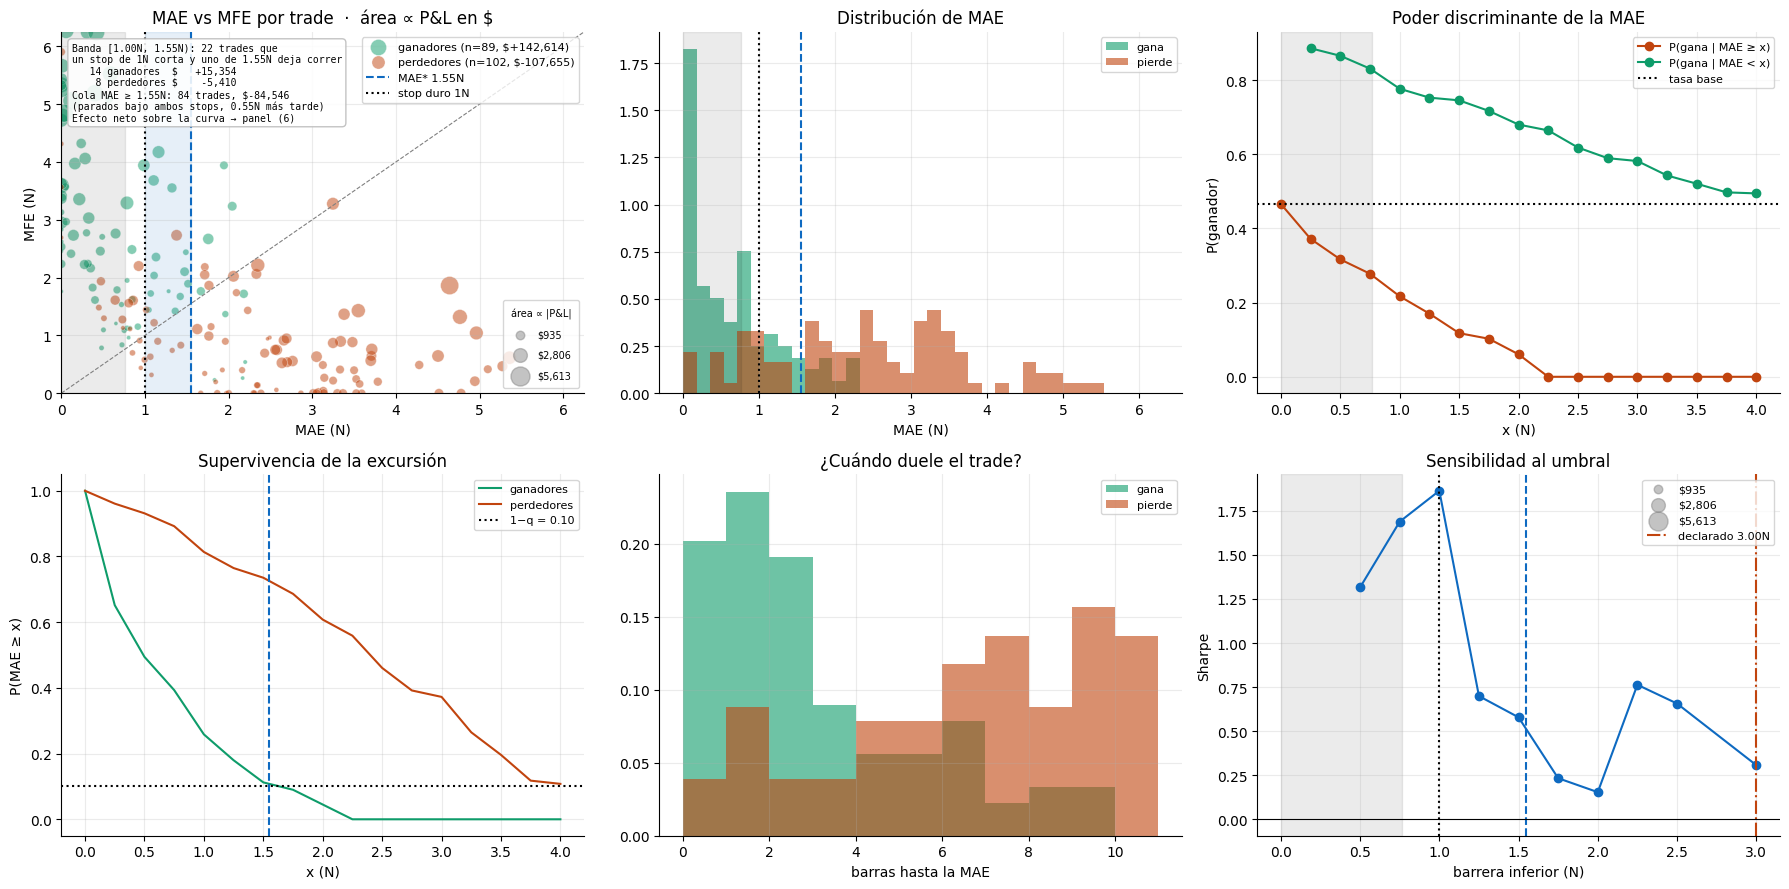

,sn,CAGR,Sharpe,trades,win,resoluble,declarado
0,0.500000,+35.2%,1.32,291,23%,False,False
1,0.750000,+54.9%,1.69,283,30%,False,False
2,1.000000,+65.0%,1.86,272,36%,True,False
3,1.250000,+32.2%,0.70,261,41%,True,False
4,1.500000,+28.5%,0.58,242,46%,True,False
5,1.750000,+11.5%,0.23,235,48%,True,False
6,2.000000,+8.4%,0.15,227,50%,True,False
7,2.250000,+37.6%,0.76,222,52%,True,False
8,2.500000,+31.4%,0.66,216,52%,True,False
9,3.000000,+14.5%,0.31,208,53%,True,True



  Umbral declarado MAE_STOP_N_FIJO = 3.00 N  →  Sharpe 0.31  CAGR +14.5%  (208 trades)   [resoluble]


In [35]:
# ── Los cinco paneles del análisis MAE ─────────────────────────────────────
fig, ax = plt.subplots(2, 3, figsize=(18, 9))

# (1) MAE vs MFE, con el ÁREA del punto proporcional al P&L en dólares.
#     El área (no el radio) escala con |P&L| para que la comparación visual entre
#     dos puntos sea la razón de sus P&L. La referencia de escala es el p90 de
#     |P&L| en vez del máximo: con un máximo dominado por uno o dos trades, el
#     resto de la nube colapsa al tamaño mínimo y el panel deja de informar.
_PNL_REF = float(np.nanpercentile(TR_OBS.pnl.abs(), 90)) or 1.0
_AREA_REF = 90.0                     # puntos² que representan _PNL_REF dólares
def _area(pnl):
    return 8.0 + _AREA_REF * np.clip(np.abs(pnl) / _PNL_REF, 0, 3.0)

for w, c, lab in [(True, "#0e9c6a", "ganadores"), (False, "#c1440e", "perdedores")]:
    d = TR_OBS[TR_OBS.win == w]
    ax[0,0].scatter(d.mae_n, d.mfe_n, s=_area(d.pnl), c=c, alpha=.50,
                    linewidths=.4, edgecolors="white",
                    label=f"{lab} (n={len(d)}, ${d.pnl.sum():+,.0f})")

_lim = float(np.nanpercentile(np.r_[TR_OBS.mae_n, TR_OBS.mfe_n], 98))
ax[0,0].plot([0, _lim], [0, _lim], lw=.8, c="gray", ls="--")
ax[0,0].axvspan(0, FLOOR_N, color="k", alpha=.08)

# Banda de decisión: los trades cuya MAE cae entre el stop duro y MAE* son los
# ÚNICOS cuyo desenlace cambia según cuál de los dos stops se opere.
_lo, _hi = min(STOP_N, MAE_STAR), max(STOP_N, MAE_STAR)
_band = (TR_OBS.mae_n >= _lo) & (TR_OBS.mae_n < _hi)
_bw, _bl = TR_OBS[_band & TR_OBS.win], TR_OBS[_band & ~TR_OBS.win]
ax[0,0].axvspan(_lo, _hi, color="#0e6ac1", alpha=.10)
ax[0,0].axvline(MAE_STAR, ls="--", c="#0e6ac1", label=f"MAE* {MAE_STAR:.2f}N")
ax[0,0].axvline(STOP_N, ls=":", c="k", label=f"stop duro {STOP_N:.0f}N")

# Leyenda de tamaño: qué dólares representa cada área.
_ticks = [t for t in (_PNL_REF/3, _PNL_REF, 2*_PNL_REF) if t > 0]
_handles = [plt.scatter([], [], s=_area(t), c="#888", alpha=.5,
                        label=f"${t:,.0f}") for t in _ticks]
_leg = ax[0,0].legend(handles=_handles, title="área ∝ |P&L|", loc="lower right",
                      fontsize=7, title_fontsize=7, labelspacing=1.1,
                      borderpad=.8, frameon=True)
ax[0,0].add_artist(_leg)

# Composición de la banda, en dólares OBSERVADOS. Deliberadamente no se calcula
# aquí el efecto neto de cambiar de stop: exigiría un contrafactual (qué habrían
# hecho estos trades bajo el otro stop) que esta población no contiene — cambiar
# el stop cambia también cuántas unidades se cargan, qué trades existen y el
# camino del equity. Ese efecto se mide re-corriendo el motor: panel (6) y tabla
# SENS.
_tail = TR_OBS.mae_n >= _hi
ax[0,0].text(0.02, 0.97,
             f"Banda [{_lo:.2f}N, {_hi:.2f}N): {len(_bw)+len(_bl)} trades que\n"
             f"un stop de {STOP_N:.0f}N corta y uno de {MAE_STAR:.2f}N deja correr\n"
             f"  {len(_bw):>3} ganadores  ${_bw.pnl.sum():>+10,.0f}\n"
             f"  {len(_bl):>3} perdedores ${_bl.pnl.sum():>+10,.0f}\n"
             f"Cola MAE ≥ {_hi:.2f}N: {int(_tail.sum())} trades, "
             f"${TR_OBS.loc[_tail,'pnl'].sum():>+,.0f}\n"
             f"(parados bajo ambos stops, 0.55N más tarde)\n"
             f"Efecto neto sobre la curva → panel (6)",
             transform=ax[0,0].transAxes, va="top", ha="left", fontsize=7,
             family="monospace",
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#bbb", alpha=.88))

ax[0,0].set(xlabel="MAE (N)", ylabel="MFE (N)", xlim=(0, _lim), ylim=(0, _lim),
            title="MAE vs MFE por trade  ·  área ∝ P&L en $")
ax[0,0].legend(fontsize=8, loc="upper right")

# (2) Distribuciones de MAE. La zona sombreada es lo irresoluble.
bins = np.linspace(0, _lim, 36)
ax[0,1].hist(W.mae_n, bins=bins, alpha=.6, density=True, color="#0e9c6a", label="gana")
ax[0,1].hist(L.mae_n, bins=bins, alpha=.6, density=True, color="#c1440e", label="pierde")
ax[0,1].axvspan(0, FLOOR_N, color="k", alpha=.08)
ax[0,1].axvline(MAE_STAR, ls="--", c="#0e6ac1"); ax[0,1].axvline(STOP_N, ls=":", c="k")
ax[0,1].set(xlabel="MAE (N)", title="Distribución de MAE"); ax[0,1].legend(fontsize=8)

# (3) LA PUERTA: si esta curva no cae, no hay nada que cortar.
ax[0,2].plot(CUR.x_n, CUR.p_win_ge, "o-", color="#c1440e", label="P(gana | MAE ≥ x)")
ax[0,2].plot(CUR.x_n, CUR.p_win_lt, "o-", color="#0e9c6a", label="P(gana | MAE < x)")
ax[0,2].axhline(TR_OBS.win.mean(), ls=":", c="k", label="tasa base")
ax[0,2].axvspan(0, FLOOR_N, color="k", alpha=.08)
ax[0,2].set(xlabel="x (N)", ylabel="P(ganador)", title="Poder discriminante de la MAE")
ax[0,2].legend(fontsize=8)

# (4) Supervivencia: MAE* al cuantil q es donde surv_win = 1−q.
ax[1,0].plot(CUR.x_n, CUR.surv_win, color="#0e9c6a", label="ganadores")
ax[1,0].plot(CUR.x_n, CUR.surv_loss, color="#c1440e", label="perdedores")
ax[1,0].axhline(0.10, ls=":", c="k", label="1−q = 0.10")
ax[1,0].axvline(MAE_STAR, ls="--", c="#0e6ac1")
ax[1,0].set(xlabel="x (N)", ylabel="P(MAE ≥ x)", title="Supervivencia de la excursión")
ax[1,0].legend(fontsize=8)

# (5) Cuándo ocurre la MAE dentro del trade.
ax[1,1].hist(W.bars_to_mae, bins=range(0, MAX_HOLD_BARS+2), alpha=.6, density=True,
             color="#0e9c6a", label="gana")
ax[1,1].hist(L.bars_to_mae, bins=range(0, MAX_HOLD_BARS+2), alpha=.6, density=True,
             color="#c1440e", label="pierde")
ax[1,1].set(xlabel="barras hasta la MAE", title="¿Cuándo duele el trade?")
ax[1,1].legend(fontsize=8)

# (6) Sensibilidad: qué pasa al mover la barrera inferior por toda la banda.
# El umbral declarado para el vivo entra EN el barrido: así deja de ser un
# número impreso y pasa a ser un punto medido de esta misma curva.
_grid = np.unique(np.round(np.r_[np.arange(0.5, 2.51, 0.25), MAE_STOP_N_FIJO], 2))
_rows = []
for _sn in _grid:
    _ec, _tr = run_turtle(DATA_MAIN, SYS_MAIN["entry"], SYS_MAIN["exit"],
                          **cfg(mae_stop_n=_sn))
    _m = metrics(_ec, _tr)
    _rows.append({"sn": _sn, "CAGR": _m.get("CAGR", np.nan), "Sharpe": _m.get("Sharpe", np.nan),
                  "trades": len(_tr), "win": _m.get("Win rate", np.nan),
                  "resoluble": _sn >= FLOOR_N,
                  "declarado": bool(np.isclose(_sn, MAE_STOP_N_FIJO))})
SENS = pd.DataFrame(_rows)
ax[1,2].plot(SENS.sn, SENS.Sharpe, "o-", color="#0e6ac1")
ax[1,2].axvspan(0, FLOOR_N, color="k", alpha=.08)
ax[1,2].axvline(MAE_STAR, ls="--", c="#0e6ac1"); ax[1,2].axvline(STOP_N, ls=":", c="k")
ax[1,2].axvline(MAE_STOP_N_FIJO, ls="-.", c="#c1440e",
                label=f"declarado {MAE_STOP_N_FIJO:.2f}N")
ax[1,2].legend(fontsize=8)
ax[1,2].axhline(0, lw=.8, c="k")
ax[1,2].set(xlabel="barrera inferior (N)", ylabel="Sharpe",
            title="Sensibilidad al umbral")
plt.tight_layout(); plt.show()

display(SENS.style.format({"CAGR": "{:+.1%}", "Sharpe": "{:.2f}", "win": "{:.0%}"})
        .background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

_dec = SENS[SENS.declarado]
if len(_dec):
    _d = _dec.iloc[0]
    print(f"\n  Umbral declarado MAE_STOP_N_FIJO = {MAE_STOP_N_FIJO:.2f} N  →  "
          f"Sharpe {_d.Sharpe:.2f}  CAGR {_d.CAGR:+.1%}  ({int(_d.trades)} trades)"
          f"   [{'resoluble' if _d.resoluble else 'POR DEBAJO del suelo de resolución'}]")

## 8.6 Anchura del canal y alcanzabilidad del objetivo

El objetivo de este sistema es un nivel del propio canal, no un múltiplo de N, así que su
alcanzabilidad depende de cuánto mide el canal en unidades de N. Si el objetivo queda más lejos de
lo que el precio recorre dentro de la barrera vertical, la salida efectiva del sistema es el
vencimiento de esa barrera.


In [36]:
# ── ¿Está el objetivo al alcance dentro de la barrera vertical? ────────────
_w = pd.concat([d["width_n"] for d in DATA_S1.values()]).dropna()
print("="*78); print("  ANCHURA DEL CANAL DONCHIAN Y ALCANCE DEL OBJETIVO"); print("="*78)
print(f"\n  Anchura del canal {SYS1['entry']}b: p25 {_w.quantile(.25):.1f}N | "
      f"mediana {_w.median():.1f}N | p75 {_w.quantile(.75):.1f}N")
print(f"  Distancia banda → medio  : {_w.median()/2:.1f} N")
print(f"  Distancia banda → opuesta: {_w.median():.1f} N")
print(f"  Stop                     : {STOP_N:.0f} N")
print(f"  Ratio riesgo/recompensa al medio: {(_w.median()/2)/STOP_N:.1f} : 1")

if len(tr_main):
    _vc = tr_main.exit_reason.value_counts(normalize=True)
    _tp = _vc.get("target", 0) + _vc.get("gap_target", 0)
    _st = _vc.get("stop", 0) + _vc.get("gap_stop", 0)
    _vt = _vc.get("vertical", 0)
    print(f"\n  Tasas de toque observadas: TP {_tp:.0%} | stop {_st:.0%} | vertical {_vt:.0%}")
    print(f"  Barras hasta la salida    : mediana {tr_main.bars.median():.0f} de {MAX_HOLD_BARS}")
    if _vt >= max(_tp, _st):
        print("\n  ⚠ El VENCIMIENTO es la salida dominante. Con el objetivo a "
              f"{_w.median()/2:.1f} N y solo")
        print(f"    {MAX_HOLD_BARS} barras para recorrerlo, el sistema depende más del reloj que")
        print("    de sus barreras de precio. Las alternativas son alargar la vertical o acercar")
        print("    el objetivo; alargarla lo saca del horizonte intradía.")

    # La escalera de ½N recorta el recorrido disponible: cada add sube el stop.
    print(f"\n  Unidades por trade: media {tr_main.units.mean():.2f}, máx {int(tr_main.units.max())}")
    print("  Cada add sube TODOS los stops a "
          f"{STOP_N:.0f}N del fill más reciente, así que la escalera va apretando")
    print("  el stop contra el precio: con 4 unidades cargadas el stop queda a "
          f"{STOP_N - (MAX_UNITS-1)*ADD_N:.1f}N de la entrada.")

  ANCHURA DEL CANAL DONCHIAN Y ALCANCE DEL OBJETIVO

  Anchura del canal 20b: p25 4.7N | mediana 5.8N | p75 7.4N
  Distancia banda → medio  : 2.9 N
  Distancia banda → opuesta: 5.8 N
  Stop                     : 1 N
  Ratio riesgo/recompensa al medio: 2.9 : 1

  Tasas de toque observadas: TP 31% | stop 61% | vertical 8%
  Barras hasta la salida    : mediana 3 de 10

  Unidades por trade: media 1.77, máx 4
  Cada add sube TODOS los stops a 1N del fill más reciente, así que la escalera va apretando
  el stop contra el precio: con 4 unidades cargadas el stop queda a -0.5N de la entrada.


In [37]:
# ── Veredicto del análisis MAE ─────────────────────────────────────────────
print("="*78); print("  ¿DISCRIMINA LA MAE?"); print("="*78)

_base = TR_OBS.win.mean()
_res = CUR[CUR.x_n >= FLOOR_N]
_lift = float(_res.lift.mean())
_mono = bool((_res.p_win_ge.diff().dropna() <= 1e-9).mean() > 0.75)

print(f"\n  Régimen de calibración         : stop {CALIB_STOP_N:.0f}N, R = {CALIB_STOP_N:.0f}N")
print(f"  Trades / ganadores             : {len(TR_OBS)} / {len(W)}  (tasa base {_base:.1%})")
print(f"  P(gana | MAE ≥ MAE*)           : "
      f"{float(CUR.loc[(CUR.x_n - MAE_STAR).abs().idxmin(), 'p_win_ge']):.1%}")
print(f"  Lift medio en la zona resoluble: {_lift:+.3f}   (negativo = la MAE informa)")
print(f"  Monótona decreciente           : {'sí' if _mono else 'NO'}")
print(f"  Separación KS                  : {float(CUR.ks.max()):.2f}")
print(f"  E-ratio (MFE/MAE)              : {edge_ratio(TR_OBS.mfe_n, TR_OBS.mae_n):.2f}")

if _lift < -0.05 and _mono:
    print("\n  ✓ La MAE SÍ discrimina: la probabilidad de acabar en ganancia cae de forma")
    print("    monótona con la excursión adversa. Cortar por MAE tiene fundamento.")
else:
    print("\n  ✗ La MAE NO discrimina de forma útil. Cualquier umbral aquí solo añadiría")
    print("    coste de transacción.")

# La pregunta que casi ningún análisis de MAE se hace: ¿el umbral que sale de los
# datos cabe DENTRO del stop que se opera, o lo desborda?
print("\n" + "="*78); print("  ¿HAY SITIO PARA UN CIERRE TEMPRANO?"); print("="*78)
print(f"\n  Suelo de resolución  : {FLOOR_N:.2f} N")
print(f"  MAE* calibrado       : {MAE_STAR:.2f} N")
print(f"  MAE p90 de ganadores : {W.mae_n.quantile(.90):.2f} N")

for _lbl, _sn in [("1N (operado hoy)", STOP_N), (f"{CALIB_STOP_N:.0f}N (calibración)", CALIB_STOP_N)]:
    _band_ok = FLOOR_N <= MAE_STAR < _sn
    _mark = "✓ CABE" if _band_ok else "✗ NO CABE"
    print(f"\n  Con stop duro {_lbl:22}: MAE* = {MAE_STAR/_sn:.2f} R   {_mark}")
    if _band_ok:
        print(f"     Banda resoluble para el cierre temprano: "
              f"[{FLOOR_N/_sn:.2f} R, 1.00 R)  →  umbral en {MAE_STAR/_sn:.2f} R")
    else:
        print(f"     MAE* ({MAE_STAR:.2f} N) queda por ENCIMA del stop ({_sn:.0f} N): con esta")
        print(f"     R no hay cierre temprano posible, porque el stop dispara antes.")

print("\n" + "-"*78)
if MAE_STAR < CALIB_STOP_N <= 2.0 and MAE_STAR >= STOP_N:
    print("  LECTURA: el stop de 1N que se opera hoy es MÁS ESTRECHO que la excursión")
    print("  que los ganadores necesitan para resolverse, así que corta ganadores y no")
    print(f"  deja hueco para nada más fino. Ensanchándolo a {CALIB_STOP_N:.0f}N, el mismo")
    print(f"  umbral pasa a valer {MAE_STAR/CALIB_STOP_N:.2f} R y el cierre temprano vuelve")
    print("  a tener sentido: hay distancia entre la barrera interna y la externa.")
    print("  Es el argumento cuantitativo para operar R = 2N y cerrar antes por MAE,")
    print("  en vez de R = 1N sin cierre temprano.")
print(f"\n  Umbral declarado para el vivo (Parte A): {MAE_STOP_N_FIJO:.2f} N = "
      f"{MAE_STOP_N_FIJO/STOP_N:.2f} R sobre stop 1N")

  ¿DISCRIMINA LA MAE?

  Régimen de calibración         : stop 3N, R = 3N
  Trades / ganadores             : 191 / 89  (tasa base 46.6%)
  P(gana | MAE ≥ MAE*)           : 11.8%
  Lift medio en la zona resoluble: -0.578   (negativo = la MAE informa)
  Monótona decreciente           : sí
  Separación KS                  : 0.62
  E-ratio (MFE/MAE)              : 0.99

  ✓ La MAE SÍ discrimina: la probabilidad de acabar en ganancia cae de forma
    monótona con la excursión adversa. Cortar por MAE tiene fundamento.

  ¿HAY SITIO PARA UN CIERRE TEMPRANO?

  Suelo de resolución  : 0.76 N
  MAE* calibrado       : 1.55 N
  MAE p90 de ganadores : 1.55 N

  Con stop duro 1N (operado hoy)      : MAE* = 1.55 R   ✗ NO CABE
     MAE* (1.55 N) queda por ENCIMA del stop (1 N): con esta
     R no hay cierre temprano posible, porque el stop dispara antes.

  Con stop duro 3N (calibración)      : MAE* = 0.52 R   ✓ CABE
     Banda resoluble para el cierre temprano: [0.25 R, 1.00 R)  →  umbral en 0.52 R



## 9. Monte Carlo — distribución de resultados de la secuencia

Remuestreo de los trades con reemplazo, 5.000 veces. La curva observada es una realización del
proceso; lo que se reporta es la distribución.

Permutar el orden no sirve: la suma de P&L es invariante y el equity final sale idéntico en todas
las simulaciones. Solo el remuestreo con reemplazo genera dispersión.


  Simulaciones: 5,000 | Capital inicial: $100,000 | Trades por simulación: 272

  Percentil       Equity final      Max DD
  ----------------------------------------
  p5                   96,031     -60.3%
  p25                 156,847     -36.8%
  p50                 199,776     -26.7%
  p75                 242,181     -19.5%
  p95                 303,790     -12.7%

  Prob. de terminar en pérdida : 5.5%
  Prob. de DD ≥ 50% (bust)     : 10.6%
  Peor caso simulado           : $-36,308 (DD -163.3%)


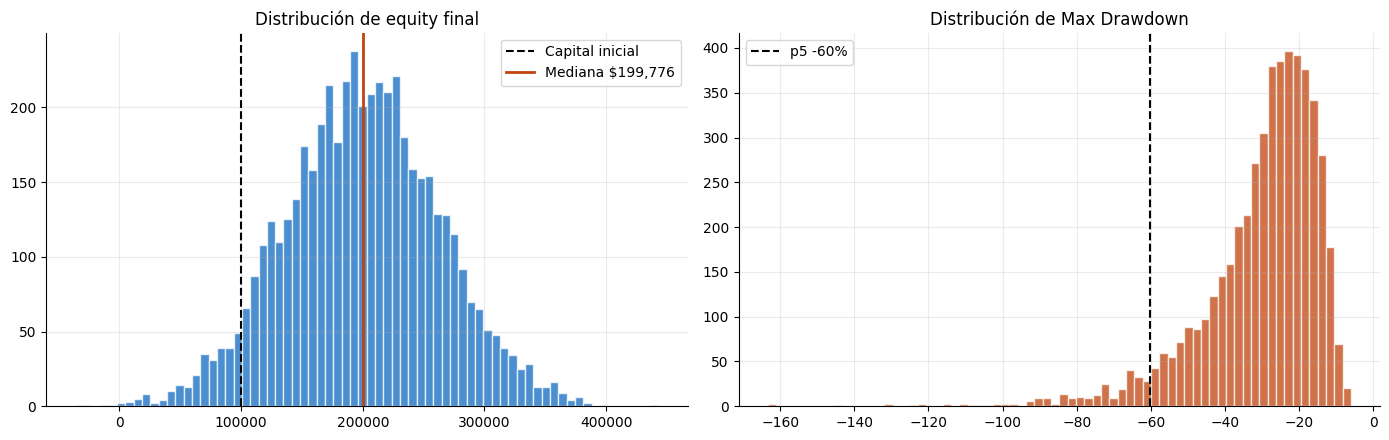

In [38]:
def mc_trades(trades, n_sims=5000, eq0=EQUITY_0, bust=-0.50, seed=7):
    """Bootstrap CON REEMPLAZO del P&L de los trades."""
    if trades is None or not len(trades):
        return None
    pnl = trades.pnl.values
    if len(pnl) < 10:
        return None
    rng = np.random.default_rng(seed)
    finals, dds, busts = [], [], 0
    for _ in range(n_sims):
        p = rng.choice(pnl, size=len(pnl), replace=True)
        eq = eq0 + np.cumsum(p)
        full = np.concatenate([[eq0], eq])
        peak = np.maximum.accumulate(full)
        dd = ((full - peak)/peak).min()
        finals.append(eq[-1]); dds.append(dd)
        if dd <= bust:
            busts += 1
    return {"finals": np.array(finals), "dds": np.array(dds), "p_bust": busts/n_sims}

mc = mc_trades(tr_main)
if not mc:
    print(f"  Solo {len(tr_main)} trades cerrados: menos de 10 no dan distribución. "
          "Alarga la muestra o baja BAR_SIZE.")
else:
    f, d = mc["finals"], mc["dds"]
    print(f"  Simulaciones: 5,000 | Capital inicial: ${EQUITY_0:,} | "
          f"Trades por simulación: {len(tr_main)}\n")
    print(f"  {'Percentil':<12}{'Equity final':>16}{'Max DD':>12}")
    print(f"  {'-'*40}")
    for q in [5, 25, 50, 75, 95]:
        print(f"  p{q:<11}{np.percentile(f,q):>15,.0f}{np.percentile(d,q):>11.1%}")
    print(f"\n  Prob. de terminar en pérdida : {(f < EQUITY_0).mean():.1%}")
    print(f"  Prob. de DD ≥ 50% (bust)     : {mc['p_bust']:.1%}")
    print(f"  Peor caso simulado           : ${f.min():,.0f} (DD {d.min():.1%})")

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    ax[0].hist(f, bins=70, color="#0e6ac1", alpha=.75, edgecolor="w")
    ax[0].axvline(EQUITY_0, color="k", ls="--", label="Capital inicial")
    ax[0].axvline(np.median(f), color="#c1440e", lw=2, label=f"Mediana ${np.median(f):,.0f}")
    ax[0].set_title("Distribución de equity final"); ax[0].legend()
    ax[1].hist(d*100, bins=70, color="#c1440e", alpha=.75, edgecolor="w")
    ax[1].axvline(np.percentile(d, 5)*100, color="k", ls="--",
                  label=f"p5 {np.percentile(d,5):.0%}")
    ax[1].set_title("Distribución de Max Drawdown"); ax[1].legend()
    plt.tight_layout(); plt.show()

## 9.5 Deflated Sharpe Ratio — ¿sobrevive el Sharpe al número de ensayos?

El Monte Carlo de §9 responde "¿qué tan afortunada fue esta secuencia de trades?". Ésta responde
una pregunta distinta y más incómoda: **"¿qué tan afortunada fue esta configuración entre todas
las que se probaron?"**.

Probando N configuraciones sin ninguna habilidad, el mejor Sharpe de la rejilla es alto **por
construcción**. El DSR (Bailey & López de Prado, 2014) compara el Sharpe seleccionado contra
`SR*`, el máximo que cabría esperar bajo la hipótesis nula de que ninguna configuración tiene
edge, y devuelve `P(SR verdadero > SR*)`.

Tres piezas:

- **`SR*` = E[max SR]** entre ensayos independientes, que crece con el número de ensayos y con la
  dispersión de sus Sharpe.
- **Ensayos efectivos** `N_eff = M(1 − ρ̄) + ρ̄`. Una rejilla de 200 combinaciones que en realidad
  explora dos ideas no debe penalizarse como 200: lo que cuenta es cuántas apuestas
  **independientes** hubo.
- **σ(SR) con corrección por no normalidad.** Con cola izquierda gorda el error típico crece, así
  que la misma estrategia necesita más track record para justificar el mismo Sharpe.

**El recuento de ensayos es el punto débil de este notebook, y hay que decirlo antes de mirar el
número.** El sesgo de selección no distingue entre una rejilla declarada de antemano y el prueba y
error de ir mirando resultados. La matriz de abajo reconstruye las configuraciones exploradas, pero
es una **cota inferior**: varias decisiones de diseño (granularidad, objetivo en el medio del canal,
barrera vertical, regla de confirmación) se tomaron mirando resultados intermedios y no aparecen
como columnas.

La implementación está en `deflated_sr.py`, en la raíz del repo, con la especificación completa en
`test_deflated_sr.py` (20 contract tests, incluidos los de Monte Carlo que verifican las dos
propiedades que importan: el mejor de N estrategias sin edge NO debe parecer hábil, y un edge
genuino debe sobrevivir a la deflación).


In [39]:
# ── DEFLATED SHARPE RATIO ──────────────────────────────────────────────────
import sys as _sys
if str(ROOT) not in _sys.path:
    _sys.path.insert(0, str(ROOT))
from deflated_sr import (deflated_sharpe_ratio, estimated_sharpe_ratio,
                         min_track_record_length, num_independent_trials,
                         annualized_sharpe_ratio)

# Matriz de ENSAYOS: una columna por configuración explorada, con sus retornos
# por barra. Se reconstruye el espacio de búsqueda realmente recorrido en este
# notebook, no una rejilla de conveniencia.
_CANALES = [(SYS1["entry"], SYS1["exit"]), (SYS2["entry"], SYS2["exit"])]
_STOPS   = [0.75, 1.0, 1.25, 1.5, 2.0, 2.5]
_CONFIRM = [True, False]
_MODOS   = ["fade", "breakout"]

_cols, _labels = {}, []
for _eb, _ex in _CANALES:
    _Dg = {s: prepare(d, _eb, _ex) for s, d in RAW.items()}
    for _sn in _STOPS:
        for _cf in _CONFIRM:
            for _sm in _MODOS:
                _ec, _tr = run_turtle(_Dg, _eb, _ex,
                                      **cfg(stop_n=_sn, signal_mode=_sm,
                                            require_confirmation=_cf))
                if len(_ec) < 10:
                    continue
                _lab = f"{_eb}/{_ex}|{_sn:.2f}N|{'conf' if _cf else 'sinconf'}|{_sm}"
                _cols[_lab] = _ec.pct_change()
                _labels.append((_lab, _eb, _ex, _sn, _cf, _sm))

TRIALS = pd.DataFrame(_cols).dropna(how="all")
TRIALS = TRIALS.loc[:, TRIALS.std() > 0]          # una curva plana no es un ensayo

# La configuración operada, expresada en el mismo espacio de la matriz.
_SEL = (f"{SYS_MAIN['entry']}/{SYS_MAIN['exit']}|{STOP_N:.2f}N|"
        f"{'conf' if REQUIRE_CONFIRMATION else 'sinconf'}|{SIGNAL_MODE}")
assert _SEL in TRIALS.columns, f"la configuración operada no está en la matriz: {_SEL}"

DSR = deflated_sharpe_ratio(TRIALS[_SEL].dropna(), TRIALS)

print("="*74)
print("  DEFLATED SHARPE RATIO")
print("="*74)
print(f"\n  Configuración operada : {_SEL}")
print(f"  Ensayos en la matriz  : {DSR.n_trials_total}"
      f"   →  {DSR.n_trials_effective} efectivos (independientes)")
print(f"  Correlación entre ensayos: la rejilla explora menos ideas de las que aparenta"
      if DSR.n_trials_effective < DSR.n_trials_total else "")
print(f"\n  SR observado (por barra) : {DSR.sr:.4f}"
      f"   → anualizado {annualized_sharpe_ratio(DSR.sr, int(BARS_PER_YEAR)):.2f}")
print(f"  SR* (listón bajo la nula): {DSR.sr_star:.4f}"
      f"   → anualizado {annualized_sharpe_ratio(DSR.sr_star, int(BARS_PER_YEAR)):.2f}")
print(f"  σ(SR) con no-normalidad  : {DSR.sr_std:.4f}"
      f"   (sesgo {DSR.skew:+.2f}, curtosis {DSR.kurtosis:.2f})")
print(f"  Dispersión de la rejilla : {DSR.trials_sr_std:.4f}")
print(f"\n  PSR (contra SR = 0)      : {DSR.psr:.4f}")
print(f"  DSR (contra SR*)         : {DSR.dsr:.4f}   ← el que cuenta")

_mtrl = min_track_record_length(sr=DSR.sr, sr_std=DSR.sr_std, n=DSR.n_obs,
                                sr_benchmark=DSR.sr_star, prob=0.95)
print(f"\n  MinTRL al 95% frente a SR*: "
      + (f"{_mtrl:,.0f} barras ({_mtrl/BARS_PER_YEAR:.2f} años)"
         if np.isfinite(_mtrl) else "∞ — el SR no supera el listón"))
print(f"  Muestra disponible        : {DSR.n_obs:,} barras "
      f"({DSR.n_obs/BARS_PER_YEAR:.2f} años)")

print("\n" + "-"*74)
if DSR.dsr >= 0.95:
    print(f"  DSR = {DSR.dsr:.3f} ≥ 0.95: el Sharpe sobrevive al recuento de ensayos DE ESTA")
    print("  matriz. Sigue siendo una cota optimista: las decisiones de diseño tomadas")
    print("  mirando resultados intermedios no están contadas como ensayos.")
elif DSR.dsr >= 0.5:
    print(f"  DSR = {DSR.dsr:.3f}: por encima del listón pero sin confianza al 95%. Con esta")
    print("  muestra no se puede distinguir el edge del efecto de haber buscado.")
else:
    print(f"  DSR = {DSR.dsr:.3f} < 0.5: el Sharpe seleccionado NO supera lo que cabría")
    print("  esperar del mejor de esta rejilla sin ningún edge. El resultado es selección.")
if np.isfinite(_mtrl) and _mtrl > DSR.n_obs:
    print(f"\n  Y el track record es insuficiente: harían falta {_mtrl/DSR.n_obs:.1f}x la muestra")
    print("  actual para distinguir este SR de SR* con 95% de confianza.")

# Ranking: dónde cae la configuración operada dentro de su propia rejilla.
_rank = estimated_sharpe_ratio(TRIALS).sort_values(ascending=False)
_pos = list(_rank.index).index(_SEL) + 1
print(f"\n  Puesto de la configuración operada en la rejilla: {_pos} de {len(_rank)}")
print("  (ser la mejor de la rejilla es exactamente la condición que el DSR penaliza)")
display(pd.DataFrame({"SR_por_barra": _rank.head(8),
                      "SR_anualizado": _rank.head(8)*np.sqrt(BARS_PER_YEAR)})
        .style.format("{:.4f}"))


  DEFLATED SHARPE RATIO

  Configuración operada : 20/10|1.00N|conf|fade
  Ensayos en la matriz  : 48   →  40 efectivos (independientes)
  Correlación entre ensayos: la rejilla explora menos ideas de las que aparenta

  SR observado (por barra) : 0.0283   → anualizado 1.60
  SR* (listón bajo la nula): 0.0332   → anualizado 1.87
  σ(SR) con no-normalidad  : 0.0153   (sesgo +0.53, curtosis 86.28)
  Dispersión de la rejilla : 0.0152

  PSR (contra SR = 0)      : 0.9674
  DSR (contra SR*)         : 0.3743   ← el que cuenta

  MinTRL al 95% frente a SR*: ∞ — el SR no supera el listón
  Muestra disponible        : 4,263 barras (1.34 años)

--------------------------------------------------------------------------
  DSR = 0.374 < 0.5: el Sharpe seleccionado NO supera lo que cabría
  esperar del mejor de esta rejilla sin ningún edge. El resultado es selección.

  Puesto de la configuración operada en la rejilla: 1 de 48
  (ser la mejor de la rejilla es exactamente la condición que el DSR penal

,SR_por_barra,SR_anualizado
20/10|1.00N|conf|fade,0.0283,1.5968
20/10|0.75N|conf|fade,0.0166,0.9362
20/10|2.50N|conf|fade,0.0150,0.8492
20/10|1.25N|conf|fade,0.0148,0.8369
20/10|1.50N|conf|fade,0.0134,0.7579
20/10|2.00N|conf|fade,0.0123,0.6941
55/20|1.00N|conf|fade,0.0089,0.5008
20/10|1.00N|sinconf|fade,0.0087,0.4912


## 10. Tabla comparativa y veredicto

In [40]:
cols = ["CAGR", "Volatilidad", "Sharpe", "Sortino", "Max DD", "Calmar", "Retorno total"]
_rows = {
    f"Reversión ({SYS1['entry']}b)":  metrics(ec_s1, tr_s1),
    f"Reversión ({SYS2['entry']}b)":  metrics(ec_s2, tr_main),
    "Ruptura (contraste)":                          metrics(ec_brk, tr_brk),
    f"B&H {_bh_sym}":                                 metrics(bh),
}
if len(EC_WFO):
    _rows["Walk-Forward OOS"] = metrics(EC_WFO)

comp = pd.DataFrame(_rows).T.reindex(columns=cols)
display(comp.style.format({c: "{:.2%}" for c in
                           ["CAGR", "Volatilidad", "Max DD", "Retorno total"]}
        | {c: "{:.2f}" for c in ["Sharpe", "Sortino", "Calmar"]})
        .background_gradient(subset=["Sharpe", "Calmar"], cmap="RdYlGn"))

_tag = f"{'_'.join(RAW)}_{BAR_SIZE.replace(' ','')}"
comp.to_csv(OUT / f"turtle_ibkr_{_tag}_resultados.csv")
if len(FOLDS):
    FOLDS.to_csv(OUT / f"turtle_ibkr_{_tag}_walkforward_folds.csv", index=False)
if len(tr_main):
    tr_main.to_csv(OUT / f"turtle_ibkr_{_tag}_trades.csv", index=False)
SPECS_DF.to_csv(OUT / f"turtle_ibkr_{_tag}_specs.csv", index=False)
print(f"\n✓ Exportado a {OUT}/ con prefijo turtle_ibkr_{_tag}_")

,CAGR,Volatilidad,Sharpe,Sortino,Max DD,Calmar,Retorno total
Reversión (20b),65.03%,34.89%,1.86,1.37,-27.27%,2.39,94.03%
Reversión (55b),13.57%,43.27%,0.31,0.19,-36.25%,0.37,17.64%
Ruptura (contraste),-11.56%,14.08%,-0.82,-0.41,-27.63%,-0.42,-14.51%
B&H MBT,-16.44%,41.54%,-0.40,-0.47,-54.06%,-0.30,-21.42%
Walk-Forward OOS,23.88%,43.70%,0.55,0.39,-30.13%,0.79,17.97%



✓ Exportado a /Users/diegoochoa/Projects/Intraday_MR_BTC/output/ con prefijo turtle_ibkr_MBT_30mins_


In [41]:
print("="*74)
print("  CHECKLIST DE VALIDEZ — sistema de parámetros FIJOS (fade canónico "
      f"{SYS_MAIN['entry']}/{SYS_MAIN['exit']} barras)")
print("="*74)
print("  La tesis que se contrasta es el sistema fijo, no la curva del walk-forward.")
print("  Los folds OOS se usan para medir su estabilidad fuera de muestra.\n")

_m_main = metrics(ec_main, tr_main)
_exec_ratio = (REJ_MAIN["ejecutadas"] /
               max(REJ_MAIN["ejecutadas"] + REJ_MAIN["qty_cero"] + REJ_MAIN["apalancamiento"]
                   + REJ_MAIN["limite_direccion"] + REJ_MAIN["limite_grupo"], 1))
# Rendimiento OOS del sistema FIJO, fold a fold (columna BASE_ret del walk-forward).
_base_pos  = float((FOLDS.BASE_ret > 0).mean()) if len(FOLDS) else 0.0
_base_mean = float(FOLDS.BASE_ret.mean()) if len(FOLDS) else float("nan")

chk = [
    ("Muestra ≥ 2 años de histórico", _span_days/365.25 >= 2),
    ("≥ 8 folds OOS (el t-test tiene potencia)", len(FOLDS) >= 8),
    ("≥ 30 trades cerrados en el sistema fijo", len(tr_main) >= 30),
    ("≥ 50% de las señales fueron ejecutables (contratos enteros)", _exec_ratio >= 0.50),
    ("Sistema fijo positivo en >60% de los folds OOS", _base_pos > 0.60),
    ("Retorno OOS medio del sistema fijo > 0", _base_mean > 0),
    ("Edge sobrevive el escenario pesimista de costes", bool(cost_df.CAGR.iloc[3] > 0)),
    ("Top-3 trades <50% del P&L total",
     bool(len(tr) >= 3 and tot and tr.pnl.head(3).sum()/tot < 0.50)),
    ("Nº efectivo de apuestas independientes ≥ 8", n_eff >= 8),
    ("Sharpe del sistema fijo > Sharpe de B&H",
     _m_main.get("Sharpe", 0) > metrics(bh).get("Sharpe", 0)),
    ("Prob. Monte Carlo de bust (DD≥50%) < 20%", (mc["p_bust"] < 0.20) if mc else False),
    (f"Deflated Sharpe > 0.95 con {DSR.n_trials_total} ensayos declarados "
     f"({DSR.n_trials_effective} efectivos)", DSR.dsr > 0.95),
]
for txt, ok in chk:
    print(f"  [{'✓' if ok else '✗'}] {txt}")

n_ok = sum(bool(o) for _, o in chk)
print(f"\n  {n_ok}/{len(chk)} criterios superados")
print(f"\n  {'→ Resultado no descartado; continuar la validación.' if n_ok >= 9 else '→ No desplegar capital con esta evidencia.'}")
print("="*74)

print(f"\n  Deflated Sharpe: DSR = {DSR.dsr:.3f} (SR {DSR.sr:.4f} vs SR* {DSR.sr_star:.4f}).")
if DSR.dsr <= 0.5:
    print("  La configuración operada es la número "
          f"{list(estimated_sharpe_ratio(TRIALS).sort_values(ascending=False).index).index(_SEL)+1}"
          f" de {DSR.n_trials_total} de su propia rejilla, y su Sharpe no supera el máximo")
    print("  esperable de esa búsqueda sin edge alguno. Es el criterio más severo del")
    print("  checklist y el que menos se arregla con parámetros: exige más muestra o")
    print("  menos búsqueda, no otra configuración.")

# Diagnóstico, NO criterio: el walk-forward mide estabilidad, no es el sistema propuesto.
if len(FOLDS):
    _wins = int((FOLDS.OOS_ret > FOLDS.BASE_ret).sum())
    print(f"\n  Diagnóstico (no puntúa): la rejilla optimizada supera al sistema fijo en "
          f"{_wins}/{len(FOLDS)} folds.")
    print(f"  Retorno OOS medio — fijo: {_base_mean:+.2%} | optimizado: {FOLDS.OOS_ret.mean():+.2%}")

print("\n  Nota: el criterio de n_eff >= 8 no es alcanzable con uno o dos contratos del")
print("  mismo subyacente. El sistema Turtle se diseñó como cartera; para el universo")
print("  completo ver Turtle_WalkForward_Diversified.ipynb.")


  CHECKLIST DE VALIDEZ — sistema de parámetros FIJOS (fade canónico 20/10 barras)
  La tesis que se contrasta es el sistema fijo, no la curva del walk-forward.
  Los folds OOS se usan para medir su estabilidad fuera de muestra.

  [✗] Muestra ≥ 2 años de histórico
  [✗] ≥ 8 folds OOS (el t-test tiene potencia)
  [✓] ≥ 30 trades cerrados en el sistema fijo
  [✓] ≥ 50% de las señales fueron ejecutables (contratos enteros)
  [✓] Sistema fijo positivo en >60% de los folds OOS
  [✓] Retorno OOS medio del sistema fijo > 0
  [✓] Edge sobrevive el escenario pesimista de costes
  [✓] Top-3 trades <50% del P&L total
  [✗] Nº efectivo de apuestas independientes ≥ 8
  [✓] Sharpe del sistema fijo > Sharpe de B&H
  [✓] Prob. Monte Carlo de bust (DD≥50%) < 20%
  [✗] Deflated Sharpe > 0.95 con 48 ensayos declarados (40 efectivos)

  8/12 criterios superados

  → No desplegar capital con esta evidencia.

  Deflated Sharpe: DSR = 0.374 (SR 0.0283 vs SR* 0.0332).
  La configuración operada es la número 1

## 11. Libro abierto al final de la simulación

El motor devuelve `(curva, trades CERRADOS)`: las posiciones vivas en la última barra no
aparecen en ninguna de las dos. Se reejecuta el Sistema 2 con `open_book` para capturarlas. Su
P&L es **no realizado** —marcado al último cierre, no a un fill— y no descuenta la comisión de
salida.

In [42]:
BOOK = {}
_ec_s2, _tr_s2 = run_turtle(DATA_MAIN, SYS_MAIN["entry"], SYS_MAIN["exit"],
                            **cfg(open_book=BOOK))

ASOF = BOOK["asof"]
pnl_hist = tr_main.groupby("symbol").pnl.sum() if len(tr_main) else pd.Series(dtype=float)

rows = []
for s, p in BOOK["positions"].items():
    mult = SPECS[s]["multiplier"]
    px   = BOOK["last_close"][s]
    qty  = pos_qty(p)
    avg  = pos_cost(p)/qty if qty else np.nan
    upnl = p["side"] * (px*qty - pos_cost(p)) * mult      # bruto, sin comisión de salida
    rows.append({
        "symbol": s, "grupo": SYM2GROUP.get(s, "otro"),
        "lado": "LARGO" if p["side"] > 0 else "CORTO",
        "unidades": pos_nu(p), "contratos": qty,
        "precio_medio": avg, "ultimo_cierre": px,
        "notional": qty*px*mult, "stop": p["stop"],
        "dist_stop_N": abs(px - p["stop"])/p["n_entry"] if p["n_entry"] else np.nan,
        "N_entrada": p["n_entry"], "abierta": p["opened"],
        "horas": (ASOF - p["opened"]).total_seconds()/3600,
        "pnl_no_realizado": upnl,
        "riesgo_al_stop": abs(px - p["stop"])*qty*mult,
        "pnl_realizado_hist": float(pnl_hist.get(s, 0.0)),
    })

POSICIONES = pd.DataFrame(rows)
if len(POSICIONES):
    POSICIONES = POSICIONES.sort_values("pnl_no_realizado", ascending=False).reset_index(drop=True)

cash   = BOOK["cash"]
upnl_t = POSICIONES.pnl_no_realizado.sum() if len(POSICIONES) else 0.0
gross  = POSICIONES.notional.sum() if len(POSICIONES) else 0.0
eq_mtm = cash + upnl_t

print("="*78)
print(f"  LIBRO ABIERTO — Sistema 2 ({SYS_MAIN['entry']}/{SYS_MAIN['exit']}) @ {BAR_SIZE}, "
      f"al {ASOF:%Y-%m-%d %H:%M}")
print("="*78)
print(f"  Posiciones abiertas   : {len(POSICIONES)}")
print(f"  Unidades              : {POSICIONES.unidades.sum() if len(POSICIONES) else 0}"
      f"  (tope dirección {MAX_DIR_UNITS}, grupo {MAX_CORR_UNITS})")
print(f"  Contratos             : {POSICIONES.contratos.sum() if len(POSICIONES) else 0}")
print(f"  Nocional bruto        : ${gross:,.0f}   "
      f"({gross/eq_mtm:.2f}x equity, tope {MAX_GROSS_LEV}x)" if eq_mtm else "")
print(f"  Equity realizado      : ${cash:,.0f}")
print(f"  P&L no realizado      : ${upnl_t:,.0f}")
print(f"  Equity marcado        : ${eq_mtm:,.0f}   (= curva: ${ec_main.iloc[-1]:,.0f})")
print(f"  P&L realizado acumul. : ${tr_main.pnl.sum() if len(tr_main) else 0:,.0f} "
      f"en {len(tr_main)} trades cerrados")

if len(POSICIONES):
    display(POSICIONES.style.format({
        "contratos": "{:,.0f}", "precio_medio": "{:,.2f}", "ultimo_cierre": "{:,.2f}",
        "notional": "${:,.0f}", "stop": "{:,.2f}", "dist_stop_N": "{:.2f}N",
        "N_entrada": "{:,.2f}", "abierta": "{:%Y-%m-%d %H:%M}", "horas": "{:,.1f}",
        "pnl_no_realizado": "${:,.0f}", "riesgo_al_stop": "${:,.0f}",
        "pnl_realizado_hist": "${:,.0f}",
    }).background_gradient(subset=["pnl_no_realizado"], cmap="RdYlGn"))
    POSICIONES.to_csv(OUT / f"turtle_ibkr_{_tag}_posiciones.csv", index=False)
    print(f"\n✓ Exportado: turtle_ibkr_{_tag}_posiciones.csv")
else:
    print("\n  Sin posiciones abiertas al cierre de la simulación.")

  LIBRO ABIERTO — Sistema 2 (20/10) @ 30 mins, al 2026-08-28 20:00
  Posiciones abiertas   : 0
  Unidades              : 0  (tope dirección 12, grupo 6)
  Contratos             : 0
  Nocional bruto        : $0   (0.00x equity, tope 4.0x)
  Equity realizado      : $194,032
  P&L no realizado      : $0
  Equity marcado        : $194,032   (= curva: $194,032)
  P&L realizado acumul. : $98,826 en 272 trades cerrados

  Sin posiciones abiertas al cierre de la simulación.


In [43]:
# Cerrar la sesión: TWS mantiene el clientId ocupado y el siguiente `connect()`
# con el mismo id falla mientras el socket siga vivo.
if IBS is not None and IBS.isConnected():
    IBS.disconnect()
    print("Sesión IBKR cerrada.")

Sesión IBKR cerrada.


---

## Cómo cambiar de granularidad

Solo hay dos celdas que tocar, ambas en §1:

| Objetivo | `BAR_SIZE` | `LOOKBACK_DAYS` | Nota |
|---|---|---|---|
| Tendencia clásica | `"1 day"` | `365*5` | Granularidad del sistema Turtle original. |
| Swing intradía | `"1 hour"` | `365*2` | ~5.700 barras/año; canales de 55h ≈ una semana. |
| Intradía rápido | `"5 mins"` | `180` | El coste por round-trip empieza a dominar. |
| Microestructura | `"1 secs"` | `30` | IB solo sirve ~6 meses; Ver el aviso de horizonte de §1.2. |

Todo lo demás —troceado de peticiones, anualización, ventanas de walk-forward, avisos de
coherencia— se recalcula solo a partir de `BAR_SIZE` y de los datos efectivamente descargados.

**Para cambiar de contrato:** `SYMBOLS = ["BRR"]` en §2, y comprueba la celda de viabilidad de
capital de §3 — con `EQUITY_0 = 100.000` y BTC por encima de 80k, un solo contrato de BRR
(5 BTC) supera el tope de apalancamiento y el sistema no entrará nunca.

## Qué NO hace este notebook

- **No ajusta el roll.** La serie continua se usa tal cual la sirve IB; §8 mide el sesgo pero no
  lo corrige. Un ajuste hacia atrás (*back-adjusted*) cambiaría los niveles de precio y con
  ellos los canales Donchian de todo el histórico.
- **No modela el margen.** El tope de apalancamiento bruto es un proxy; el margen inicial y de
  mantenimiento del CME varía con la volatilidad y puede forzar liquidaciones que el motor no
  simula.
- **No usa datos intrabarra.** La prelación stop-sobre-canal es una suposición pesimista,
  no una reconstrucción de lo que ocurrió dentro de la barra.
- **No modela la ejecución.** No hay órdenes, parciales ni rechazos: los fills se asumen al precio
  de disparo más el slippage configurado.